In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')
sns.set(style="whitegrid")


#### Load Data
- Each function dataset has input dimensions (x1, x2, ..., x8) and output 'y'. (10 Data Points)



In [2]:
import os

try:
    base_dir = os.path.join(os.path.dirname(os.path.abspath(__file__)), "initial_data")
except NameError:
    base_dir = os.path.join(os.getcwd(), "..", "initial_data")
    base_dir = os.path.abspath(base_dir)

print("Looking for data in:", base_dir)
print("Path exists:", os.path.exists(base_dir))

# Dictionary to store all function datasets
functions_data = {}

for i in range(1, 9):

    # Build file paths
    function_folder = os.path.join(base_dir, f"function_{i}")
    inputs_path = os.path.join(function_folder, "initial_inputs.npy")
    outputs_path = os.path.join(function_folder, "initial_outputs.npy")

    # Load .npy arrays
    inputs = np.load(inputs_path)
    outputs = np.load(outputs_path)


    # Reshape to 2D if needed
    if inputs.ndim == 1:
        inputs = inputs.reshape(-1, 1)
    if outputs.ndim == 1:
        outputs = outputs.reshape(-1, 1)

    # Create column names (temporary)
    input_cols = [f"input_{j}" for j in range(inputs.shape[1])]
    output_cols = [f"output_{j}" for j in range(outputs.shape[1])]
    
    # Concatenate inputs + outputs
    combined = np.concatenate([inputs, outputs], axis=1)
    df_combined = pd.DataFrame(combined, columns=input_cols + output_cols)


    # Rename columns in-place
    new_input_names = {col: f"X{j+1}" for j, col in enumerate(input_cols)}
    new_output_names = {col: f"y{j+1}" for j, col in enumerate(output_cols)}
    df_combined.rename(columns={**new_input_names, **new_output_names}, inplace=True)


    # Store in dictionary
    functions_data[f"f{i}"] = df_combined

    print(f"Loaded function {i}: shape = {df_combined.shape}, columns = {df_combined.columns.tolist()}")


Looking for data in: C:\Users\Hassa\OneDrive - Loughborough University\current\ML & AI\Capstone Project\initial_data
Path exists: True
Loaded function 1: shape = (10, 3), columns = ['X1', 'X2', 'y1']
Loaded function 2: shape = (10, 3), columns = ['X1', 'X2', 'y1']
Loaded function 3: shape = (15, 4), columns = ['X1', 'X2', 'X3', 'y1']
Loaded function 4: shape = (30, 5), columns = ['X1', 'X2', 'X3', 'X4', 'y1']
Loaded function 5: shape = (20, 5), columns = ['X1', 'X2', 'X3', 'X4', 'y1']
Loaded function 6: shape = (20, 6), columns = ['X1', 'X2', 'X3', 'X4', 'X5', 'y1']
Loaded function 7: shape = (30, 7), columns = ['X1', 'X2', 'X3', 'X4', 'X5', 'X6', 'y1']
Loaded function 8: shape = (40, 9), columns = ['X1', 'X2', 'X3', 'X4', 'X5', 'X6', 'X7', 'X8', 'y1']


In [3]:
# Manually define Week 1 submission results
week1_results = {
    "f1": ([0.793600, 0.666269], 1.4034986520274933e-21),
    "f2": ([0.554975, 0.999446], -0.07640833812988071),
    "f3": ([0.389233, 0.386084, 0.558916], -0.04116779016532328),
    "f4": ([0.439369, 0.276427, 0.360198, 0.470119], -1.8014266350928305),
    "f5": ([0.037069, 0.974641, 0.864911, 0.019169], 684.5607486761136),
    "f6": ([0.363643, 0.001300, 0.920810, 0.821416, 0.136085], -0.6872415681590064),
    "f7": ([0.799542, 0.949047, 0.887638, 0.265662, 0.631518, 0.349925], 0.026543407526137847),
    "f8": ([0.311992, 0.966526, 0.355002, 0.358409, 0.551500, 0.690176, 0.717450, 0.542367], 8.4452078666581),
}

In [4]:
week2_results = {
    "f1": ([0.800601, 0.002800], 9.069108791316283e-223),
    "f2": ([0.999500, 0.001800], -0.07975546223482953),
    "f3": ([0.967200, 0.029200, 0.723300], -0.20496612752890705),
    "f4": ([0.542100, 0.336200, 0.419500, 0.404000], -2.041748838194795),
    "f5": ([0.624000, 0.735500, 0.976700, 0.994100], 2434.328593289806),
    "f6": ([0.666300, 0.229100, 0.516000, 0.821600, 0.201500], -0.5648568336407203),
    "f7": ([0.008500, 0.278800, 0.231600, 0.099300, 0.323000, 0.980800], 0.7653612109103147),
    "f8": ([0.293300, 0.174300, 0.080500, 0.056000, 0.429100, 0.492300, 0.221400, 0.410200], 9.835131961),
}

In [5]:
week3_results = {
    "f1": ([0.729726, 0.729276], 5.31459276351908e-15),
    "f2": ([0.727681, 0.187140], 0.5037032225936308),
    "f3": ([0.437962, 0.715305, 0.000876], -0.1117676821078815),
    "f4": ([0.402906, 0.437778, 0.329101, 0.424377], 0.07045398603133579),
    "f5": ([0.898795, 0.963833, 1.000000, 0.791851], 4171.124196806389),
    "f6": ([0.416408, 0.263572, 0.345102, 1.000000, 0.000000], -0.7670334120297669),
    "f7": ([0.000000, 0.189754, 0.123991, 0.253411, 0.406355, 0.251864], 0.4981320924641522),
    "f8": ([0.190768, 0.209525, 0.202591, 0.198246, 0.813824, 0.387519, 0.200772, 0.663670], 9.948688972661),
}

In [6]:
weekly_results = {
    "week1": week1_results,
    "week2": week2_results,
    "week3": week3_results
}

for week, results in weekly_results.items():
    for func, (inputs, output) in results.items():
        # Convert inputs and outputs to DataFrame
        inputs = np.array(inputs).reshape(1, -1)
        output = np.array([output]).reshape(1, -1)
        
        # Dynamically generate input column names
        df_inputs = pd.DataFrame(inputs, columns=[f"X{i+1}" for i in range(inputs.shape[1])])
        # Use existing output column names from the function
        output_cols = [col for col in functions_data[func].columns if col.startswith("y")]
        df_outputs = pd.DataFrame(output, columns=output_cols)
        
        # Combine
        df_week = pd.concat([df_inputs, df_outputs], axis=1)
        
        # Append only rows that are not already in the DataFrame
        functions_data[func] = pd.concat([functions_data[func], df_week], ignore_index=True)
        functions_data[func] = functions_data[func].drop_duplicates(ignore_index=True)

# Optional: check updated shapes
for func, df in functions_data.items():
    print(f"{func} updated shape: {df.shape}")


f1 updated shape: (13, 3)
f2 updated shape: (13, 3)
f3 updated shape: (18, 4)
f4 updated shape: (33, 5)
f5 updated shape: (23, 5)
f6 updated shape: (23, 6)
f7 updated shape: (33, 7)
f8 updated shape: (43, 9)


In [7]:
for name, df in functions_data.items():
    print(df)

          X1        X2             y1
0   0.319404  0.762959   1.322677e-79
1   0.574329  0.879898   1.033078e-46
2   0.731024  0.733000   7.710875e-16
3   0.840353  0.264732  3.341771e-124
4   0.650114  0.681526  -3.606063e-03
5   0.410437  0.147554  -2.159249e-54
6   0.312691  0.078723  -2.089093e-91
7   0.683418  0.861057   2.535001e-40
8   0.082507  0.403488   3.606771e-81
9   0.883890  0.582254   6.229856e-48
10  0.793600  0.666269   1.403499e-21
11  0.800601  0.002800  9.069109e-223
12  0.729726  0.729276   5.314593e-15
          X1        X2        y1
0   0.665800  0.123969  0.538996
1   0.877791  0.778628  0.420586
2   0.142699  0.349005 -0.065624
3   0.845275  0.711120  0.293993
4   0.454647  0.290455  0.214965
5   0.577713  0.771973  0.023106
6   0.438166  0.685018  0.244619
7   0.341750  0.028698  0.038749
8   0.338648  0.213867 -0.013858
9   0.702637  0.926564  0.611205
10  0.554975  0.999446 -0.076408
11  0.999500  0.001800 -0.079755
12  0.727681  0.187140  0.503703
      

In [9]:
for name, df in functions_data.items():
    print(f"\n{name} Full Data")
    display(df)  # Display the entire DataFrame


f1 Full Data


,X1,X2,y1
0,0.319404,0.762959,1.322677e-79
1,0.574329,0.879898,1.033078e-46
2,0.731024,0.733000,7.710875e-16
3,0.840353,0.264732,3.341771e-124
4,0.650114,0.681526,-3.606063e-03
5,0.410437,0.147554,-2.159249e-54
6,0.312691,0.078723,-2.089093e-91
7,0.683418,0.861057,2.535001e-40
8,0.082507,0.403488,3.606771e-81
9,0.883890,0.582254,6.229856e-48



f2 Full Data


,X1,X2,y1
0,0.665800,0.123969,0.538996
1,0.877791,0.778628,0.420586
2,0.142699,0.349005,-0.065624
3,0.845275,0.711120,0.293993
4,0.454647,0.290455,0.214965
5,0.577713,0.771973,0.023106
6,0.438166,0.685018,0.244619
7,0.341750,0.028698,0.038749
8,0.338648,0.213867,-0.013858
9,0.702637,0.926564,0.611205



f3 Full Data


...

,X1,X2,X3,X4,X5,y1
0,0.728186,0.154693,0.732552,0.693997,0.056401,-0.714265
1,0.242384,0.844100,0.577809,0.679021,0.501953,-1.209955
2,0.729523,0.748106,0.679775,0.356552,0.671054,-1.672200
3,0.770620,0.114404,0.046780,0.648324,0.273549,-1.536058
4,0.618812,0.331802,0.187288,0.756238,0.328835,-0.829237
5,0.784958,0.910682,0.708120,0.959225,0.004911,-1.247049
6,0.145111,0.896685,0.896322,0.726272,0.236272,-1.233786
7,0.945069,0.288459,0.978806,0.961656,0.598016,-1.694343
8,0.125720,0.862725,0.028544,0.246605,0.751206,-2.571170
9,0.757594,0.355831,0.016523,0.434207,0.112433,-1.309116



f7 Full Data


,X1,X2,X3,X4,X5,X6,y1
0,0.272624,0.324495,0.897109,0.832951,0.154063,0.795864,0.604433
1,0.543003,0.924694,0.341567,0.646486,0.718440,0.343133,0.562753
2,0.090832,0.661529,0.065931,0.258577,0.963453,0.640265,0.007503
3,0.118867,0.615055,0.905816,0.855300,0.413631,0.585236,0.061424
4,0.630218,0.838097,0.680013,0.731895,0.526737,0.348429,0.273047
5,0.764919,0.255883,0.609084,0.218079,0.322943,0.095794,0.083747
6,0.057896,0.491672,0.247422,0.218118,0.420428,0.730970,1.364968
7,0.195252,0.079227,0.554580,0.170567,0.014944,0.107032,0.092645
8,0.642303,0.836875,0.021793,0.101488,0.683071,0.692416,0.017870
9,0.789943,0.195545,0.575623,0.073659,0.259049,0.051100,0.033565



f8 Full Data


,X1,X2,X3,X4,X5,X6,X7,X8,y1
0,0.604994,0.292215,0.908453,0.355506,0.201669,0.575338,0.310311,0.734281,7.398721
1,0.178007,0.566223,0.994862,0.210325,0.320153,0.707909,0.635384,0.107132,7.005227
2,0.009077,0.811626,0.520520,0.075687,0.265112,0.091652,0.592415,0.367320,8.459482
3,0.506028,0.653730,0.363411,0.177981,0.093728,0.197425,0.755827,0.292472,8.284008
4,0.359909,0.249076,0.495997,0.709215,0.114987,0.289207,0.557295,0.593882,8.606117
5,0.778818,0.003419,0.337983,0.519528,0.820907,0.537247,0.551347,0.660032,8.541748
6,0.908649,0.062250,0.238260,0.766604,0.132336,0.990244,0.688068,0.742496,7.327435
7,0.586371,0.880736,0.745021,0.546035,0.009649,0.748992,0.230907,0.097916,7.299872
8,0.761137,0.854672,0.382124,0.337352,0.689708,0.309853,0.631380,0.041956,7.957875
9,0.984933,0.699506,0.998885,0.180148,0.580143,0.231087,0.490827,0.313683,5.592193


In [10]:
for name, df in functions_data.items():
    print(f"\n{name} Summary Statistics")
    
    # Display numeric summary statistics
    display(df.describe().T)  # Transposed for easier reading (features as rows)





f1 Summary Statistics


,count,mean,std,min,25%,50%,75%,max
X1,13.0,0.600930,0.245834,0.082507,4.104371e-01,6.834182e-01,7.936000e-01,8.838898e-01
X2,13.0,0.522580,0.306185,0.002800,2.647316e-01,6.662690e-01,7.329999e-01,8.798981e-01
y1,13.0,-0.000277,0.001000,-0.003606,9.069109e-223,1.322677e-79,2.535001e-40,5.314593e-15



f2 Summary Statistics


,count,mean,std,min,25%,50%,75%,max
X1,13.0,0.589791,0.245069,0.142699,0.438166,0.577713,0.727681,0.999500
X2,13.0,0.466745,0.354215,0.001800,0.187140,0.349005,0.771973,0.999446
y1,13.0,0.204175,0.252318,-0.079755,-0.013858,0.214965,0.420586,0.611205



f3 Summary Statistics


...

,count,mean,std,min,25%,50%,75%,max
X1,23.0,0.539203,0.286678,0.021735,0.311274,0.618812,0.764107,0.957740
X2,23.0,0.510668,0.300152,0.001300,0.276016,0.428084,0.798581,0.931871
X3,23.0,0.483750,0.309363,0.016523,0.264553,0.443284,0.720336,0.978806
X4,23.0,0.579638,0.288171,0.045613,0.372389,0.679021,0.788827,1.000000
X5,23.0,0.383152,0.297872,0.000000,0.111529,0.328835,0.606489,0.892819
y1,23.0,-1.388127,0.514202,-2.571170,-1.698451,-1.309116,-1.040271,-0.564857



f7 Summary Statistics


,count,mean,std,min,25%,50%,75%,max
X1,33.0,0.488897,0.319172,0.000000,0.175978,0.541241,0.789943,0.942451
X2,33.0,0.402778,0.262839,0.011813,0.195545,0.377440,0.548168,0.949047
X3,33.0,0.391863,0.316397,0.003635,0.103348,0.295542,0.680013,0.924571
X4,33.0,0.484938,0.311051,0.073659,0.218118,0.420385,0.807245,0.961017
X5,33.0,0.465966,0.302287,0.014944,0.191531,0.420428,0.718440,0.998655
X6,33.0,0.488597,0.275103,0.051100,0.254641,0.519852,0.711958,0.980800
y1,33.0,0.238734,0.313204,0.002701,0.018209,0.083747,0.475396,1.364968



f8 Summary Statistics


,count,mean,std,min,25%,50%,75%,max
X1,43.0,0.515824,0.307645,0.009077,0.242970,0.506028,0.785353,0.985945
X2,43.0,0.470612,0.314066,0.003419,0.191912,0.523642,0.725326,0.973980
X3,43.0,0.494811,0.284756,0.022929,0.275708,0.420888,0.728788,0.998885
X4,43.0,0.414665,0.260727,0.009043,0.179065,0.424597,0.650684,0.902986
X5,43.0,0.477964,0.276529,0.009649,0.243904,0.429100,0.725197,0.986902
X6,43.0,0.464535,0.269874,0.022113,0.248903,0.410105,0.698413,0.990244
X7,43.0,0.565290,0.261692,0.035909,0.360232,0.592415,0.764076,0.992914
X8,43.0,0.508955,0.272646,0.041956,0.304600,0.525348,0.722286,0.988755
y1,43.0,7.926512,1.027724,5.592193,7.305383,7.957875,8.573932,9.948689


#### Pearson Correlation


f1 Pearson Correlation Matrix


,X1,X2,y1
X1,1.000000,0.169082,-0.060113
X2,0.169082,1.000000,-0.155976
y1,-0.060113,-0.155976,1.000000


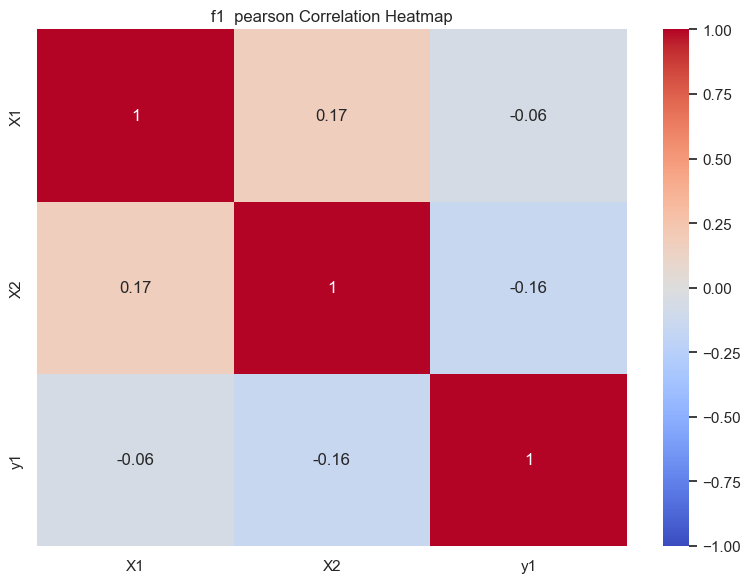


f2 Pearson Correlation Matrix


,X1,X2,y1
X1,1.000000,0.136646,0.407544
X2,0.136646,1.000000,0.160052
y1,0.407544,0.160052,1.000000


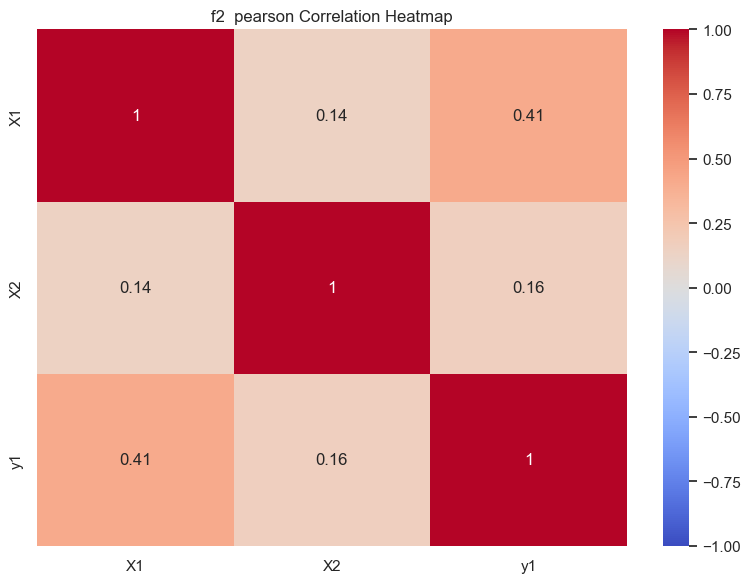


f3 Pearson Correlation Matrix


,X1,X2,X3,y1
X1,1.000000,0.086038,0.011505,0.072455
X2,0.086038,1.000000,-0.442155,0.232378
X3,0.011505,-0.442155,1.000000,-0.527740
y1,0.072455,0.232378,-0.527740,1.000000


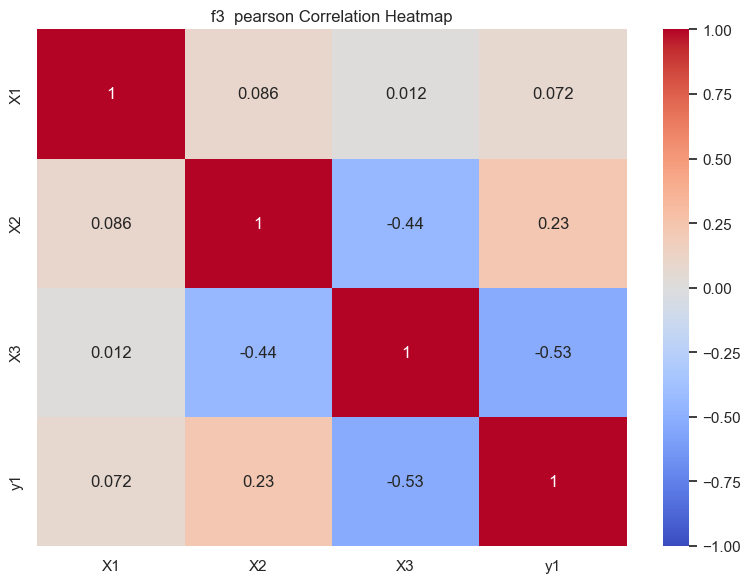


f4 Pearson Correlation Matrix


,X1,X2,X3,X4,y1
X1,1.000000,0.254204,0.258758,0.191442,-0.491802
X2,0.254204,1.000000,-0.066188,0.190050,-0.463809
X3,0.258758,-0.066188,1.000000,-0.149177,-0.133925
X4,0.191442,0.190050,-0.149177,1.000000,-0.462357
y1,-0.491802,-0.463809,-0.133925,-0.462357,1.000000


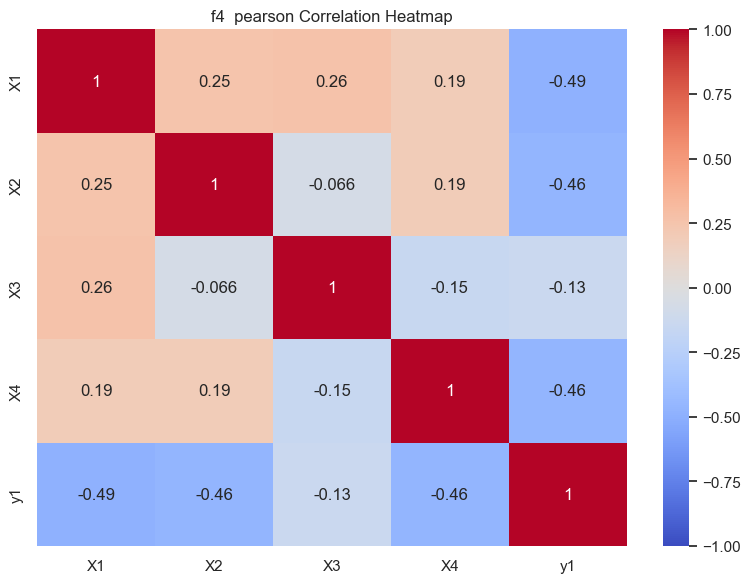


f5 Pearson Correlation Matrix


,X1,X2,X3,X4,y1
X1,1.000000,-0.132515,-0.046623,0.278915,0.288924
X2,-0.132515,1.000000,0.159095,0.187912,0.453674
X3,-0.046623,0.159095,1.000000,-0.007751,0.574226
X4,0.278915,0.187912,-0.007751,1.000000,0.402601
y1,0.288924,0.453674,0.574226,0.402601,1.000000


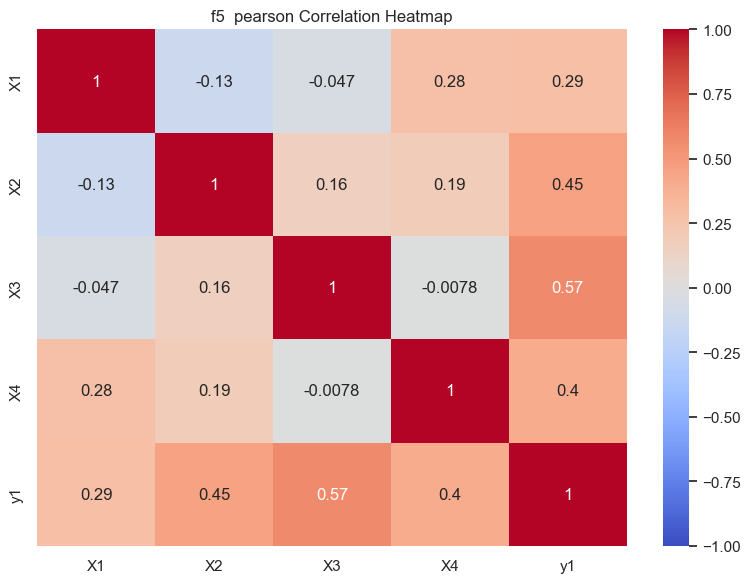


f6 Pearson Correlation Matrix


,X1,X2,X3,X4,X5,y1
X1,1.000000,-0.197642,-0.074095,0.114561,-0.364443,0.043167
X2,-0.197642,1.000000,0.158191,-0.293924,0.335211,-0.492988
X3,-0.074095,0.158191,1.000000,0.196055,-0.135919,0.284584
X4,0.114561,-0.293924,0.196055,1.000000,-0.333730,0.620582
X5,-0.364443,0.335211,-0.135919,-0.333730,1.000000,-0.643077
y1,0.043167,-0.492988,0.284584,0.620582,-0.643077,1.000000


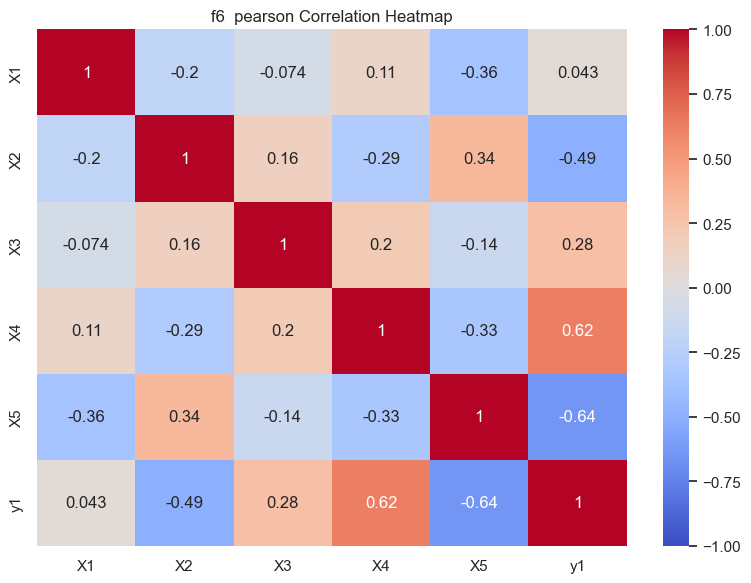


f7 Pearson Correlation Matrix


,X1,X2,X3,X4,X5,X6,y1
X1,1.000000,0.049652,-0.076672,-0.064363,0.014852,-0.434784,-0.433894
X2,0.049652,1.000000,0.081014,0.128265,0.338181,0.133103,-0.047071
X3,-0.076672,0.081014,1.000000,0.199460,-0.244729,0.038402,0.075186
X4,-0.064363,0.128265,0.199460,1.000000,0.069751,0.017322,-0.142375
X5,0.014852,0.338181,-0.244729,0.069751,1.000000,0.067816,-0.391657
X6,-0.434784,0.133103,0.038402,0.017322,0.067816,1.000000,0.350697
y1,-0.433894,-0.047071,0.075186,-0.142375,-0.391657,0.350697,1.000000


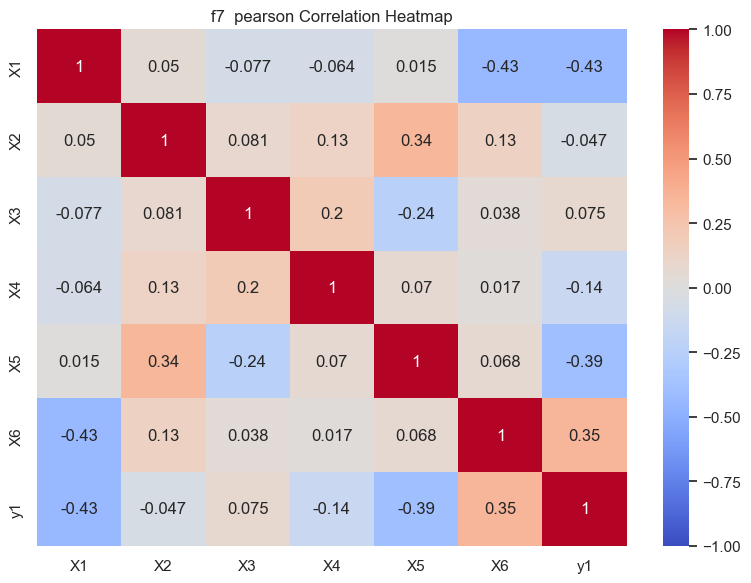


f8 Pearson Correlation Matrix


,X1,X2,X3,X4,X5,X6,X7,X8,y1
X1,1.000000,0.162909,0.091203,0.148557,0.238145,0.153371,0.200447,0.118546,-0.643357
X2,0.162909,1.000000,0.112406,-0.158060,0.058318,0.015886,-0.109196,-0.264884,-0.263280
X3,0.091203,0.112406,1.000000,0.099979,-0.063805,-0.198387,-0.103447,0.001943,-0.661285
X4,0.148557,-0.158060,0.099979,1.000000,-0.063172,-0.109615,-0.029839,0.374282,-0.171586
X5,0.238145,0.058318,-0.063805,-0.063172,1.000000,0.080664,0.152486,0.071832,-0.093656
X6,0.153371,0.015886,-0.198387,-0.109615,0.080664,1.000000,-0.012955,0.057061,0.062779
X7,0.200447,-0.109196,-0.103447,-0.029839,0.152486,-0.012955,1.000000,-0.140989,-0.368870
X8,0.118546,-0.264884,0.001943,0.374282,0.071832,0.057061,-0.140989,1.000000,0.060706
y1,-0.643357,-0.263280,-0.661285,-0.171586,-0.093656,0.062779,-0.368870,0.060706,1.000000


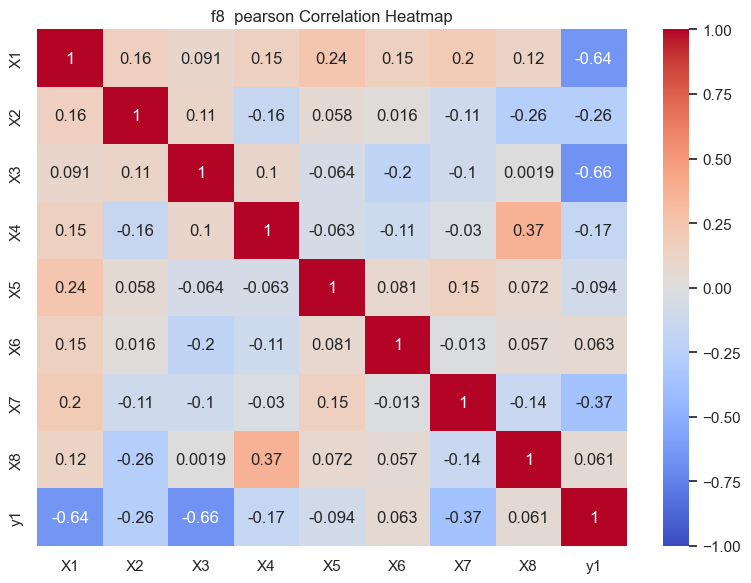

In [11]:
for name, df in functions_data.items():

    print(f"\n{name} Pearson Correlation Matrix")
    
    # Compute correlation matrix
    corr = df.corr()

    # Display numeric correlation table
    display(corr)

    # Plot correlation heatmap
    plt.figure(figsize=(8, 6))
    sns.heatmap(
        corr,
        annot=True,
        cmap='coolwarm',
        vmin=-1,
        vmax=1
    )
    plt.title(f"{name}  pearson Correlation Heatmap")
    plt.tight_layout()
    plt.show()

#### Spearman Correlation


f1 — Spearman Correlation


,X1,X2,y1
X1,1.000000,-0.093407,0.302198
X2,-0.093407,1.000000,0.620879
y1,0.302198,0.620879,1.000000


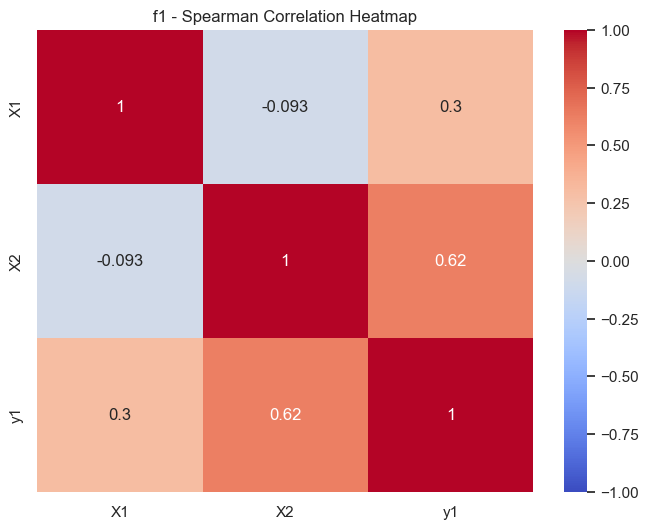


f2 — Spearman Correlation


,X1,X2,y1
X1,1.000000,0.065934,0.335165
X2,0.065934,1.000000,0.142857
y1,0.335165,0.142857,1.000000


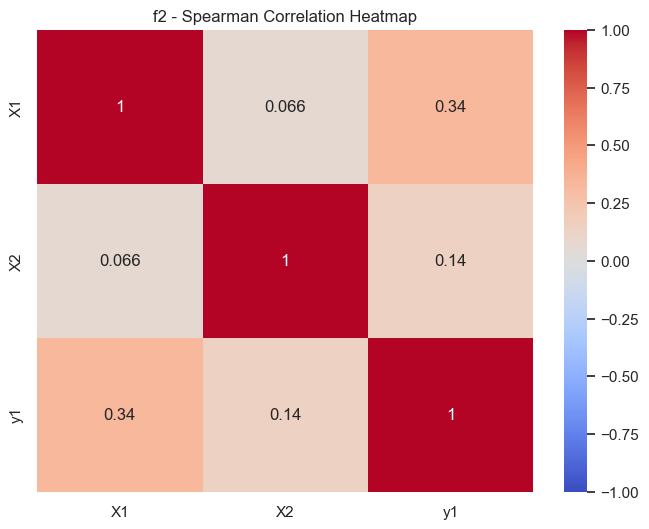


f3 — Spearman Correlation


,X1,X2,X3,y1
X1,1.000000,0.174407,-0.131063,-0.031992
X2,0.174407,1.000000,-0.434469,0.331269
X3,-0.131063,-0.434469,1.000000,-0.250774
y1,-0.031992,0.331269,-0.250774,1.000000


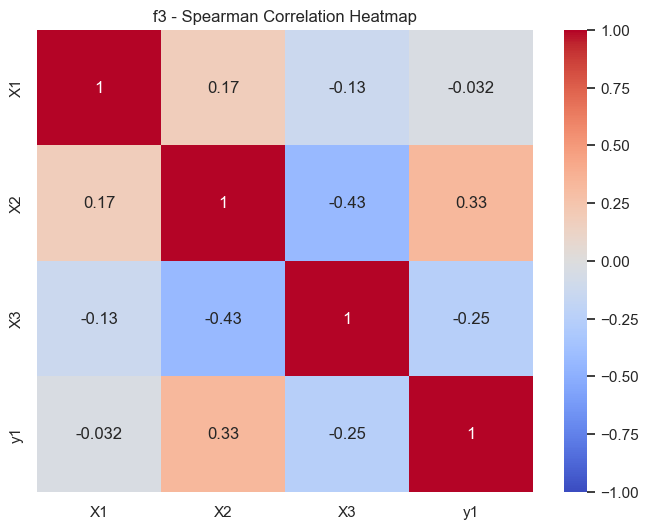


f4 — Spearman Correlation


,X1,X2,X3,X4,y1
X1,1.000000,0.262701,0.238971,0.189840,-0.510361
X2,0.262701,1.000000,-0.019719,0.165107,-0.457219
X3,0.238971,-0.019719,1.000000,-0.175134,-0.171123
X4,0.189840,0.165107,-0.175134,1.000000,-0.410762
y1,-0.510361,-0.457219,-0.171123,-0.410762,1.000000


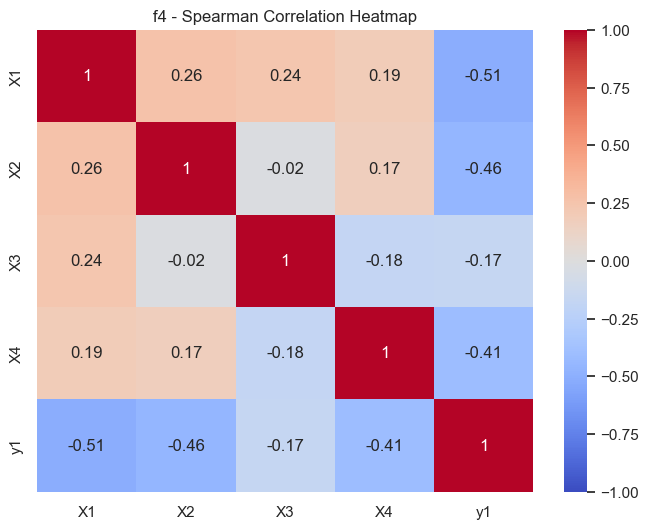


f5 — Spearman Correlation


,X1,X2,X3,X4,y1
X1,1.000000,-0.188735,-0.033597,0.237154,-0.034585
X2,-0.188735,1.000000,0.256917,0.182806,0.400198
X3,-0.033597,0.256917,1.000000,-0.018775,0.520751
X4,0.237154,0.182806,-0.018775,1.000000,0.500000
y1,-0.034585,0.400198,0.520751,0.500000,1.000000


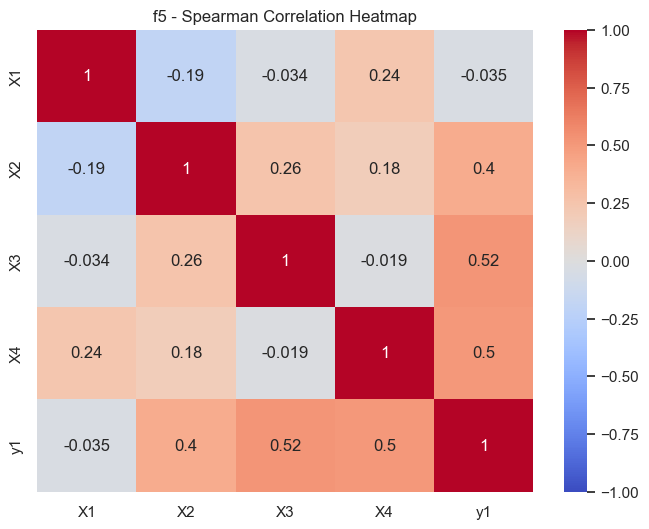


f6 — Spearman Correlation


,X1,X2,X3,X4,X5,y1
X1,1.000000,-0.151186,-0.044466,0.120553,-0.335968,-0.055336
X2,-0.151186,1.000000,0.097826,-0.259881,0.278656,-0.417984
X3,-0.044466,0.097826,1.000000,0.236166,-0.171937,0.263834
X4,0.120553,-0.259881,0.236166,1.000000,-0.392292,0.638340
X5,-0.335968,0.278656,-0.171937,-0.392292,1.000000,-0.629447
y1,-0.055336,-0.417984,0.263834,0.638340,-0.629447,1.000000


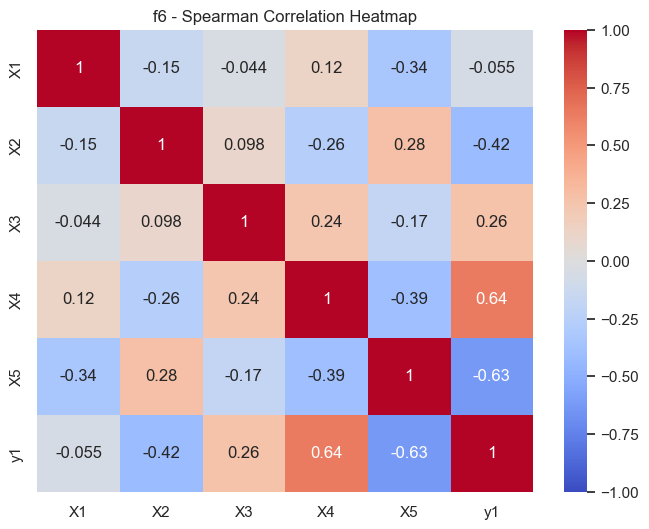


f7 — Spearman Correlation


,X1,X2,X3,X4,X5,X6,y1
X1,1.000000,0.000000,-0.067513,-0.050802,-0.030749,-0.382353,-0.396725
X2,0.000000,1.000000,0.065508,0.176805,0.348596,0.144051,-0.163770
X3,-0.067513,0.065508,1.000000,0.142045,-0.265374,0.081885,0.240976
X4,-0.050802,0.176805,0.142045,1.000000,0.064171,0.047126,-0.153075
X5,-0.030749,0.348596,-0.265374,0.064171,1.000000,0.055147,-0.447527
X6,-0.382353,0.144051,0.081885,0.047126,0.055147,1.000000,0.229612
y1,-0.396725,-0.163770,0.240976,-0.153075,-0.447527,0.229612,1.000000


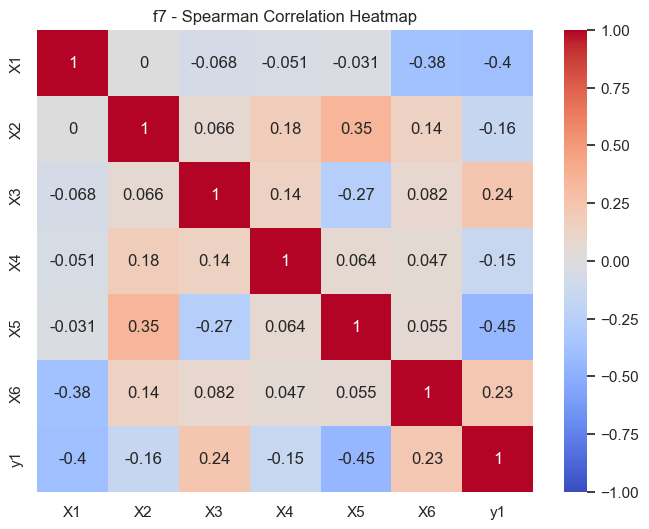


f8 — Spearman Correlation


,X1,X2,X3,X4,X5,X6,X7,X8,y1
X1,1.000000,0.171398,0.060254,0.144820,0.245243,0.161734,0.188010,0.111900,-0.624887
X2,0.171398,1.000000,0.127454,-0.164603,0.033827,-0.006191,-0.102235,-0.260344,-0.268952
X3,0.060254,0.127454,1.000000,0.138780,-0.077922,-0.168831,-0.087285,-0.034733,-0.617638
X4,0.144820,-0.164603,0.138780,1.000000,-0.086228,-0.136213,-0.015403,0.356992,-0.185291
X5,0.245243,0.033827,-0.077922,-0.086228,1.000000,0.123377,0.159015,0.034733,-0.054968
X6,0.161734,-0.006191,-0.168831,-0.136213,0.123377,1.000000,0.008457,0.099517,0.017970
X7,0.188010,-0.102235,-0.087285,-0.015403,0.159015,0.008457,1.000000,-0.131531,-0.365297
X8,0.111900,-0.260344,-0.034733,0.356992,0.034733,0.099517,-0.131531,1.000000,0.054666
y1,-0.624887,-0.268952,-0.617638,-0.185291,-0.054968,0.017970,-0.365297,0.054666,1.000000


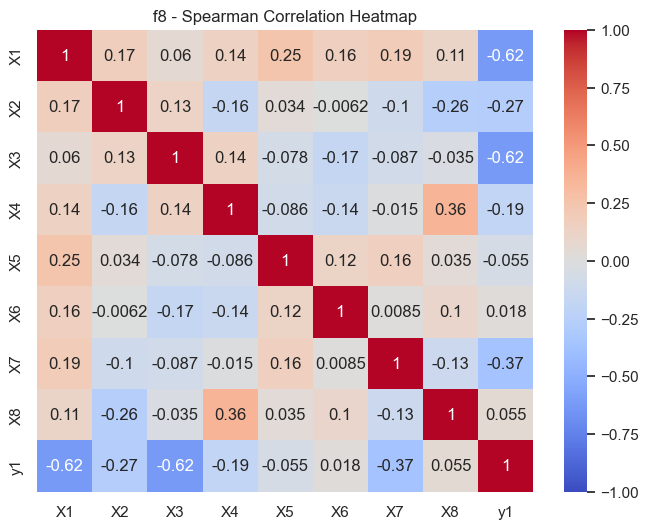

In [12]:
for name, df in functions_data.items():
    print(f"\n{name} — Spearman Correlation")
    
    input_cols = [c for c in df.columns if c.startswith("X")]
    output_cols = [c for c in df.columns if c.startswith("y")]

    spearman_corr = df[input_cols + output_cols].corr(method='spearman')
    display(spearman_corr)
    
    plt.figure(figsize=(8, 6))
    sns.heatmap(spearman_corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
    plt.title(f"{name} - Spearman Correlation Heatmap")
    plt.show()

#### Kendall Correlation


f1 — Kendall Correlation


,X1,X2,y1
X1,1.000000,-0.102564,0.205128
X2,-0.102564,1.000000,0.435897
y1,0.205128,0.435897,1.000000


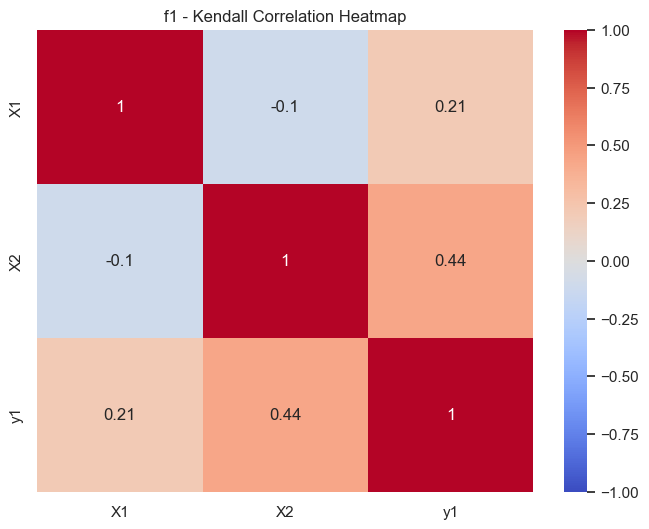


f2 — Kendall Correlation


,X1,X2,y1
X1,1.000000,0.051282,0.256410
X2,0.051282,1.000000,0.128205
y1,0.256410,0.128205,1.000000


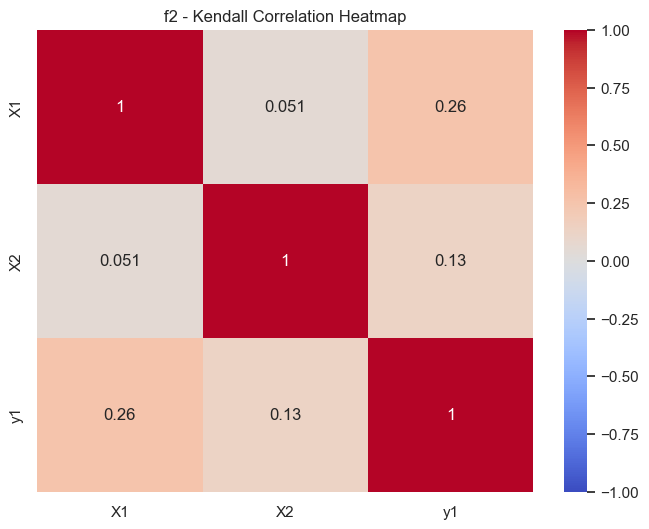


f3 — Kendall Correlation


,X1,X2,X3,y1
X1,1.000000,0.137255,-0.084967,-0.019608
X2,0.137255,1.000000,-0.320261,0.241830
X3,-0.084967,-0.320261,1.000000,-0.137255
y1,-0.019608,0.241830,-0.137255,1.000000


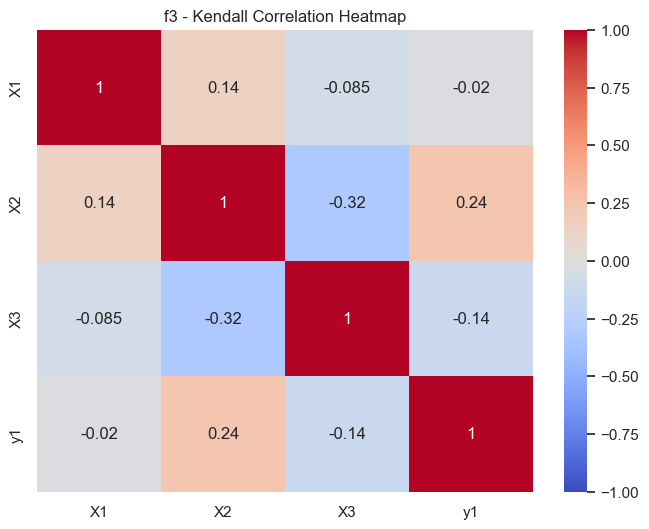


f4 — Kendall Correlation


,X1,X2,X3,X4,y1
X1,1.000000,0.193182,0.189394,0.136364,-0.356061
X2,0.193182,1.000000,-0.003788,0.117424,-0.329545
X3,0.189394,-0.003788,1.000000,-0.136364,-0.166667
X4,0.136364,0.117424,-0.136364,1.000000,-0.287879
y1,-0.356061,-0.329545,-0.166667,-0.287879,1.000000


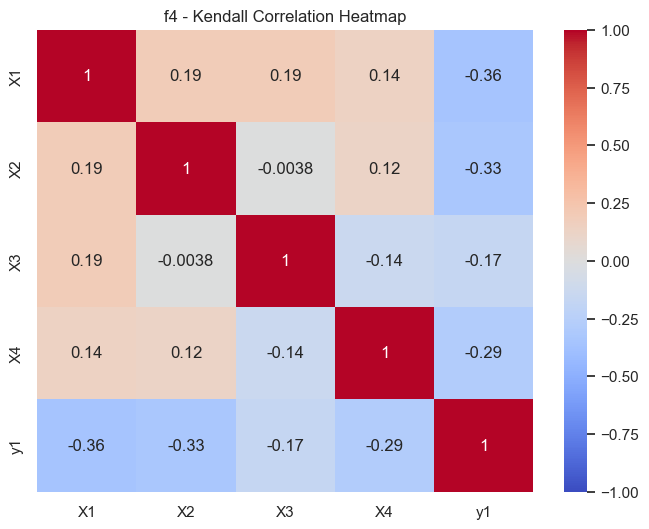


f5 — Kendall Correlation


,X1,X2,X3,X4,y1
X1,1.000000,-0.146245,-0.051383,0.185771,-0.051383
X2,-0.146245,1.000000,0.146245,0.098814,0.241107
X3,-0.051383,0.146245,1.000000,-0.043478,0.399209
X4,0.185771,0.098814,-0.043478,1.000000,0.351779
y1,-0.051383,0.241107,0.399209,0.351779,1.000000


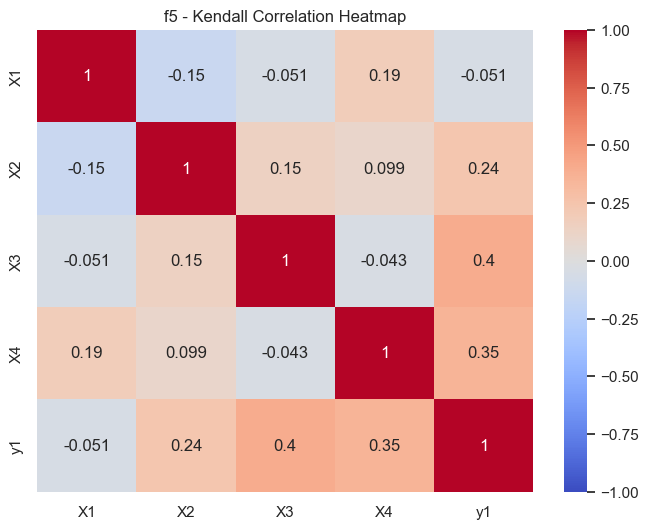


f6 — Kendall Correlation


,X1,X2,X3,X4,X5,y1
X1,1.000000,-0.122530,-0.027668,0.106719,-0.256917,-0.035573
X2,-0.122530,1.000000,0.083004,-0.177866,0.169960,-0.304348
X3,-0.027668,0.083004,1.000000,0.169960,-0.083004,0.185771
X4,0.106719,-0.177866,0.169960,1.000000,-0.328063,0.462451
X5,-0.256917,0.169960,-0.083004,-0.328063,1.000000,-0.438735
y1,-0.035573,-0.304348,0.185771,0.462451,-0.438735,1.000000


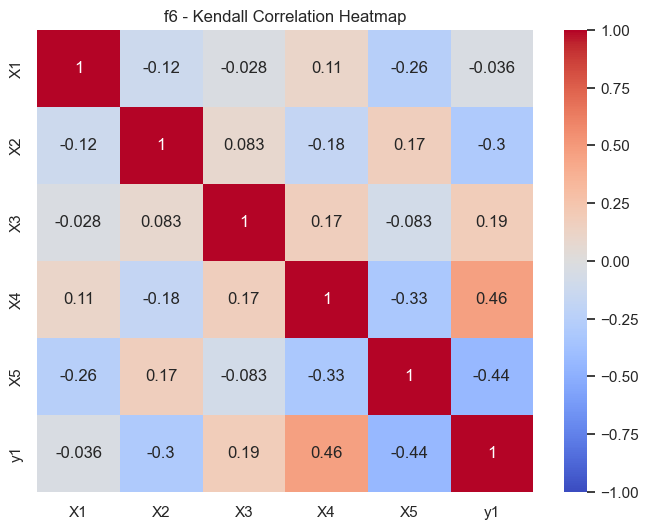


f7 — Kendall Correlation


,X1,X2,X3,X4,X5,X6,y1
X1,1.000000,0.026515,-0.045455,-0.041667,-0.049242,-0.257576,-0.321970
X2,0.026515,1.000000,0.041667,0.113636,0.234848,0.071970,-0.121212
X3,-0.045455,0.041667,1.000000,0.071970,-0.178030,0.068182,0.155303
X4,-0.041667,0.113636,0.071970,1.000000,0.045455,0.011364,-0.113636
X5,-0.049242,0.234848,-0.178030,0.045455,1.000000,0.064394,-0.303030
X6,-0.257576,0.071970,0.068182,0.011364,0.064394,1.000000,0.155303
y1,-0.321970,-0.121212,0.155303,-0.113636,-0.303030,0.155303,1.000000


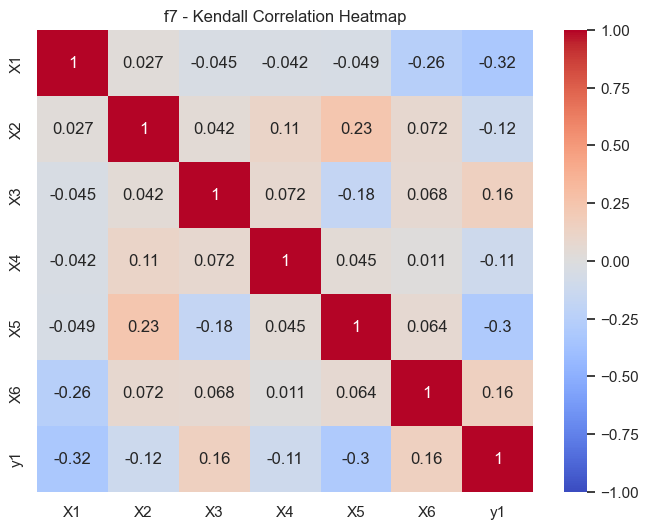


f8 — Kendall Correlation


,X1,X2,X3,X4,X5,X6,X7,X8,y1
X1,1.000000,0.127353,0.012182,0.087486,0.162791,0.089701,0.111849,0.071982,-0.450720
X2,0.127353,1.000000,0.078627,-0.125138,0.034330,-0.034330,-0.083056,-0.162791,-0.162791
X3,0.012182,0.078627,1.000000,0.074197,-0.045404,-0.118494,-0.052049,-0.025471,-0.450720
X4,0.087486,-0.125138,0.074197,1.000000,-0.054264,-0.065338,-0.007752,0.253599,-0.122924
X5,0.162791,0.034330,-0.045404,-0.054264,1.000000,0.089701,0.107420,0.032115,-0.025471
X6,0.089701,-0.034330,-0.118494,-0.065338,0.089701,1.000000,0.012182,0.060908,-0.001107
X7,0.111849,-0.083056,-0.052049,-0.007752,0.107420,0.012182,1.000000,-0.089701,-0.280177
X8,0.071982,-0.162791,-0.025471,0.253599,0.032115,0.060908,-0.089701,1.000000,0.043189
y1,-0.450720,-0.162791,-0.450720,-0.122924,-0.025471,-0.001107,-0.280177,0.043189,1.000000


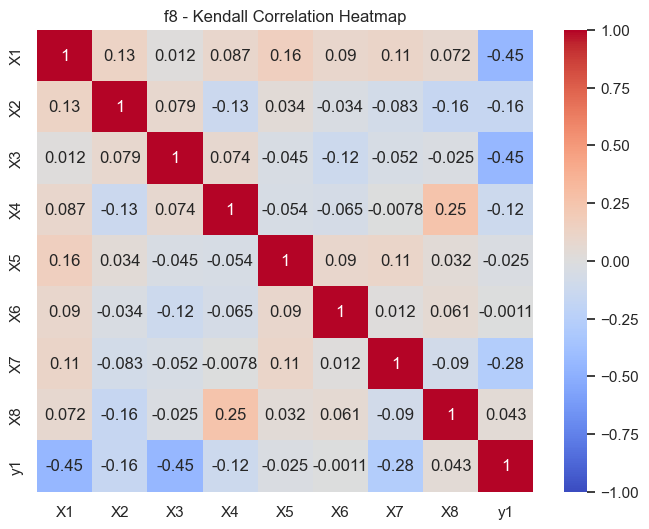

In [13]:
for name, df in functions_data.items():
    print(f"\n{name} — Kendall Correlation")
    
    input_cols = [c for c in df.columns if c.startswith("X")]
    output_cols = [c for c in df.columns if c.startswith("y")]

    kendall_corr = df[input_cols + output_cols].corr(method='kendall')
    display(kendall_corr)
    
    plt.figure(figsize=(8, 6))
    sns.heatmap(kendall_corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
    plt.title(f"{name} - Kendall Correlation Heatmap")
    plt.show()


#### Mutual Information

In [14]:
from sklearn.feature_selection import mutual_info_regression

for name, df in functions_data.items():
    print(f"\n=== {name} — Mutual Information with Output ===")
    
    input_cols = [c for c in df.columns if c.startswith("X")]
    output_cols = [c for c in df.columns if c.startswith("y")]

    X = df[input_cols].values
    y = df[output_cols[0]].values

    mi = mutual_info_regression(X, y, random_state=42)
    mi_df = pd.DataFrame({'Feature': input_cols, 'Mutual_Info': mi}).sort_values(by='Mutual_Info', ascending=False)
    display(mi_df)



=== f1 — Mutual Information with Output ===


,Feature,Mutual_Info
0,X1,0.025641
1,X2,0.000000



=== f2 — Mutual Information with Output ===


,Feature,Mutual_Info
0,X1,0.215207
1,X2,0.000000



=== f3 — Mutual Information with Output ===


...

,Feature,Mutual_Info
4,X5,0.212394
3,X4,0.160580
0,X1,0.000000
1,X2,0.000000
2,X3,0.000000



=== f7 — Mutual Information with Output ===


,Feature,Mutual_Info
4,X5,0.142754
0,X1,0.141603
5,X6,0.078037
1,X2,0.000000
2,X3,0.000000
3,X4,0.000000



=== f8 — Mutual Information with Output ===


,Feature,Mutual_Info
2,X3,0.314956
0,X1,0.283513
6,X7,0.113041
1,X2,0.000000
3,X4,0.000000
4,X5,0.000000
5,X6,0.000000
7,X8,0.000000


#### Parital Correlation

In [15]:
!pip install pingouin
import pingouin as pg

for name, df in functions_data.items():
    print(f"\n=== {name} — Partial Correlation ===")
    
    input_cols = [c for c in df.columns if c.startswith("X")]
    output_cols = [c for c in df.columns if c.startswith("y")]

    for x in input_cols:
        pcorr = pg.partial_corr(data=df, x=x, y=output_cols[0], covar=[c for c in input_cols if c != x])
        print(pcorr)



=== f1 — Partial Correlation ===
          n         r         CI95%     p-val
pearson  13 -0.034658  [-0.6, 0.55]  0.914846
          n        r          CI95%     p-val
pearson  13 -0.14821  [-0.67, 0.47]  0.645738

=== f2 — Partial Correlation ===
          n        r          CI95%     p-val
pearson  13  0.39441  [-0.23, 0.79]  0.204539
          n         r          CI95%    p-val
pearson  13  0.115366  [-0.49, 0.65]  0.72107

=== f3 — Partial Correlation ===
          n         r          CI95%     p-val
pearson  18  0.093066  [-0.42, 0.56]  0.731741
          n         r         CI95%     p-val
pearson  18 -0.010762  [-0.5, 0.49]  0.968447
          n        r          CI95%     p-val
pearson  18 -0.49164  [-0.79, 0.01]  0.053091

=== f4 — Partial Correlation ===
          n         r          CI95%     p-val
pearson  33 -0.361517  [-0.64, -0.0]  0.049653
          n         r           CI95%     p-val
pearson  33 -0.396628  [-0.66, -0.04]  0.030007
          n        r        

#### Features vs Outputs Plots


Feature vs Output Plots for f1
X shape for f1: (13, 2)
y shape for f1: (13,)


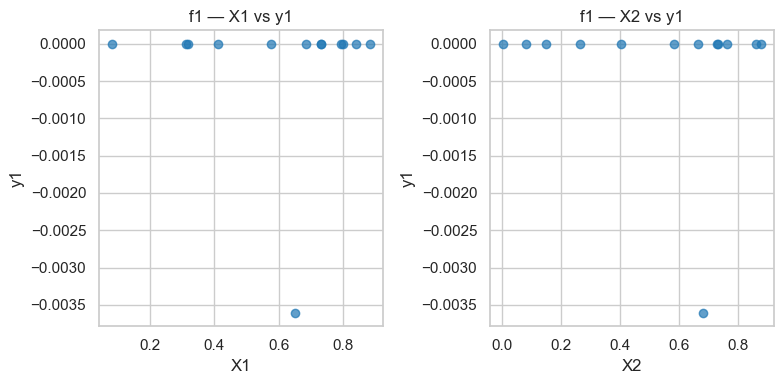


Feature vs Output Plots for f2
X shape for f2: (13, 2)
y shape for f2: (13,)


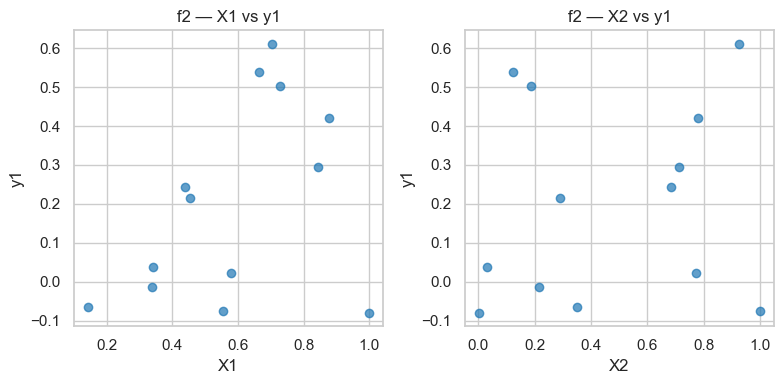


Feature vs Output Plots for f3
X shape for f3: (18, 3)
y shape for f3: (18,)


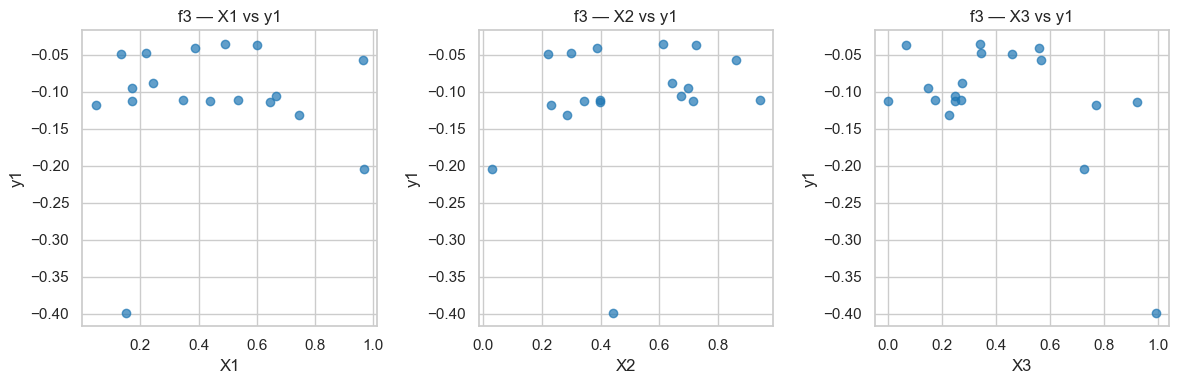


Feature vs Output Plots for f4
X shape for f4: (33, 4)
y shape for f4: (33,)


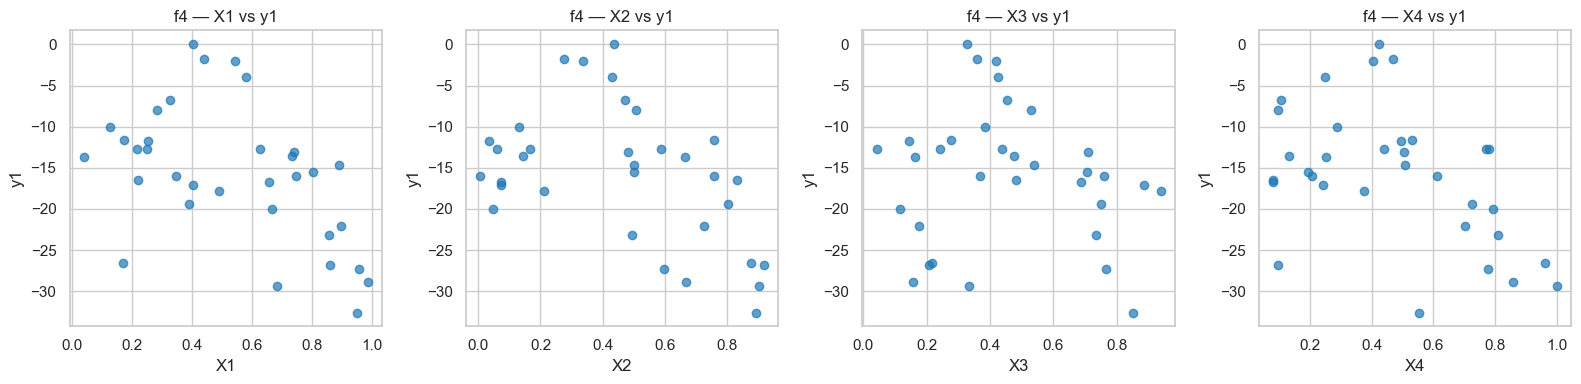


Feature vs Output Plots for f5
X shape for f5: (23, 4)
y shape for f5: (23,)


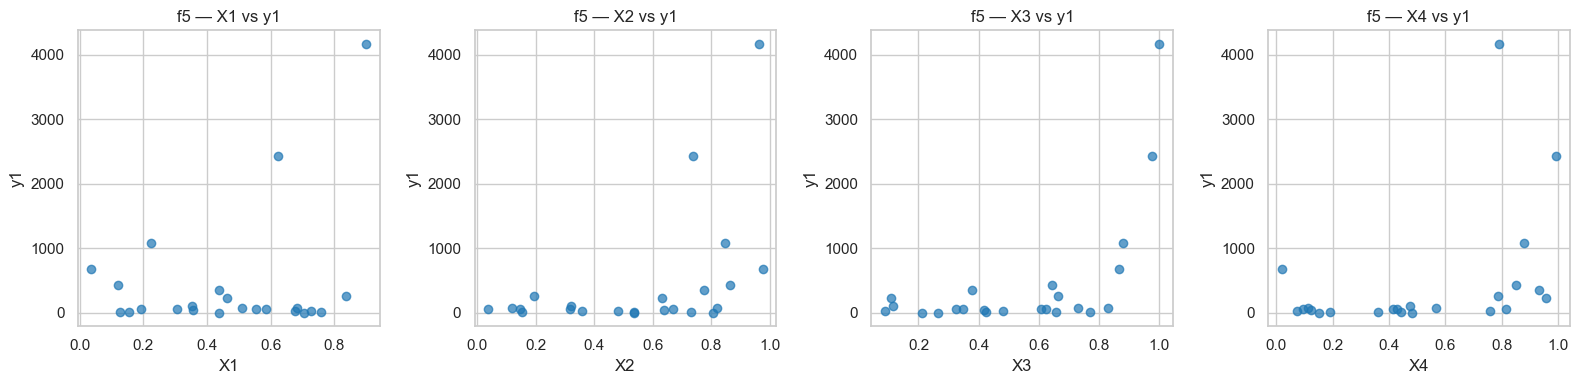


Feature vs Output Plots for f6
X shape for f6: (23, 5)
y shape for f6: (23,)


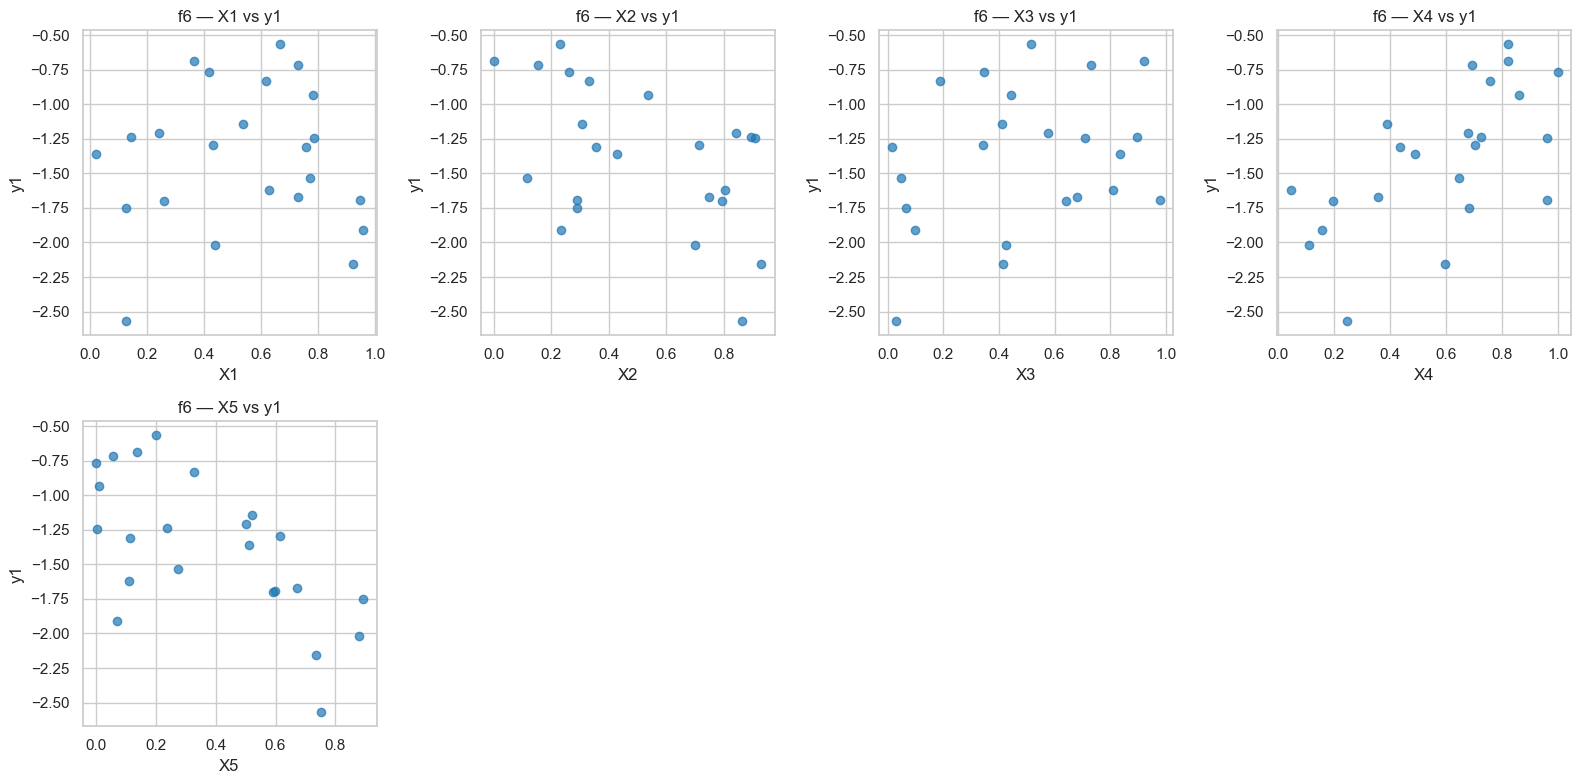


Feature vs Output Plots for f7
X shape for f7: (33, 6)
y shape for f7: (33,)


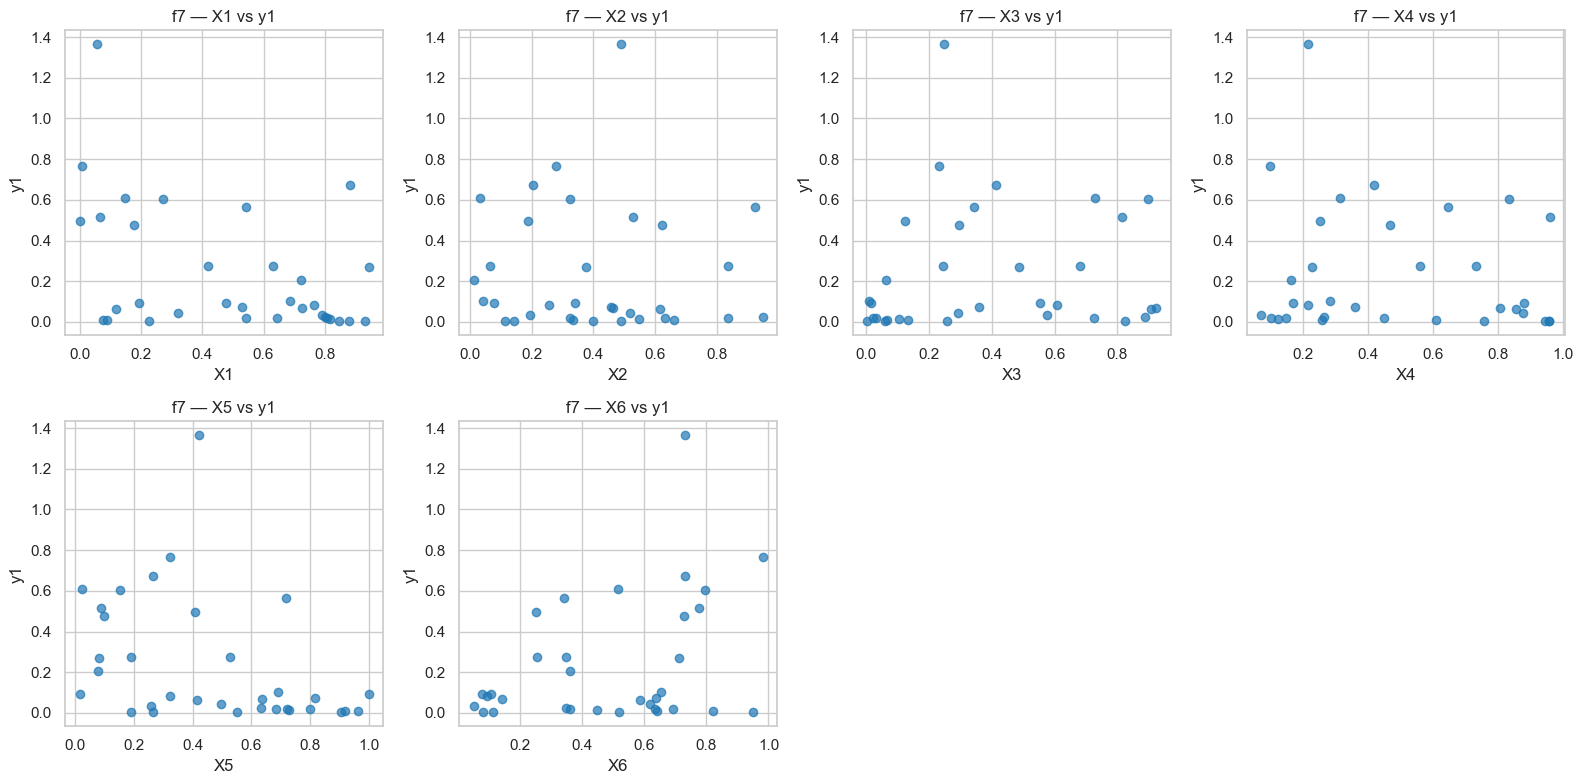


Feature vs Output Plots for f8
X shape for f8: (43, 8)
y shape for f8: (43,)


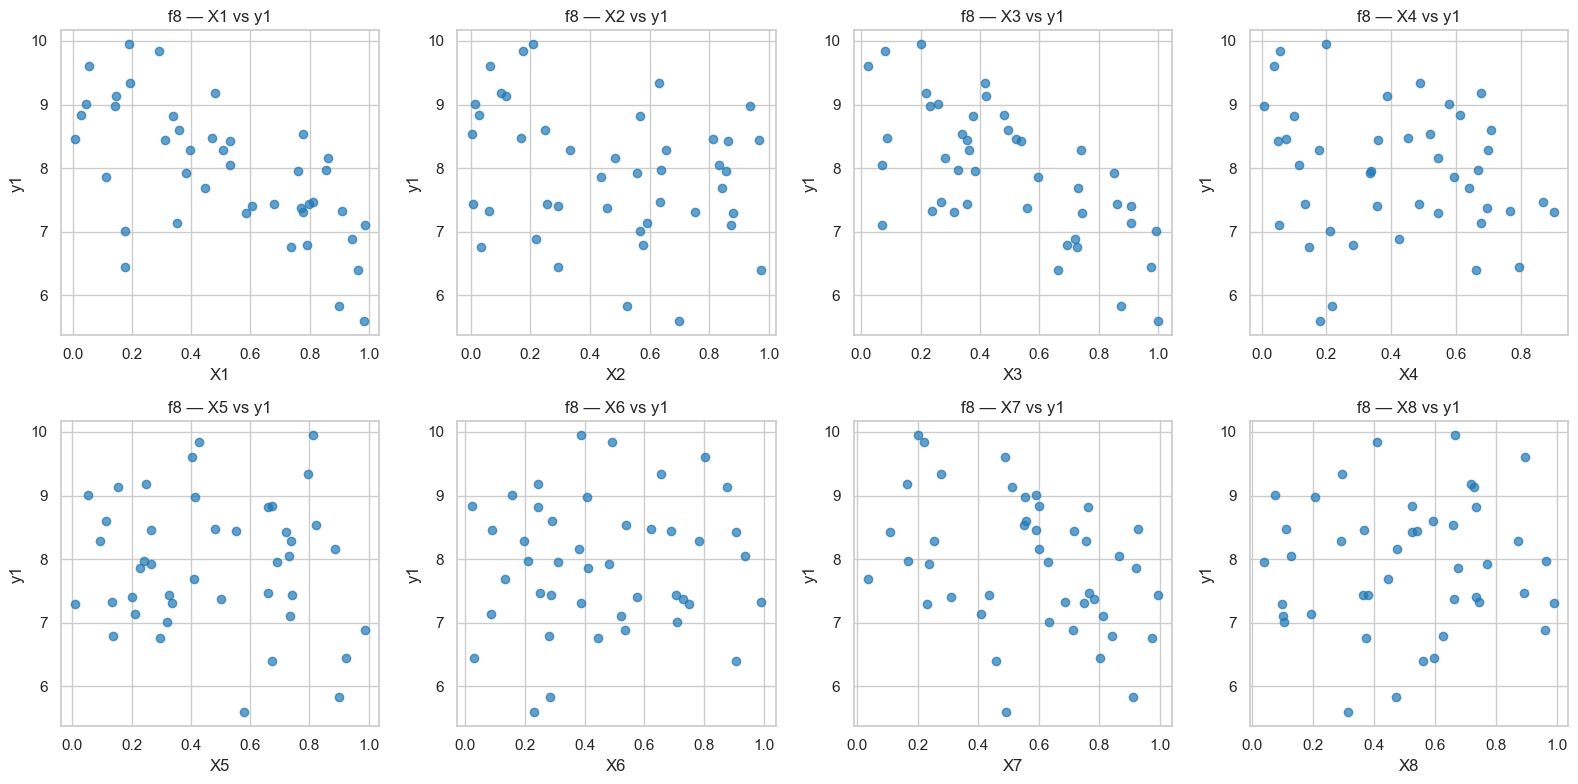

In [16]:
for name, df in functions_data.items():

    print(f"\nFeature vs Output Plots for {name}")

    
    # Extract input/output columns
    input_cols = [col for col in df.columns if col.startswith("X")]
    output_cols = [col for col in df.columns if col.startswith("y")]

    X = df[input_cols].values
    y = df[output_cols[0]].values  # use first output column for coloring/plot


    # Sanity checks
    print(f"X shape for {name}: {X.shape}")
    print(f"y shape for {name}: {y.shape}")

    assert X.shape[0] == y.shape[0], f"Mismatch in samples for {name}!"
    expected_features = len(input_cols)
    assert X.shape[1] == expected_features, f"Unexpected feature count in {name}!"


    # Plot each feature vs y
    n_features = X.shape[1]

    # Determine grid size (2 rows, dynamic columns)
    n_cols = min(4, n_features)
    n_rows = (n_features + n_cols - 1) // n_cols

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(4*n_cols, 4*n_rows))
    axes = axes.ravel() if n_features > 1 else [axes]

    for i in range(n_features):
        ax = axes[i]
        ax.scatter(X[:, i], y, color='tab:blue', alpha=0.7)
        ax.set_xlabel(input_cols[i])
        ax.set_ylabel(output_cols[0])
        ax.set_title(f"{name} — {input_cols[i]} vs {output_cols[0]}")

    # Hide unused subplots
    for j in range(n_features, len(axes)):
        axes[j].axis("off")

    plt.tight_layout()
    plt.show()


#### Distribution Analysis


f1 — Feature & Output Distributions


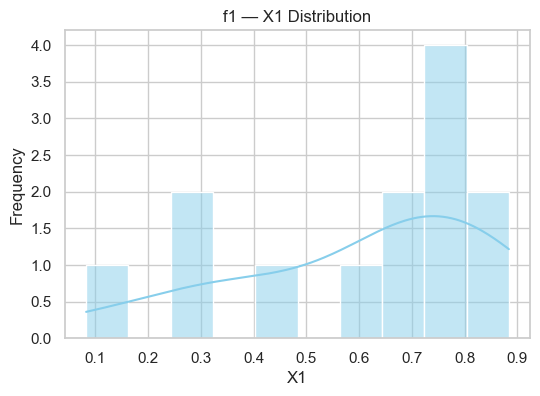

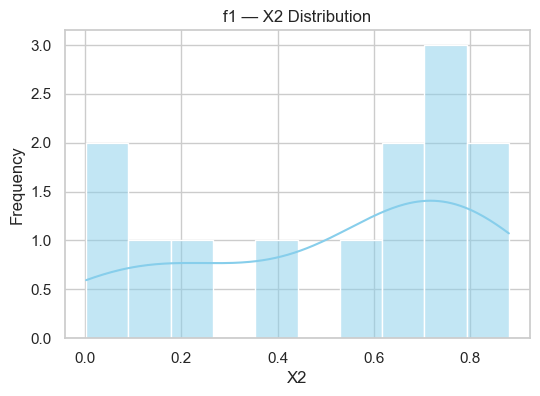

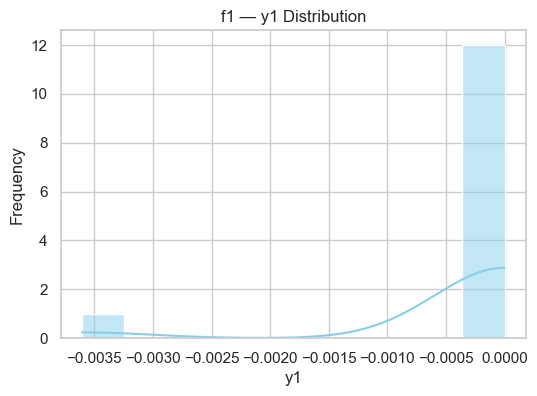


f2 — Feature & Output Distributions


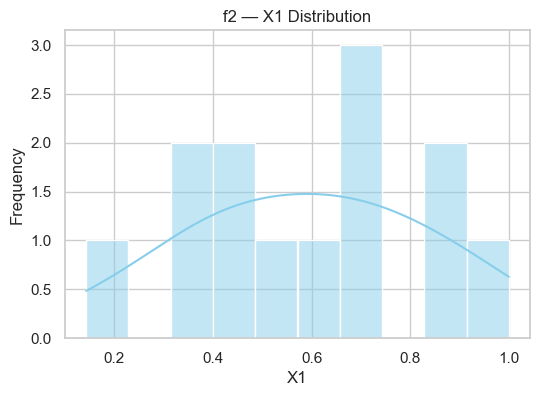

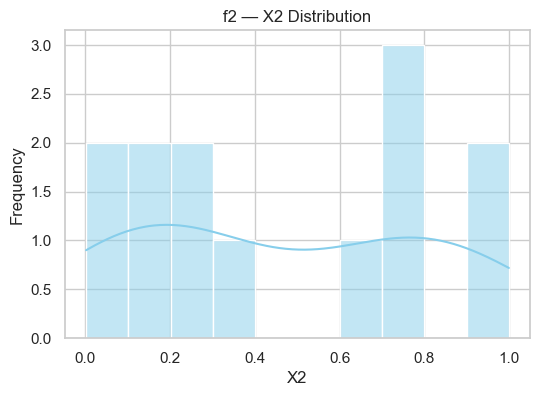

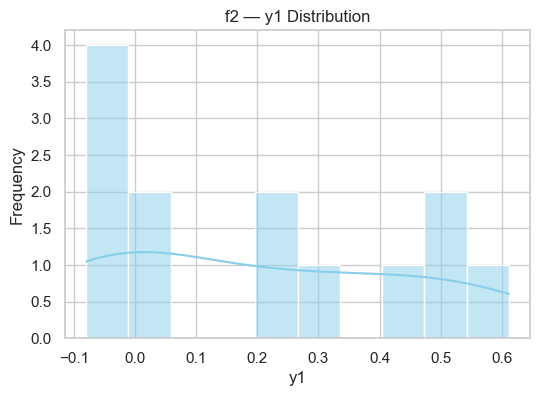


f3 — Feature & Output Distributions


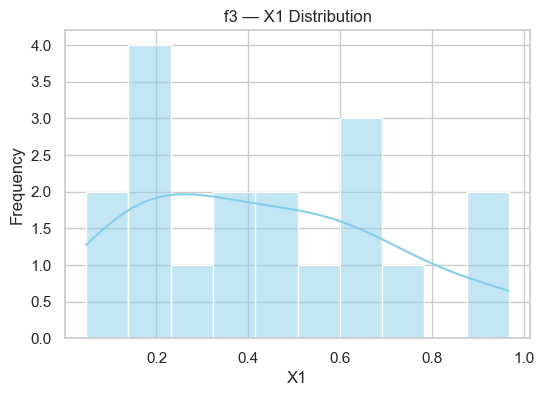

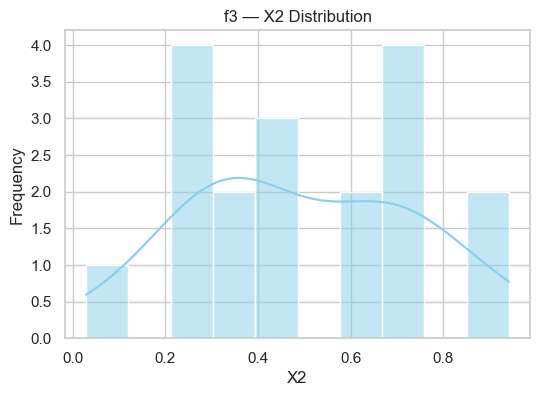

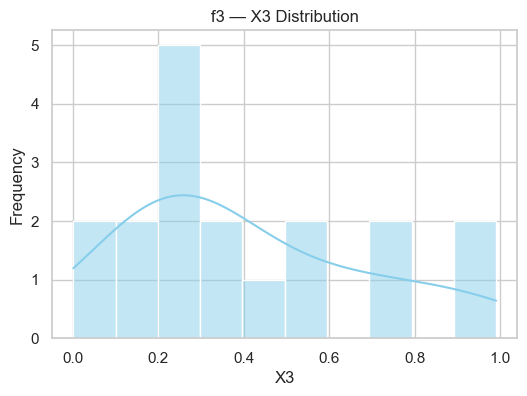

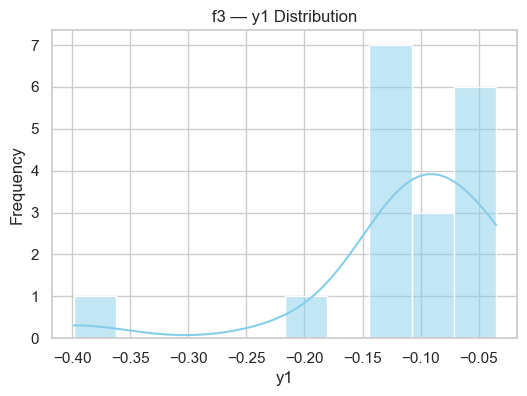


f4 — Feature & Output Distributions


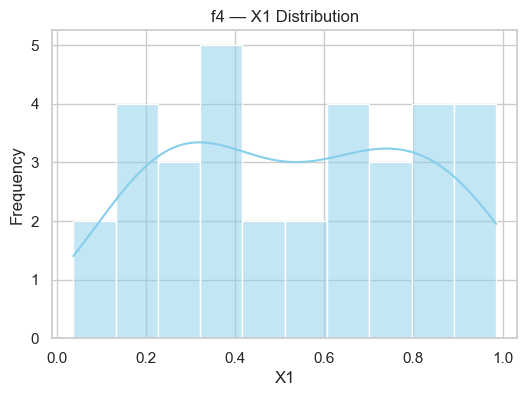

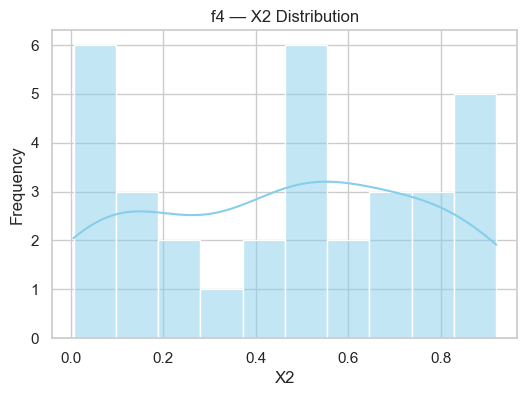

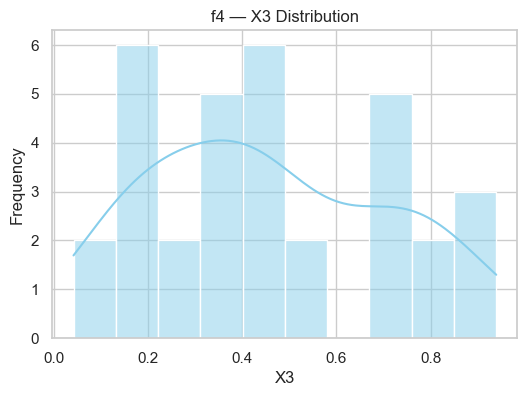

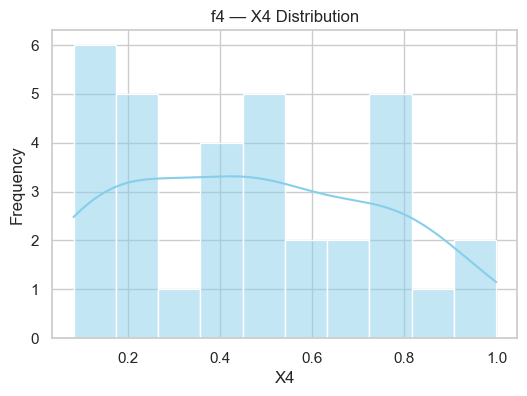

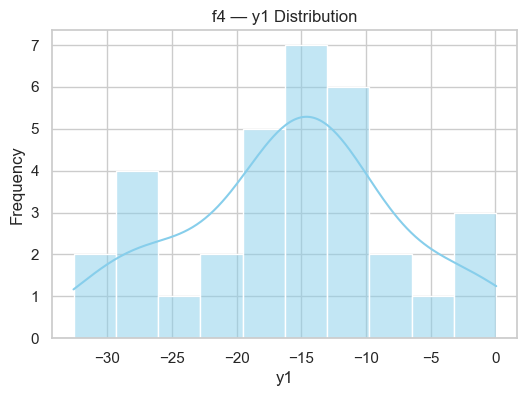


f5 — Feature & Output Distributions


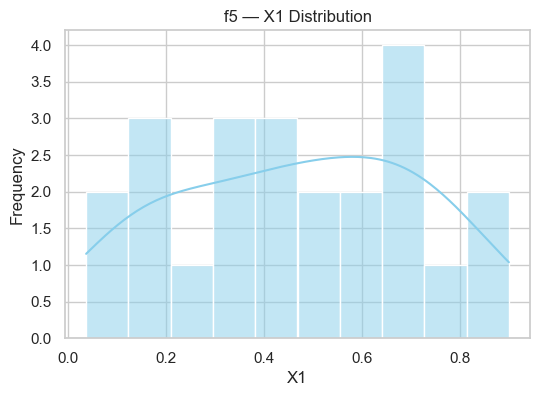

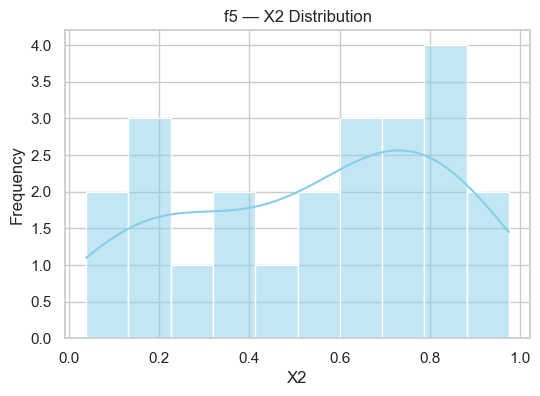

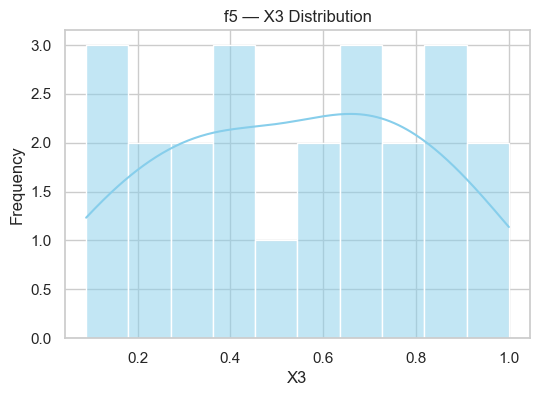

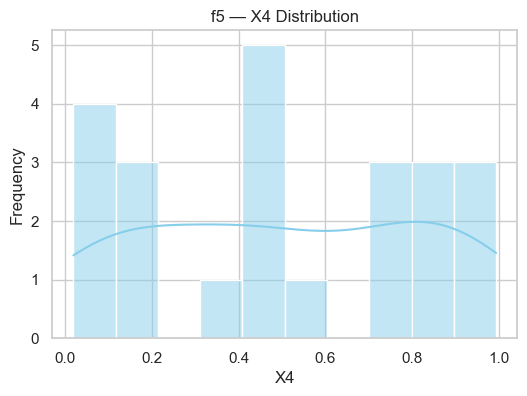

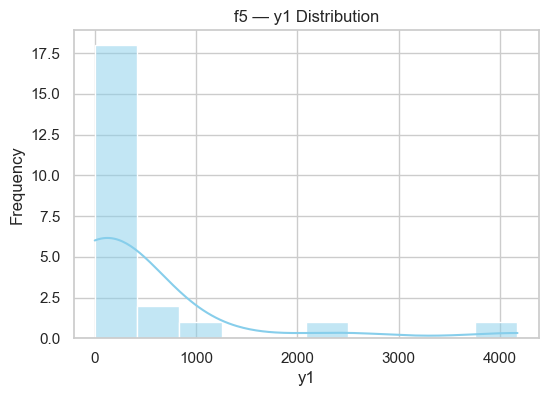


f6 — Feature & Output Distributions


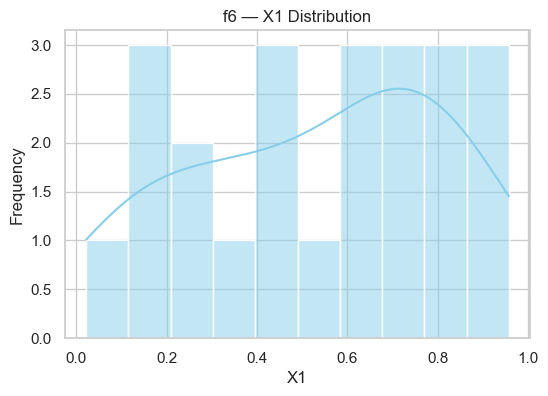

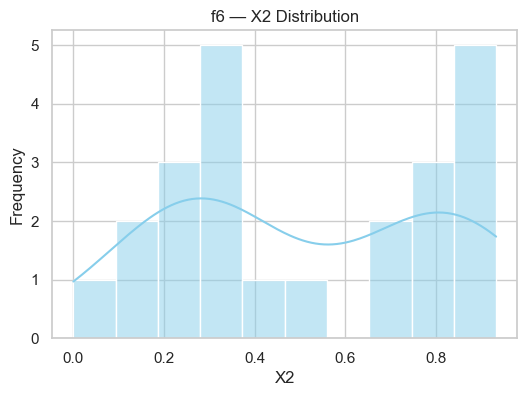

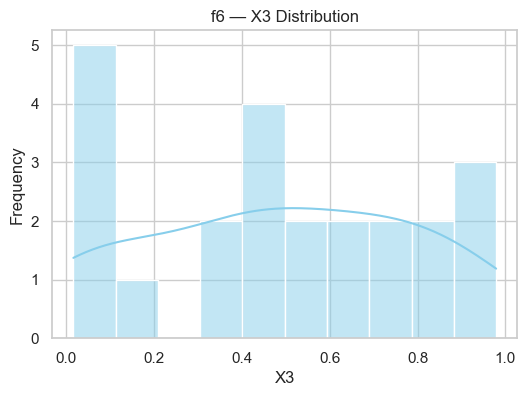

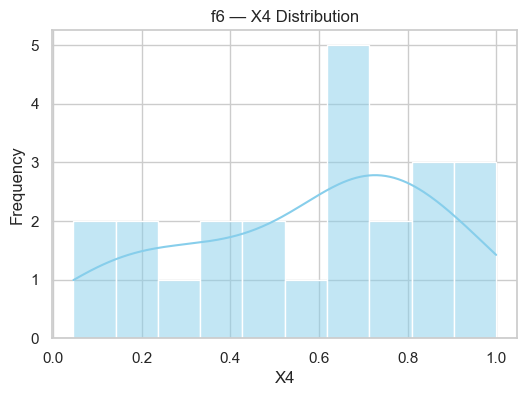

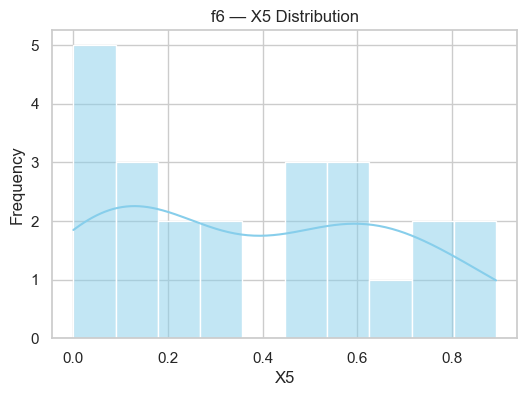

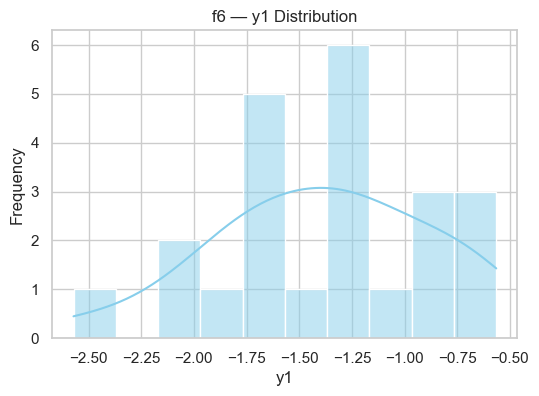


f7 — Feature & Output Distributions


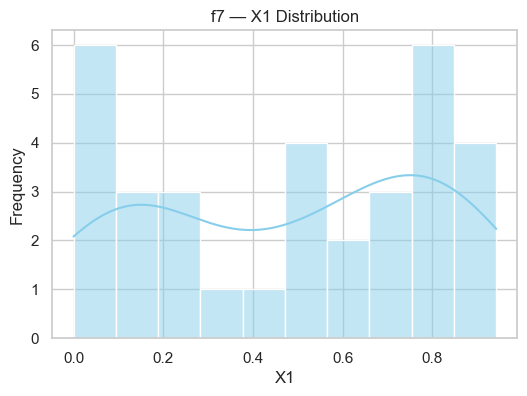

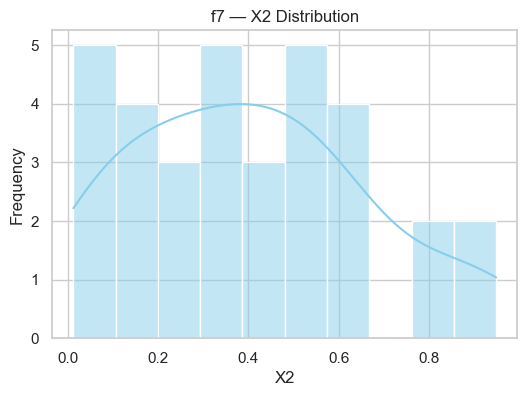

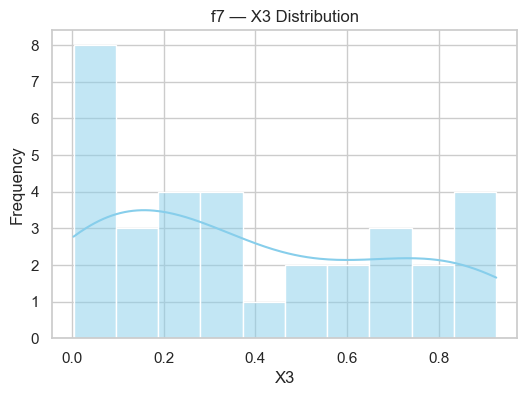

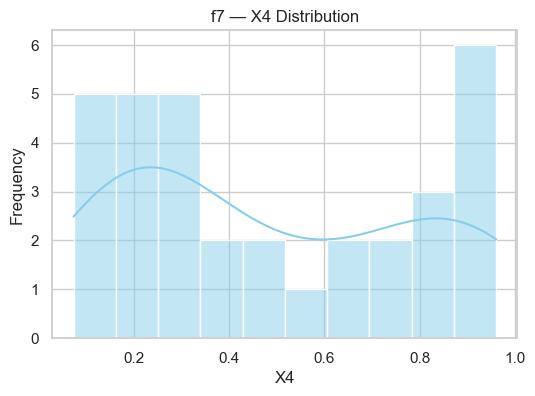

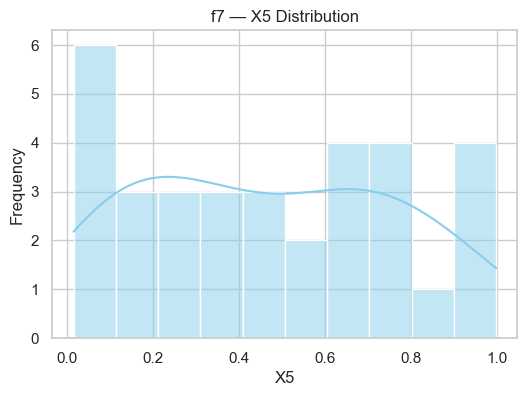

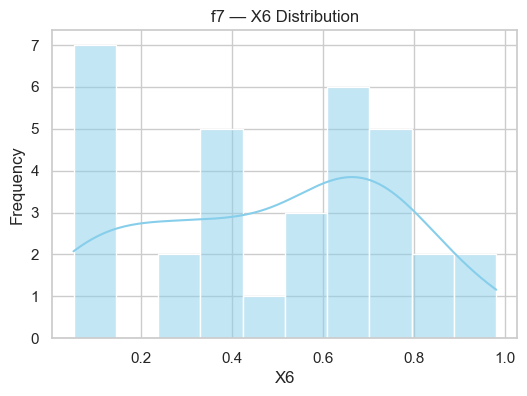

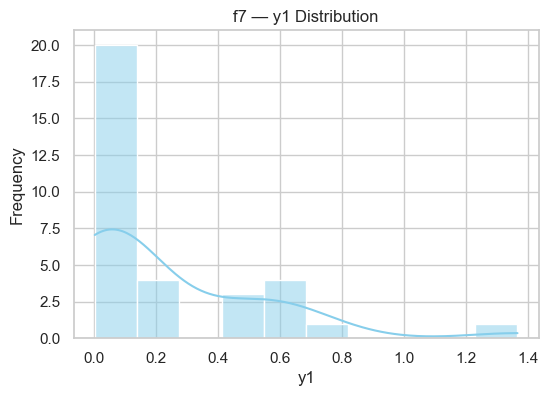


f8 — Feature & Output Distributions


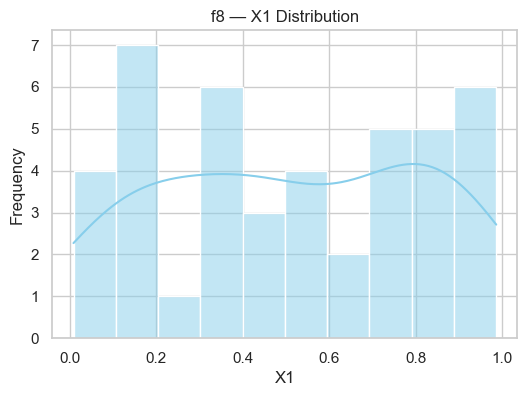

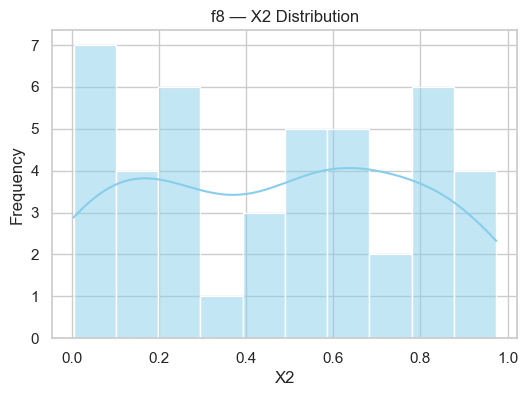

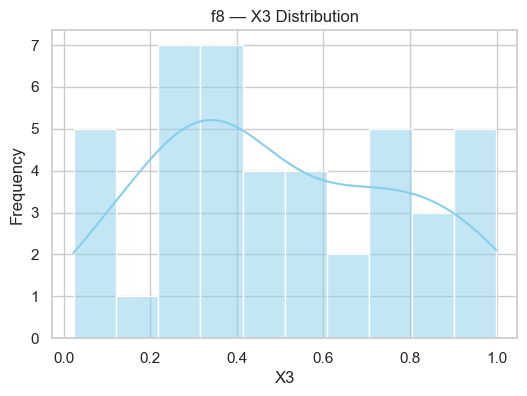

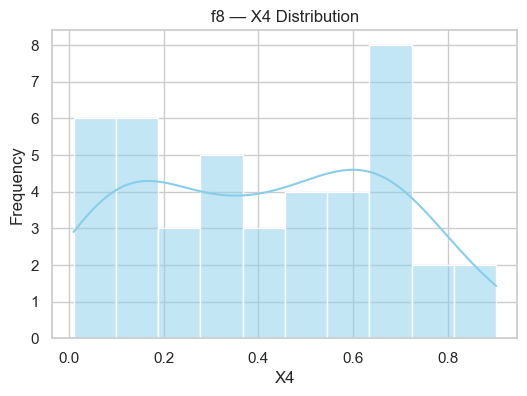

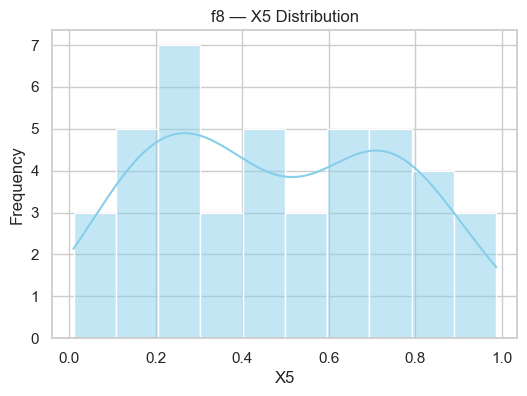

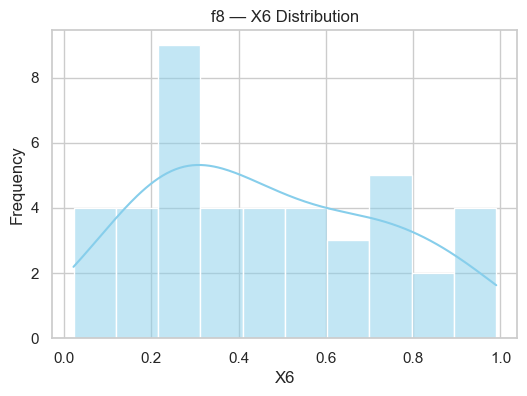

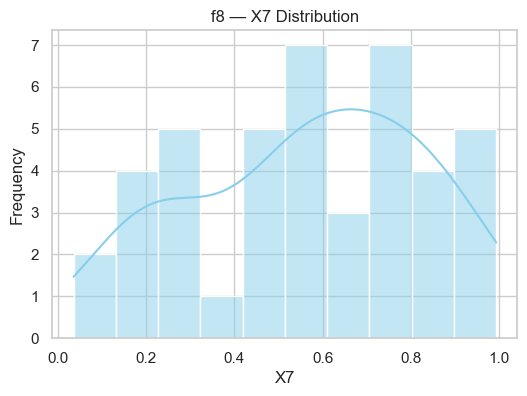

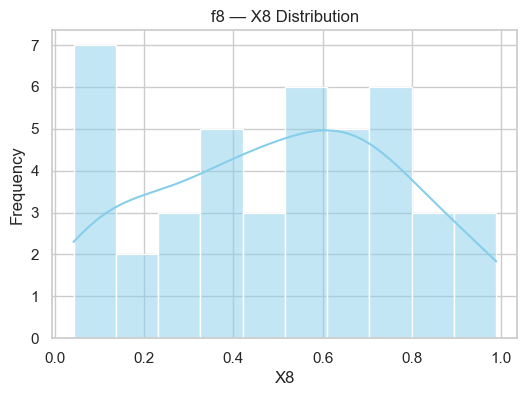

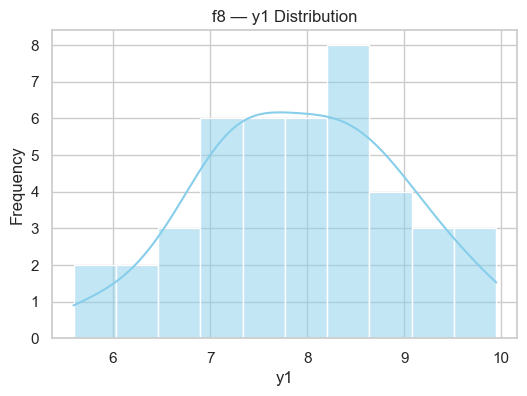

In [17]:
for name, df in functions_data.items():
    print(f"\n{name} — Feature & Output Distributions")
    
    # Identify input and output columns
    input_cols = [c for c in df.columns if c.startswith("X")]
    output_cols = [c for c in df.columns if c.startswith("y")]
    
    all_cols = input_cols + output_cols
    
    for col in all_cols:
        plt.figure(figsize=(6, 4))
        sns.histplot(df[col], kde=True, bins=10, color='skyblue')
        plt.title(f"{name} — {col} Distribution")
        plt.xlabel(col)
        plt.ylabel("Frequency")
        plt.show()


#### Line Plot of y Values


f1 — Full Data Table
          X1        X2             y1
0   0.319404  0.762959   1.322677e-79
1   0.574329  0.879898   1.033078e-46
2   0.731024  0.733000   7.710875e-16
3   0.840353  0.264732  3.341771e-124
4   0.650114  0.681526  -3.606063e-03
5   0.410437  0.147554  -2.159249e-54
6   0.312691  0.078723  -2.089093e-91
7   0.683418  0.861057   2.535001e-40
8   0.082507  0.403488   3.606771e-81
9   0.883890  0.582254   6.229856e-48
10  0.793600  0.666269   1.403499e-21
11  0.800601  0.002800  9.069109e-223
12  0.729726  0.729276   5.314593e-15

f1 — y vs Instance Plot


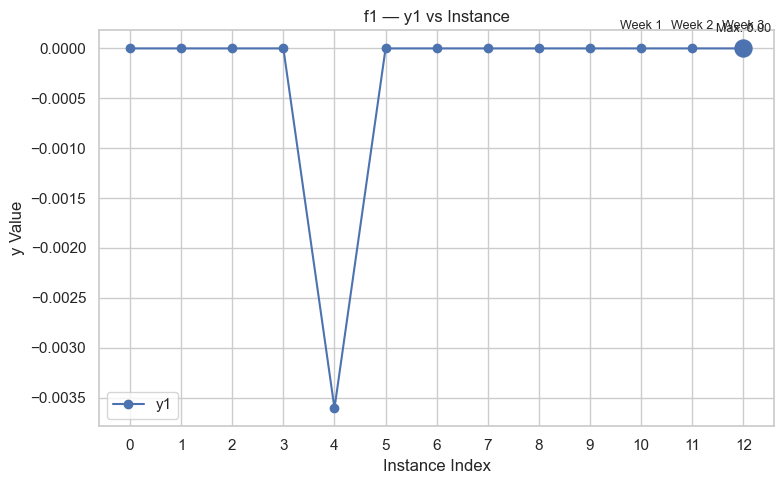


f2 — Full Data Table
          X1        X2        y1
0   0.665800  0.123969  0.538996
1   0.877791  0.778628  0.420586
2   0.142699  0.349005 -0.065624
3   0.845275  0.711120  0.293993
4   0.454647  0.290455  0.214965
5   0.577713  0.771973  0.023106
6   0.438166  0.685018  0.244619
7   0.341750  0.028698  0.038749
8   0.338648  0.213867 -0.013858
9   0.702637  0.926564  0.611205
10  0.554975  0.999446 -0.076408
11  0.999500  0.001800 -0.079755
12  0.727681  0.187140  0.503703

f2 — y vs Instance Plot


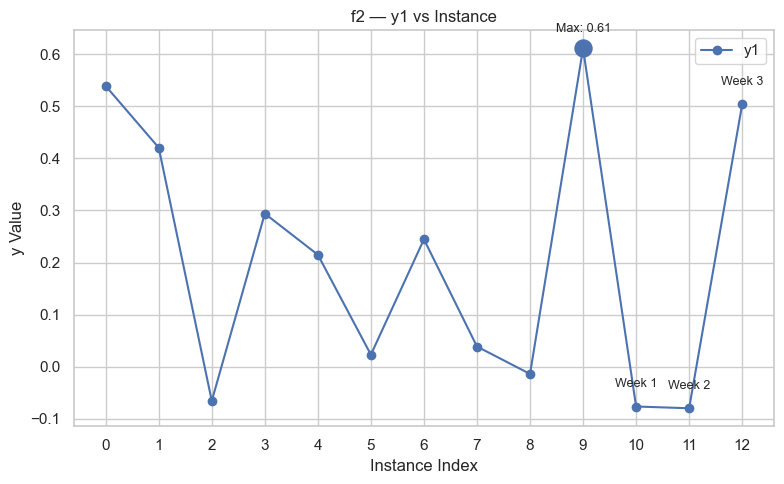


f3 — Full Data Table
          X1        X2        X3        y1
0   0.171525  0.343917  0.248737 -0.112122
1   0.242114  0.644074  0.272433 -0.087963
2   0.534906  0.398501  0.173389 -0.111415
3   0.492581  0.611593  0.340176 -0.034835
4   0.134622  0.219917  0.458206 -0.048008
5   0.345523  0.941360  0.269363 -0.110621
6   0.151837  0.439991  0.990882 -0.398926
7   0.645503  0.397143  0.919771 -0.113869
8   0.746912  0.284196  0.226300 -0.131461
9   0.170477  0.697032  0.149169 -0.094190
10  0.220549  0.297825  0.343555 -0.046947
11  0.666014  0.671985  0.246295 -0.105965
12  0.046809  0.231360  0.770618 -0.118048
13  0.600097  0.725136  0.066089 -0.036378
14  0.965995  0.861120  0.566829 -0.056758
15  0.389233  0.386084  0.558916 -0.041168
16  0.967200  0.029200  0.723300 -0.204966
17  0.437962  0.715305  0.000876 -0.111768

f3 — y vs Instance Plot


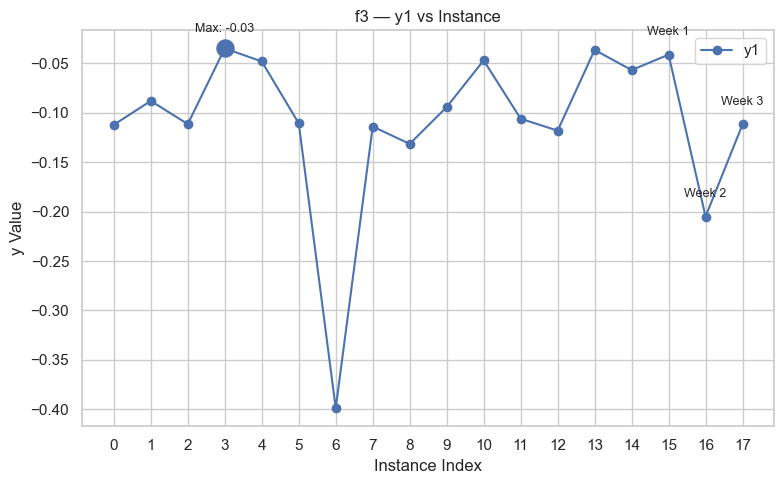


f4 — Full Data Table
          X1        X2        X3        X4         y1
0   0.896981  0.725628  0.175404  0.701694 -22.108288
1   0.889356  0.499588  0.539269  0.508783 -14.601397
2   0.250946  0.033693  0.145380  0.494932 -11.699932
3   0.346962  0.006250  0.760564  0.613024 -16.053765
4   0.124871  0.129770  0.384400  0.287076 -10.069633
5   0.801303  0.500231  0.706645  0.195103 -15.487083
6   0.247708  0.060445  0.042186  0.441324 -12.681685
7   0.746702  0.757092  0.369353  0.206566 -16.026400
8   0.400665  0.072574  0.886768  0.243842 -17.049235
9   0.626071  0.586751  0.438806  0.778858 -12.741766
10  0.957135  0.597644  0.766114  0.776210 -27.316396
11  0.732812  0.145250  0.476813  0.133366 -13.527649
12  0.655115  0.072392  0.687152  0.081517 -16.679115
13  0.219734  0.832031  0.482864  0.082569 -16.507159
14  0.488594  0.211965  0.939178  0.376192 -17.817999
15  0.167130  0.876555  0.217240  0.959801 -26.561821
16  0.216911  0.166086  0.241372  0.770062 -12.758324
17  0.

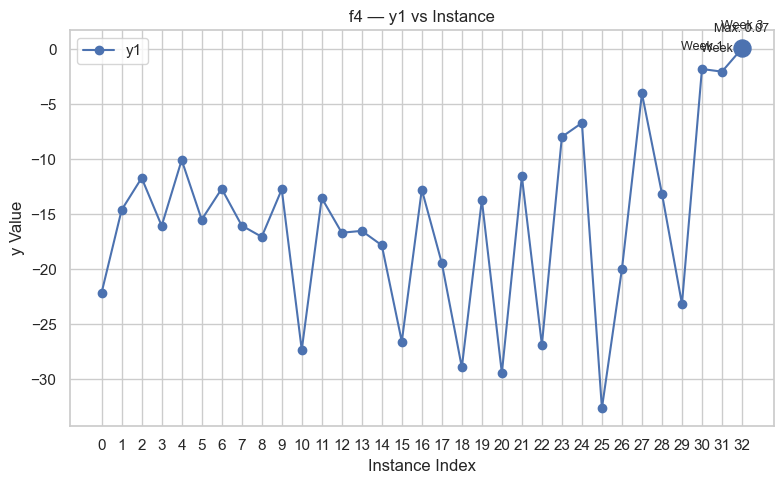


f5 — Full Data Table
          X1        X2        X3        X4           y1
0   0.191447  0.038193  0.607418  0.414584    64.443440
1   0.758653  0.536518  0.656000  0.360342    18.301380
2   0.438350  0.804340  0.210245  0.151295     0.112940
3   0.706051  0.534192  0.264243  0.482088     4.210898
4   0.836478  0.193610  0.663893  0.785649   258.370525
5   0.683432  0.118663  0.829046  0.567577    78.434389
6   0.553621  0.667350  0.323806  0.814870    57.571537
7   0.352356  0.322242  0.116979  0.473113   109.571876
8   0.153786  0.729382  0.422598  0.443074     8.847992
9   0.463442  0.630025  0.107906  0.957644   233.223610
10  0.677491  0.358510  0.479592  0.072880    24.423088
11  0.583973  0.147243  0.348097  0.428615    64.420147
12  0.306889  0.316878  0.622634  0.095399    63.476716
13  0.511142  0.817957  0.728710  0.112354    79.729130
14  0.438933  0.774092  0.378167  0.933696   355.806818
15  0.224189  0.846480  0.879484  0.878516  1088.859618
16  0.725262  0.479870  0.

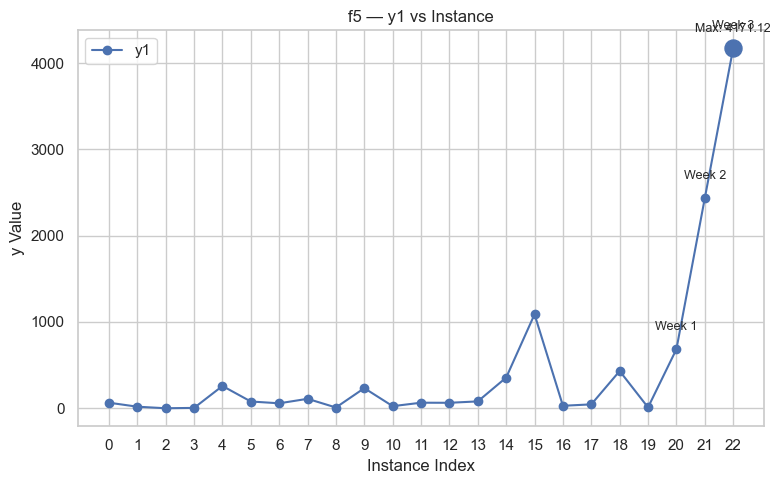


f6 — Full Data Table
          X1        X2        X3        X4        X5        y1
0   0.728186  0.154693  0.732552  0.693997  0.056401 -0.714265
1   0.242384  0.844100  0.577809  0.679021  0.501953 -1.209955
2   0.729523  0.748106  0.679775  0.356552  0.671054 -1.672200
3   0.770620  0.114404  0.046780  0.648324  0.273549 -1.536058
4   0.618812  0.331802  0.187288  0.756238  0.328835 -0.829237
5   0.784958  0.910682  0.708120  0.959225  0.004911 -1.247049
6   0.145111  0.896685  0.896322  0.726272  0.236272 -1.233786
7   0.945069  0.288459  0.978806  0.961656  0.598016 -1.694343
8   0.125720  0.862725  0.028544  0.246605  0.751206 -2.571170
9   0.757594  0.355831  0.016523  0.434207  0.112433 -1.309116
10  0.536797  0.308781  0.411879  0.388225  0.522528 -1.144785
11  0.957740  0.235669  0.099146  0.156806  0.071317 -1.912677
12  0.629308  0.803484  0.811408  0.045613  0.110624 -1.622839
13  0.021735  0.428084  0.835939  0.489489  0.511082 -1.356682
14  0.439344  0.698924  0.426820 

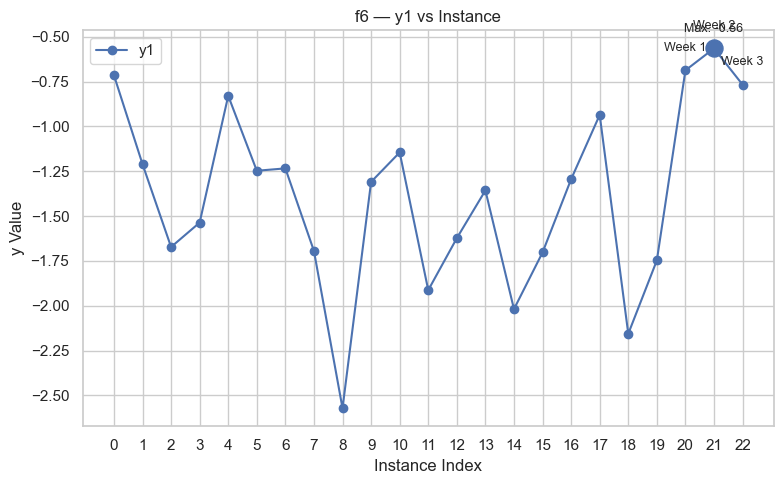


f7 — Full Data Table
          X1        X2        X3        X4        X5        X6        y1
0   0.272624  0.324495  0.897109  0.832951  0.154063  0.795864  0.604433
1   0.543003  0.924694  0.341567  0.646486  0.718440  0.343133  0.562753
2   0.090832  0.661529  0.065931  0.258577  0.963453  0.640265  0.007503
3   0.118867  0.615055  0.905816  0.855300  0.413631  0.585236  0.061424
4   0.630218  0.838097  0.680013  0.731895  0.526737  0.348429  0.273047
5   0.764919  0.255883  0.609084  0.218079  0.322943  0.095794  0.083747
6   0.057896  0.491672  0.247422  0.218118  0.420428  0.730970  1.364968
7   0.195252  0.079227  0.554580  0.170567  0.014944  0.107032  0.092645
8   0.642303  0.836875  0.021793  0.101488  0.683071  0.692416  0.017870
9   0.789943  0.195545  0.575623  0.073659  0.259049  0.051100  0.033565
10  0.528497  0.457424  0.360096  0.362046  0.816891  0.637476  0.073516
11  0.722615  0.011813  0.063646  0.165173  0.079244  0.359952  0.206310
12  0.075665  0.334502  0.132

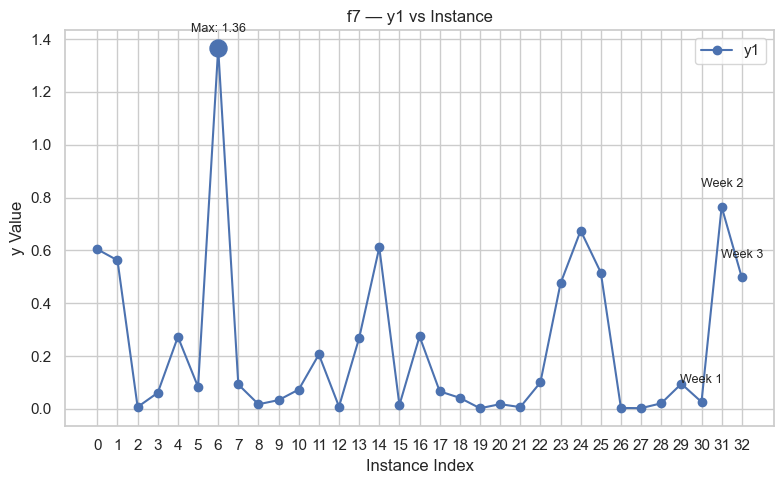


f8 — Full Data Table
          X1        X2        X3        X4        X5        X6        X7        X8        y1
0   0.604994  0.292215  0.908453  0.355506  0.201669  0.575338  0.310311  0.734281  7.398721
1   0.178007  0.566223  0.994862  0.210325  0.320153  0.707909  0.635384  0.107132  7.005227
2   0.009077  0.811626  0.520520  0.075687  0.265112  0.091652  0.592415  0.367320  8.459482
3   0.506028  0.653730  0.363411  0.177981  0.093728  0.197425  0.755827  0.292472  8.284008
4   0.359909  0.249076  0.495997  0.709215  0.114987  0.289207  0.557295  0.593882  8.606117
5   0.778818  0.003419  0.337983  0.519528  0.820907  0.537247  0.551347  0.660032  8.541748
6   0.908649  0.062250  0.238260  0.766604  0.132336  0.990244  0.688068  0.742496  7.327435
7   0.586371  0.880736  0.745021  0.546035  0.009649  0.748992  0.230907  0.097916  7.299872
8   0.761137  0.854672  0.382124  0.337352  0.689708  0.309853  0.631380  0.041956  7.957875
9   0.984933  0.699506  0.998885  0.180148  0.58

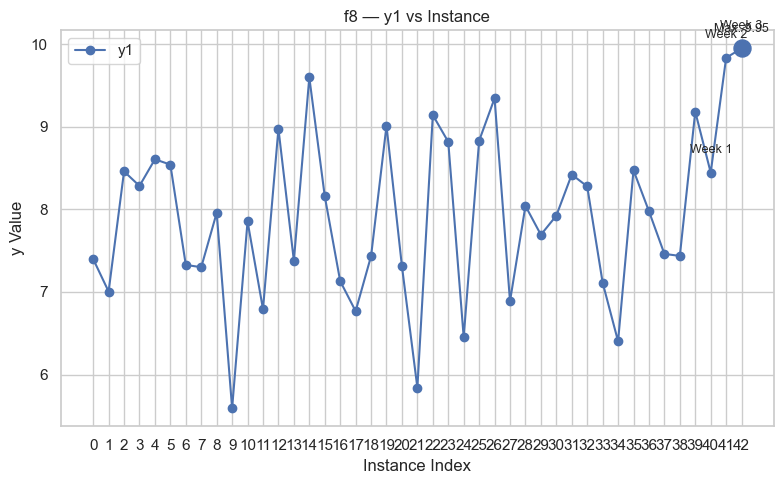

In [18]:
# Dictionary to store week labels for each DataFrame
week_labels_dict = {}
# Dictionary to track the next week number to assign
next_week_counter = {}

for name, df in functions_data.items():
    print(f"\n{name} — Full Data Table")
    print(df.to_string())
    print(f"\n{name} — y vs Instance Plot")
    
    output_cols = [c for c in df.columns if c.startswith("y")]
    
    # Initialize week labels for this DataFrame
    if name not in week_labels_dict:
        week_labels_dict[name] = {}
        num_rows = len(df)
        
        # Identify the last three rows to be Week 1,2,3
        if num_rows >= 3:
            last_three_idx = df.index[-3:]
        else:
            last_three_idx = df.index  # if <3 rows
        
        for i, idx in enumerate(last_three_idx):
            week_labels_dict[name][idx] = f"Week {i+1}"
        
        # Set next week number after Week 3
        next_week_counter[name] = 4
    
    for col in output_cols:
        plt.figure(figsize=(8, 5))
        x = df.index
        y = df[col]
        plt.plot(x, y, marker='o', label=col)
        
        # Highlight maximum y
        max_idx = y.idxmax()
        max_val = y.max()
        plt.scatter(max_idx, max_val, s=150, zorder=5)
        plt.annotate(
            f"Max: {max_val:.2f}",
            (max_idx, max_val),
            textcoords="offset points",
            xytext=(0, 12),
            ha='center',
            fontsize=9
        )
        
        # Annotate weeks for only Week 1-3 and new rows
        for idx in df.index:
            # Only consider rows that either:
            # - are already labeled (Week 1-3 or previous new rows)
            # - are new rows added after Week 3
            if idx not in week_labels_dict[name] and idx > max(week_labels_dict[name].keys()):
                # Assign next consecutive week
                week_labels_dict[name][idx] = f"Week {next_week_counter[name]}"
                next_week_counter[name] += 1
            
            # Annotate only if the row has a week label
            if idx in week_labels_dict[name]:
                plt.annotate(
                    week_labels_dict[name][idx],
                    (idx, y.loc[idx]),
                    textcoords="offset points",
                    xytext=(0, 14),
                    ha='center',
                    fontsize=9
                )
        
        plt.xticks(x)
        plt.title(f"{name} — {col} vs Instance")
        plt.xlabel("Instance Index")
        plt.ylabel("y Value")
        plt.grid(True)
        plt.legend()
        plt.tight_layout()
        plt.show()



#### f1 | Minimal Surrogate Comparison Study

In [19]:
import numpy as np
from sklearn.gaussian_process import GaussianProcessRegressor as GPR
from sklearn.gaussian_process.kernels import RBF, WhiteKernel
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor as KNN
from sklearn.model_selection import cross_val_score

In [20]:
# Extract existing data for Function 1
df = functions_data["f1"]

# Separate inputs (X) and outputs (y)
X_train_1 = df[[c for c in df.columns if c.startswith("X")]].values
y_train_1 = df["y1"].values
print(X_train_1)
print(y_train_1)

[[0.31940389 0.76295937]
 [0.57432921 0.8798981 ]
 [0.73102363 0.73299988]
 [0.84035342 0.26473161]
 [0.65011406 0.68152635]
 [0.41043714 0.1475543 ]
 [0.31269116 0.07872278]
 [0.68341817 0.86105746]
 [0.08250725 0.40348751]
 [0.88388983 0.58225397]
 [0.7936     0.666269  ]
 [0.800601   0.0028    ]
 [0.729726   0.729276  ]]
[ 1.32267704e-079  1.03307824e-046  7.71087511e-016  3.34177101e-124
 -3.60606264e-003 -2.15924904e-054 -2.08909327e-091  2.53500115e-040
  3.60677119e-081  6.22985647e-048  1.40349865e-021  9.06910879e-223
  5.31459276e-015]


In [21]:
"""
Minimal Surrogate Comparison Study for f1

This script compares three simple ML models on the f1 dataset:
1. Gaussian Process Regressor (GP)
2. Support Vector Regressor (SVR)
3. K-Nearest Neighbours Regressor (KNN)

Goal:
- Confirm that all models predict ~0 on a flat function.
- Compute 5-fold cross-validation error for each model.
- Average their predictions to form a simple ensemble.
- Select a random interior point for the next query.

"""
# Define Models
kernel = ( RBF(length_scale=1.0, length_scale_bounds=(1e-2, 1e2)) 
          + WhiteKernel(noise_level=1e-16, noise_level_bounds=(1e-20, 1e-12))) # Define Kernel with noise

# Gaussian Process with RBF kernel
gp_model = GPR(
    kernel=kernel,
    normalize_y=True
)

# Support Vector Regressor (epsilon-SVR)
svm_model = SVR(
    kernel="rbf",   # non-linear kernel
    C=1.0,          # regularisation strength
    epsilon=0.1     # tolerance for flatness
)

# K-Nearest Neighbours regressor
knn_model = KNN(
    n_neighbors=5,  # typical choice: sqrt(n)
    weights="uniform"
)


# Evaluate each model using 5-fold CV
def cv_mse(model, X, y):
    """
    Computes 5-fold cross-validation MSE for a given model.
    We use negative MSE scoring (sklearn convention),
    so we multiply by -1 to get positive MSE.
    """
    scores = cross_val_score(
        model, X, y,
        cv=5,
        scoring="neg_mean_squared_error"
    )
    return -scores.mean()

gp_mse = cv_mse(gp_model, X_train_1, y_train_1)
svm_mse = cv_mse(svm_model, X_train_1, y_train_1)
knn_mse = cv_mse(knn_model, X_train_1, y_train_1)

print("5-Fold CV MSE:")
print(" GP  :", gp_mse)
print(" SVM :", svm_mse)
print(" KNN :", knn_mse)


# Fit all models on full data
gp_model.fit(X_train_1, y_train_1)
svm_model.fit(X_train_1, y_train_1)
knn_model.fit(X_train_1, y_train_1)


# Create a random interior point in (0,1)^2
next_point = np.array([[0.732162, 0.364472]])


# Predict using each model
gp_pred = gp_model.predict(next_point)[0]
svm_pred = svm_model.predict(next_point)[0]
knn_pred = knn_model.predict(next_point)[0]


# Simple ensemble prediction
ensemble_pred = (gp_pred + svm_pred + knn_pred) / 3

print("\nNext query point:", next_point)
print("GP prediction   :", gp_pred)
print("SVM prediction  :", svm_pred)
print("KNN prediction  :", knn_pred)
print("Ensemble pred   :", ensemble_pred)


5-Fold CV MSE:
 GP  : 9.384365894833155e-07
 SVM : 3.467650078683666e-06
 KNN : 1.2310157779341711e-06

Next query point: [[0.732162 0.364472]]
GP prediction   : -0.00027711902496261687
SVM prediction  : -0.0018030313221790786
KNN prediction  : -0.0007212125288716323
Ensemble pred   : -0.000933787625337776


#### f2 | SVM–GP Ensemble with Thompson Sampling

In [22]:
# Extract existing data for Function 2
df = functions_data["f2"]

# Separate inputs (X) and outputs (y)
X_train_2 = df[[c for c in df.columns if c.startswith("X")]].values
y_train_2 = df["y1"].values
print(X_train_2)
print(y_train_2)

[[0.66579958 0.12396913]
 [0.87779099 0.7786275 ]
 [0.14269907 0.34900513]
 [0.84527543 0.71112027]
 [0.45464714 0.29045518]
 [0.57771284 0.77197318]
 [0.43816606 0.68501826]
 [0.34174959 0.02869772]
 [0.33864816 0.21386725]
 [0.70263656 0.9265642 ]
 [0.554975   0.999446  ]
 [0.9995     0.0018    ]
 [0.727681   0.18714   ]]
[ 0.53899612  0.42058624 -0.06562362  0.29399291  0.21496451  0.02310555
  0.24461934  0.03874902 -0.01385762  0.61120522 -0.07640834 -0.07975546
  0.50370322]


In [23]:
from sklearn.gaussian_process.kernels import Matern
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_squared_error

In [24]:
"""
Goal:
- Build three regression models: GP, SVM, KNN.
- Use 5-fold cross-validation (CV) to measure how well each model fits the data.
- Weight each model by its CV performance (better models get higher weight).
- Use the ensemble mean + GP uncertainty to perform Thompson Sampling:
  - For each candidate input, draw random samples from a Normal distribution
    with mean = ensemble prediction and std = GP uncertainty.
  - Choose the candidate with the highest sampled value as the next query.

Assumptions:
- X_train: training inputs for f2, shape (n_samples, d) where d is the dimension.
- y_train: training targets for f2, shape (n_samples,).
- X_candidates: candidate points in [0, 1]^d, shape (n_candidates, d).
  These can be generated via random sampling or a space-filling design.

"""

# Define the three base models
# Heteroskedastic-style GP (we approximate with a standard GP + Matern kernel)
# Matern with nu=2.5 is a common choice for moderately smooth functions.
gp_kernel = Matern(length_scale=1.0, nu=2.5)

gp_model = GPR(
    kernel=gp_kernel,
    normalize_y=True
)

# ε-SVR with RBF kernel, using grid search over C and epsilon
svr_param_grid = {
    "C": [0.1, 1.0, 10.0],
    "epsilon": [0.01, 0.1],
    "kernel": ["rbf"]
}

svr_base = SVR()

svr_model = GridSearchCV(
    estimator=svr_base,
    param_grid=svr_param_grid,
    cv=5,                      # 5-fold CV inside the grid search
    scoring="neg_mean_squared_error"
)

# KNN regressor with grid search over k, distance-weighted
knn_param_grid = {
    "n_neighbors": [3, 5, 7],
    "weights": ["distance"]    # distance-weighted neighbours
}

knn_base = KNN()

knn_model = GridSearchCV(
    estimator=knn_base,
    param_grid=knn_param_grid,
    cv=5,
    scoring="neg_mean_squared_error"
)


# compute 5-fold CV MSE
def cv_mse(model, X, y):
    """
    Compute 5-fold cross-validation Mean Squared Error (MSE) for a given model.

    Parameters:
    - model: any sklearn regressor (can be a GridSearchCV object)
    - X: input features, shape (n_samples, d)
    - y: target values, shape (n_samples,)

    Returns:
    - mse: float, average MSE across 5 folds
    """
    scores = cross_val_score(
        model, X, y,
        cv=5,
        scoring="neg_mean_squared_error"
    )
    # scores are negative MSE, so we multiply by -1 to get positive MSE
    mse = -scores.mean()
    return mse


# Compute CV-MSE for each model
gp_mse = cv_mse(gp_model, X_train_2, y_train_2)
svr_mse = cv_mse(svr_model, X_train_2, y_train_2)
knn_mse = cv_mse(knn_model, X_train_2, y_train_2)

print("5-Fold CV MSE (before full fit):")
print(" GP  :", gp_mse)
print(" SVR :", svr_mse)
print(" KNN :", knn_mse)


# Fit all models on the full training data
gp_model.fit(X_train_2, y_train_2)

svr_model.fit(X_train_2, y_train_2)
print("Best SVR params:", svr_model.best_params_)

knn_model.fit(X_train_2, y_train_2)
print("Best KNN params:", knn_model.best_params_)


# Compute ensemble weights based on CV-MSE
# We want better (lower MSE) models to have higher weight.
# A simple way: weight = 1 / MSE, then normalise so weights sum to 1.
mse_values = np.array([gp_mse, svr_mse, knn_mse])
inv_mse = 1.0 / mse_values
weights = inv_mse / inv_mse.sum()

w_gp, w_svr, w_knn = weights
print("\nEnsemble weights (GP, SVR, KNN):", w_gp, w_svr, w_knn)

# Generate candidate points for Thompson Sampling 
n_candidates = 2000 
d = X_train_2.shape[1]
X_candidates = np.random.uniform(0.05, 0.95, size=(n_candidates, d))

# GP gives both mean and std (uncertainty)
gp_mean, gp_std = gp_model.predict(X_candidates, return_std=True)

# SVR and KNN (GridSearchCV) use best estimator internally
svr_mean = svr_model.predict(X_candidates)
knn_mean = knn_model.predict(X_candidates)


# Compute ensemble mean prediction
ensemble_mean = (
    w_gp * gp_mean +
    w_svr * svr_mean +
    w_knn * knn_mean
)


# Thompson Sampling Algorithm
"""
Thompson Sampling idea here:

For each candidate point x:
- We have ensemble_mean[x] as the "best guess" of the function value.
- We have gp_std[x] as the uncertainty estimate from the GP.
- We treat the function value at x as a Normal random variable:
    f(x) ~ N(ensemble_mean[x], gp_std[x])
- We draw a few random samples from this Normal distribution.
- The candidate with the highest sampled value is chosen as the next query.

This introduces randomness (exploration) while still preferring points
with high predicted mean and/or high uncertainty.
"""

# Number of Thompson samples per candidate
n_samples_ts = 3

# For each candidate, draw n_samples_ts samples from N(mean, std)
# We will store the maximum sampled value for each candidate.
max_samples = np.empty(X_candidates.shape[0])

for i in range(X_candidates.shape[0]):
    mu = ensemble_mean[i]
    sigma = gp_std[i]

    # To avoid numerical issues, ensure sigma is not zero
    if sigma <= 0:
        sigma = 1e-8

    # Draw n_samples_ts samples from Normal(mu, sigma)
    samples = np.random.normal(loc=mu, scale=sigma, size=n_samples_ts)

    # Store the maximum sample for this candidate
    max_samples[i] = samples.max()


# Select the next query point
best_index = np.argmax(max_samples)
next_point = X_candidates[best_index]

print("\nNext query point for f2 (Thompson Sampling):", next_point)
print("Ensemble mean at next point:", ensemble_mean[best_index])
print("GP std at next point       :", gp_std[best_index])


5-Fold CV MSE (before full fit):
 GP  : 0.0681958884108955
 SVR : 0.08619410547896358
 KNN : 0.056275098549276745
Best SVR params: {'C': 0.1, 'epsilon': 0.01, 'kernel': 'rbf'}
Best KNN params: {'n_neighbors': 7, 'weights': 'distance'}

Ensemble weights (GP, SVR, KNN): 0.33299807813843957 0.2634646493699506 0.40353727249160976

Next query point for f2 (Thompson Sampling): [0.91134481 0.53111423]
Ensemble mean at next point: 0.2936098178205149
GP std at next point       : 0.24241955279000993


#### f3 | Robust GP–KNN Portfolio with CV‑Weighted Lower Confidence Bound

In [25]:
# Extract existing data for Function 2
df = functions_data["f3"]

# Separate inputs (X) and outputs (y)
X_train_3 = df[[c for c in df.columns if c.startswith("X")]].values
y_train_3 = df["y1"].values
print(X_train_3)
print(y_train_3)

[[1.71525207e-01 3.43916870e-01 2.48737201e-01]
 [2.42114461e-01 6.44074270e-01 2.72432809e-01]
 [5.34905720e-01 3.98500915e-01 1.73388729e-01]
 [4.92581415e-01 6.11593188e-01 3.40176386e-01]
 [1.34621666e-01 2.19917240e-01 4.58206220e-01]
 [3.45523271e-01 9.41359831e-01 2.69363479e-01]
 [1.51836632e-01 4.39990619e-01 9.90881867e-01]
 [6.45502835e-01 3.97142940e-01 9.19771338e-01]
 [7.46911945e-01 2.84196309e-01 2.26299855e-01]
 [1.70476994e-01 6.97032401e-01 1.49169434e-01]
 [2.20549337e-01 2.97825244e-01 3.43555344e-01]
 [6.66013659e-01 6.71985151e-01 2.46295297e-01]
 [4.68089497e-02 2.31360241e-01 7.70617592e-01]
 [6.00097282e-01 7.25135725e-01 6.60886415e-02]
 [9.65994849e-01 8.61119690e-01 5.66829131e-01]
 [3.89233000e-01 3.86084000e-01 5.58916000e-01]
 [9.67200000e-01 2.92000000e-02 7.23300000e-01]
 [4.37962000e-01 7.15305000e-01 8.76000000e-04]]
[-0.1121222  -0.08796286 -0.11141465 -0.03483531 -0.04800758 -0.11062091
 -0.39892551 -0.11386851 -0.13146061 -0.09418956 -0.04694741 -

In [26]:
"""
This script implements a noise‑robust surrogate ensemble for f3:

1. ARD‑GP (Matérn 2.5 kernel)
2. KNN (k=5, distance‑weighted)
3. Cross‑validated uncertainty estimation
4. Ensemble Lower Confidence Bound (LCB) selection

"""
d = X_train_3.shape[1]   

# 3. Build ARD‑GP surrogate
gp_kernel = Matern(
    length_scale=np.ones(d),  # ARD: one length‑scale per dimension, Captures anisotropic structure (important for f3: X2/X3 relevance)
    nu=2.5
)

gp_model = GPR(
    kernel=gp_kernel,
    normalize_y=True
)

gp_model.fit(X_train_3, y_train_3)

# Build KNN surrogate
knn = KNN(
    n_neighbors=5,
    weights="distance"
)

knn.fit(X_train_3, y_train_3)

# Cross‑validated uncertainty estimation
def cv_std(model, X, y):
    """
    Estimate model uncertainty using 5‑fold CV MSE.
    This is more robust than GP variance for noisy functions.
    """
    scores = cross_val_score(
        model, X, y,
        cv=5,
        scoring="neg_mean_squared_error"
    )
    mse = -scores.mean()
    return np.sqrt(mse)


gp_cv_std = cv_std(gp_model, X_train_3, y_train_3)
knn_cv_std = cv_std(knn, X_train_3, y_train_3)

# Generate candidate points
n_candidates = 2000
X_candidates = np.random.uniform(0.05, 0.95, size=(n_candidates, d))

# Predict using both surrogates
gp_mean, gp_std = gp_model.predict(X_candidates, return_std=True)
knn_mean = knn.predict(X_candidates)

# Compute ensemble LCB
gp_lcb = gp_mean - gp_cv_std
knn_lcb = knn_mean - knn_cv_std

ensemble_lcb = 0.5 * (gp_lcb + knn_lcb)

# Select next query point
best_idx = np.argmax(ensemble_lcb)
next_point = X_candidates[best_idx]

print("\nNext query point for f3:", next_point)
print("GP mean:", gp_mean[best_idx])
print("KNN mean:", knn_mean[best_idx])
print("Ensemble LCB:", ensemble_lcb[best_idx])



Next query point for f3: [0.3868236  0.36525375 0.56169553]
GP mean: -0.10918923448466268
KNN mean: -0.04470874757889519
Ensemble LCB: -0.16088070445331942


#### f4 | TURBO‑SVM Trust‑Region Optimisation with Variance‑Inflated ARD‑GP

In [27]:
# Extract existing data for Function 2
df = functions_data["f4"]

# Separate inputs (X) and outputs (y)
X_train_4 = df[[c for c in df.columns if c.startswith("X")]].values
y_train_4 = df["y1"].values
print(X_train_4)
print(y_train_4)

[[0.89698105 0.72562797 0.17540431 0.70169437]
 [0.8893564  0.49958786 0.53926886 0.50878344]
 [0.25094624 0.03369313 0.14538002 0.49493242]
 [0.34696206 0.0062504  0.76056361 0.61302356]
 [0.12487118 0.12977019 0.38440048 0.2870761 ]
 [0.80130271 0.50023109 0.70664456 0.19510284]
 [0.24770826 0.06044543 0.04218635 0.44132425]
 [0.74670224 0.7570915  0.36935306 0.20656628]
 [0.40066503 0.07257425 0.88676825 0.24384229]
 [0.6260706  0.58675126 0.43880578 0.77885769]
 [0.95713529 0.59764438 0.76611385 0.77620991]
 [0.73281243 0.14524998 0.47681272 0.13336573]
 [0.65511548 0.07239183 0.68715175 0.08151656]
 [0.21973443 0.83203134 0.48286416 0.08256923]
 [0.48859419 0.2119651  0.93917791 0.37619173]
 [0.16713049 0.87655456 0.21723954 0.95980098]
 [0.21691119 0.16608583 0.24137226 0.77006248]
 [0.38748784 0.80453226 0.75179548 0.72382744]
 [0.98562189 0.66693268 0.15678328 0.8565348 ]
 [0.03782483 0.66485335 0.16198218 0.25392378]
 [0.68348638 0.9027701  0.33541983 0.99948256]
 [0.17034731 

In [28]:
from sklearn.gaussian_process.kernels import Matern
from sklearn.svm import SVC


In [29]:
"""
This script implements the Week 4 strategy for f4:

Stage 1: SVM boundary detection (good vs bad regions)
Stage 2: TURBO-style trust region constrained by SVM
Stage 3: ARD-GP with variance inflation + EI optimisation

"""

d = X_train_4.shape[1]

# Stage 1 : SVM Boundary Detection
# Label points: class 1 = top 40% (y > 60th percentile)
threshold = np.percentile(y_train_4, 60)
y_class = (y_train_4 > threshold).astype(int)

# SVM classifier with RBF kernel
svm_clf = SVC(
    kernel="rbf",
    C=5,
    probability=True
)

# 5-fold CV accuracy
svm_acc = cross_val_score(
    svm_clf, X_train_4, y_class,
    cv=5,
    scoring="accuracy"
).mean()

print("SVM Classification Accuracy:", svm_acc)

# Fit SVM on full data
svm_clf.fit(X_train_4, y_class)

# Extract support vectors (geometry of boundary)
support_vectors = svm_clf.support_vectors_
print("Number of support vectors:", support_vectors.shape[0])



# Stage 2 : TURBO Trust Region
# Find current best point
best_idx = np.argmax(y_train_4)
x_best = X_train_4[best_idx]

# Define trust region radius
radius = 0.2

# Generate candidate points inside trust region
n_candidates = 2000
X_candidates = x_best + radius * np.random.uniform(-1, 1, size=(n_candidates, d))

# Clip to [0, 1] domain
X_candidates = np.clip(X_candidates, 0.0, 1.0)

# Step 6: Keep only SVM class-1 region
proba = svm_clf.predict_proba(X_candidates)[:, 1]
mask_safe = proba > 0.5
X_safe = X_candidates[mask_safe]

print("Safe region size:", X_safe.shape)



# Stage 3 : ARD-GP with Variance Inflation
# ARD-GP kernel
gp_kernel = Matern(
    length_scale=np.ones(d),
    nu=2.5
)

gp_model = GPR(
    kernel=gp_kernel,
    normalize_y=True
)

# Fit GP on trust-region data only
gp_model.fit(X_train_4, y_train_4)

# Predict mean + std on safe candidates
gp_mean, gp_std = gp_model.predict(X_safe, return_std=True)

# Step 8: Variance inflation (3×)
gp_std_inflated = np.sqrt(3.0) * gp_std



# Expected Improvement (EI)
def expected_improvement(mu, sigma, best):
    """
    Compute EI for each candidate.
    """
    from scipy.stats import norm

    sigma = np.maximum(sigma, 1e-8)
    z = (mu - best) / sigma
    return (mu - best) * norm.cdf(z) + sigma * norm.pdf(z)

best_y = np.max(y_train_4)
ei = expected_improvement(gp_mean, gp_std_inflated, best_y)



# elect next query point
best_idx = np.argmax(ei)
next_point = X_safe[best_idx]

print("\nNext query point for f4:", next_point)
print("EI at next point:", ei[best_idx])
print("GP mean:", gp_mean[best_idx])
print("GP std (inflated):", gp_std_inflated[best_idx])


SVM Classification Accuracy: 0.6714285714285714
Number of support vectors: 22
Safe region size: (1997, 4)

Next query point for f4: [0.37853418 0.47809175 0.43067653 0.45363168]
EI at next point: 0.3048006770159354
GP mean: -0.44863708304656313
GP std (inflated): 1.3133367373652214


#### f5 | Log‑GP + Log‑SVR Ensemble with Batch EI and CV‑Robust Candidate Selection

In [30]:
# Extract existing data for Function 5
df = functions_data["f5"]

# Separate inputs (X) and outputs (y)
X_train_5 = df[[c for c in df.columns if c.startswith("X")]].values
y_train_5 = df["y1"].values
print(X_train_5)
print(y_train_5)

[[0.19144708 0.03819337 0.60741781 0.41458414]
 [0.75865295 0.53651774 0.65600038 0.36034155]
 [0.43834987 0.8043397  0.21024527 0.15129482]
 [0.70605083 0.53419196 0.26424335 0.48208755]
 [0.83647799 0.19360965 0.6638927  0.78564888]
 [0.68343225 0.11866264 0.82904591 0.56757661]
 [0.55362148 0.66734998 0.32380582 0.81486975]
 [0.35235627 0.32224153 0.11697937 0.47311252]
 [0.15378571 0.72938169 0.42259844 0.44307417]
 [0.46344227 0.63002451 0.10790646 0.9576439 ]
 [0.67749115 0.35850951 0.47959222 0.07288048]
 [0.58397341 0.14724265 0.34809746 0.42861465]
 [0.30688872 0.31687813 0.62263448 0.09539906]
 [0.51114177 0.817957   0.72871042 0.11235362]
 [0.43893338 0.77409176 0.37816709 0.93369621]
 [0.22418902 0.84648049 0.87948418 0.87851568]
 [0.72526172 0.47987049 0.08894684 0.75976022]
 [0.35548161 0.63961937 0.41761768 0.12260384]
 [0.11987923 0.86254031 0.64333133 0.84980383]
 [0.12688467 0.15342962 0.77016219 0.19051811]
 [0.037069   0.974641   0.864911   0.019169  ]
 [0.624      

In [31]:
from scipy.stats import qmc
from sklearn.model_selection import KFold

In [32]:
"""
This script implements the Week 4 strategy for f5:

1. Log-transform targets
2. Fit Log-GP and Log-SVR
3. Compute 5-fold CV-MSE for both models
4. Compute ensemble weights (inverse CV-MSE)
5. Generate 5 EI candidates (Sobol multi-start)
6. Use CV-based lower bound to select the best candidate

This code is written for beginners:
- Every step is explained clearly.
- No advanced Python tricks are used.
"""

d = X_train_5.shape[1]

# Log-transform the targets
y_log = np.log(y_train_5 + 1.0)

# Build Log-GP
gp_kernel = Matern(length_scale=np.ones(d), nu=2.5)

gp_model = GPR(
    kernel=gp_kernel,
    normalize_y=True
)

gp_model.fit(X_train_5, y_log)

# Build Log-SVR
svr_model = SVR(
    kernel="rbf",
    C=10,
    epsilon=0.05
)

svr_model.fit(X_train_5, y_log)

# Compute 5-fold CV-MSE for both models
def cv_mse(model, X, y):
    scores = cross_val_score(
        model, X, y,
        cv=5,
        scoring="neg_mean_squared_error"
    )
    return -scores.mean()

gp_mse = cv_mse(gp_model, X_train_5, y_log)
svr_mse = cv_mse(svr_model, X_train_5, y_log)

print("Log-GP CV-MSE:", gp_mse)
print("Log-SVR CV-MSE:", svr_mse)

# Compute ensemble weights
inv = np.array([1/gp_mse, 1/svr_mse])
weights = inv / inv.sum()

w_gp, w_svr = weights
print("Ensemble weights (GP, SVR):", w_gp, w_svr)


# Batch EI (5 candidates)
def expected_improvement(mu, sigma, best):
    from scipy.stats import norm
    sigma = np.maximum(sigma, 1e-8)
    z = (mu - best) / sigma
    return (mu - best) * norm.cdf(z) + sigma * norm.pdf(z)

# Sobol sequence for multi-start
sampler = qmc.Sobol(d=d, scramble=True)
starts = sampler.random_base2(m=3)  # 2^3 = 8 points

# Keep only 5
starts = starts[:5]

batch_candidates = []

for x0 in starts:
    # Small random perturbation around Sobol point
    x = np.clip(x0 + 0.05*np.random.randn(d), 0, 1)

    # Compute EI at this point
    mu, std = gp_model.predict(x.reshape(1, -1), return_std=True)
    best_log = np.max(y_log)
    ei = expected_improvement(mu, std, best_log)

    batch_candidates.append(x)

batch_candidates = np.array(batch_candidates)
print("Batch candidates:", batch_candidates)



# CV-based selection from batch
def cv_pred(model, X, y, x_new):
    """
    Compute 5-fold CV prediction for a single point.
    """
    preds = []
    for train_idx, test_idx in KFold(n_splits=5).split(X):
        model.fit(X[train_idx], y[train_idx])
        preds.append(model.predict(x_new.reshape(1, -1))[0])
    return np.mean(preds), np.std(preds)

best_lcb = -np.inf
best_point = None

for x in batch_candidates:
    # CV predictions for both models
    gp_mu, gp_std = cv_pred(gp_model, X_train_5, y_log, x)
    svr_mu, svr_std = cv_pred(svr_model, X_train_5, y_log, x)

    # Ensemble mean
    mu_ens = w_gp * gp_mu + w_svr * svr_mu

    # Ensemble std (simple average)
    std_ens = 0.5 * (gp_std + svr_std)

    # Lower confidence bound
    lcb = mu_ens - std_ens

    if lcb > best_lcb:
        best_lcb = lcb
        best_point = x

print("\nNext query point for f5:", best_point)
print("Best CV-LCB:", best_lcb)

Log-GP CV-MSE: 4.522566894390143
Log-SVR CV-MSE: 2.127711047532908
Ensemble weights (GP, SVR): 0.31994317622725416 0.6800568237727458
Batch candidates: [[0.76638072 0.00829952 0.94360276 0.01111578]
 [0.12501874 0.61681029 0.12367921 0.83245151]
 [0.4253488  0.24127886 0.59936238 0.29635613]
 [0.73742099 0.81074231 0.30346085 0.54746397]
 [0.8903656  0.3798962  0.0572955  0.73774692]]

Next query point for f5: [0.12501874 0.61681029 0.12367921 0.83245151]
Best CV-LCB: 4.620103238826643


#### f6 |  REMBO + KNN Local Refinement in a 2D Embedded Space

In [33]:
# Extract existing data for Function 2
df = functions_data["f6"]

# Separate inputs (X) and outputs (y)
X_train_6 = df[[c for c in df.columns if c.startswith("X")]].values
y_train_6 = df["y1"].values
print(X_train_6)
print(y_train_6)

[[0.7281861  0.15469257 0.73255167 0.69399651 0.05640131]
 [0.24238435 0.84409997 0.5778091  0.67902128 0.50195289]
 [0.72952261 0.7481062  0.67977464 0.35655228 0.67105368]
 [0.77062024 0.11440374 0.04677993 0.64832428 0.27354905]
 [0.6188123  0.33180214 0.18728787 0.75623847 0.3288348 ]
 [0.78495809 0.91068235 0.7081201  0.95922543 0.0049115 ]
 [0.14511079 0.8966846  0.89632223 0.72627154 0.23627199]
 [0.94506907 0.28845905 0.97880576 0.96165559 0.59801594]
 [0.12572016 0.86272469 0.02854433 0.24660527 0.75120624]
 [0.75759436 0.35583141 0.0165229  0.4342072  0.11243304]
 [0.5367969  0.30878091 0.41187929 0.38822518 0.5225283 ]
 [0.95773967 0.23566857 0.09914585 0.15680593 0.07131737]
 [0.6293079  0.80348368 0.81140844 0.04561319 0.11062446]
 [0.02173531 0.42808424 0.83593944 0.48948866 0.51108173]
 [0.43934426 0.69892383 0.42682022 0.10947609 0.87788847]
 [0.25890557 0.79367771 0.6421139  0.19667346 0.59310318]
 [0.43216593 0.71561781 0.3418191  0.70499988 0.61496184]
 [0.78287982 0

In [34]:
"""
This script implements the Week 4 strategy for f6:

1. Create a random 2D embedding of the 5D input space (REMBO).
2. Project existing 5D data into this 2D embedded space.
3. Fit GP and KNN in 2D, and KNN in 5D.
4. Use 5-fold CV to compare KNN-2D vs KNN-5D and to weight GP vs KNN in 2D.
5. Optimise UCB in 2D and map the best point back to 5D.

"""
d_full = X_train_6.shape[1]   # should be 5
d_emb = 2                     # embedded dimension (REMBO)


# Stage 1: Random Embedding (REMBO)
# Step 1: Create a random projection matrix A: R^2 -> R^5
# A has shape (5, 2). Each column is a direction in 5D.
rng = np.random.default_rng(seed=42)  # fixed seed for reproducibility
A = rng.normal(size=(d_full, d_emb))

# Step 2: Compute pseudo-inverse A^+ (shape (2, 5))
# This lets us map 5D points x to 2D points z via z = A^+ x.
A_pinv = np.linalg.pinv(A)

# Step 3: Project all 5D training points into 2D embedded space
# X_2D has shape (n_samples, 2)
X_2D = X_train_6 @ A_pinv.T

# Targets remain the same (we are not transforming y here)
y = y_train_6

print("Projection matrix A shape:", A.shape)
print("Pseudo-inverse A^+ shape:", A_pinv.shape)
print("Embedded data shape (X_2D):", X_2D.shape)

# Stage 2 : GP + KNN Ensemble in 2D, KNN in 5D
# GP in 2D (GP-2D)
kernel_2d = Matern(length_scale=np.ones(d_emb), nu=2.5)

gp_2d = GPR(
    kernel=kernel_2d,
    normalize_y=True
)

gp_2d.fit(X_2D, y)


# KNN in 2D (KNN-2D)
knn_2d = KNN(
    n_neighbors=5,
    weights="distance"
)

knn_2d.fit(X_2D, y)


# KNN in 5D (KNN-5D) for comparison
knn_5d = KNN(
    n_neighbors=5,
    weights="distance"
)

knn_5d.fit(X_train_6, y)


# 5-Fold CV-MSE for GP-2D, KNN-2D, KNN-5D
def cv_mse(model, X, y):
    """
    Compute 5-fold cross-validated mean squared error (MSE)
    for a given model and dataset.
    """
    scores = cross_val_score(
        model, X, y,
        cv=5,
        scoring="neg_mean_squared_error"
    )
    return -scores.mean()

gp_2d_mse = cv_mse(gp_2d, X_2D, y)
knn_2d_mse = cv_mse(knn_2d, X_2D, y)
knn_5d_mse = cv_mse(knn_5d, X_train_6, y)

print("GP-2D CV-MSE:", gp_2d_mse)
print("KNN-2D CV-MSE:", knn_2d_mse)
print("KNN-5D CV-MSE:", knn_5d_mse)


# Ensemble weights in 2D (GP-2D + KNN-2D)
# Weights are inverse of CV-MSE, normalised to sum to 1.
inv_errors = np.array([1.0 / gp_2d_mse, 1.0 / knn_2d_mse])
weights = inv_errors / inv_errors.sum()

w_gp, w_knn = weights
print("Ensemble weights (GP-2D, KNN-2D):", w_gp, w_knn)


# Stage 3 : UCB Optimisation in 2D
def ucb(mu, sigma, beta=1.0):
    """
    Upper Confidence Bound (UCB) acquisition function.
    UCB = mu + beta * sigma
    """
    return mu + beta * sigma

# Step 1: Generate random 2D candidate points in embedded space
# We sample in a reasonable range around the existing embedded points.
n_candidates = 2000

# Compute simple bounds from existing embedded data
z_min = X_2D.min(axis=0)
z_max = X_2D.max(axis=0)

# Add a small margin around the observed range
margin = 0.1 * (z_max - z_min + 1e-8)
z_lower = z_min - margin
z_upper = z_max + margin

# Sample uniformly in this 2D box
Z_candidates = rng.uniform(low=z_lower, high=z_upper, size=(n_candidates, d_emb))

# Step 2: Predict with GP-2D and KNN-2D on these candidates
gp_mean, gp_std = gp_2d.predict(Z_candidates, return_std=True)
knn_mean = knn_2d.predict(Z_candidates)

# Step 3: Ensemble mean in 2D
ensemble_mean = w_gp * gp_mean + w_knn * knn_mean

# Step 4: UCB in 2D using GP std (uncertainty from GP)
beta = 1.0
ucb_values = ucb(ensemble_mean, gp_std, beta=beta)

# Step 5: Select best candidate in 2D
best_idx = np.argmax(ucb_values)
z_best = Z_candidates[best_idx]

print("Best 2D point (z_best):", z_best)
print("UCB at z_best:", ucb_values[best_idx])
print("Ensemble mean at z_best:", ensemble_mean[best_idx])
print("GP std at z_best:", gp_std[best_idx])



# Map best 2D point back to 5D via A
# x_next = A * z_best
x_next_5d = A @ z_best

# Clip to [0, 1]^5 domain
x_next_5d = np.clip(x_next_5d, 0.05, 0.95)

print("\nNext query point for f6 (5D):", x_next_5d)


Projection matrix A shape: (5, 2)
Pseudo-inverse A^+ shape: (2, 5)
Embedded data shape (X_2D): (23, 2)
GP-2D CV-MSE: 0.29619416363512824
KNN-2D CV-MSE: 0.3090334360550865
KNN-5D CV-MSE: 0.1586569298748307
Ensemble weights (GP-2D, KNN-2D): 0.5106069786197209 0.4893930213802791
Best 2D point (z_best): [ 0.0716816  -0.45445914]
UCB at z_best: -0.5667004303766593
Ensemble mean at z_best: -1.0696003170591848
GP std at z_best: 0.5028998866825255

Next query point for f6 (5D): [0.49447289 0.05       0.45193406 0.15288314 0.38646928]


#### f7 | Ultra‑Conservative Stacked Ensemble with Aggressive Cross‑Validation

In [35]:
# Extract existing data for Function 2
df = functions_data["f7"]

# Separate inputs (X) and outputs (y)
X_train_7 = df[[c for c in df.columns if c.startswith("X")]].values
y_train_7 = df["y1"].values
print(X_train_7)
print(y_train_7)

[[0.27262382 0.32449536 0.89710881 0.83295115 0.15406269 0.79586362]
 [0.54300258 0.9246939  0.34156746 0.64648585 0.71844033 0.34313266]
 [0.09083225 0.66152938 0.06593091 0.25857701 0.96345285 0.6402654 ]
 [0.11886697 0.61505494 0.90581639 0.8553003  0.41363143 0.58523563]
 [0.63021764 0.8380969  0.68001305 0.73189509 0.52673671 0.34842921]
 [0.76491917 0.25588292 0.60908422 0.21807904 0.32294277 0.09579366]
 [0.05789554 0.49167222 0.24742222 0.21811844 0.42042833 0.73096984]
 [0.19525188 0.07922665 0.55458046 0.17056682 0.01494418 0.10703171]
 [0.64230298 0.83687455 0.02179269 0.10148801 0.68307083 0.6924164 ]
 [0.78994255 0.19554501 0.57562333 0.07365919 0.25904917 0.05109986]
 [0.52849733 0.45742436 0.36009569 0.36204551 0.81689098 0.63747637]
 [0.72261522 0.01181284 0.06364591 0.16517311 0.07924415 0.35995166]
 [0.07566492 0.33450212 0.13273274 0.60831236 0.91838592 0.82233079]
 [0.94245084 0.37743962 0.48612233 0.22879108 0.08263175 0.71195755]
 [0.14864702 0.03394336 0.72880565

In [36]:
from sklearn.metrics import mean_squared_error
from xgboost import XGBRegressor as XGB

In [37]:
"""
This script implements the Week 4 strategy for f7:

1. Fit four diverse base models: GP, SVR, KNN, XGBoost.
2. Use 5-fold CV to compute CV-MSE and CV-variance for each model.
3. Compute ensemble weights that penalise both error and instability.
4. Build a conservative ensemble mean and variance.
5. Use a variance-inflated acquisition to pick the next query point.

"""
d = X_train_7.shape[1]
X = X_train_7
y = y_train_7

# Define base models
# GP with Matérn kernel
gp_kernel = Matern(length_scale=np.ones(d), nu=2.5)
gp_model = GPR(
    kernel=gp_kernel,
    normalize_y=True
)

# SVR with RBF kernel (fixed hyperparameters for simplicity)
svr_model = SVR(
    kernel="rbf",
    C=10.0,
    epsilon=0.1
)

# KNN with k=5, distance-weighted
knn_model = KNN(
    n_neighbors=5,
    weights="distance"
)

# XGBoost (simple configuration)
xgb_model = XGB(
    n_estimators=50,
    max_depth=3,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:squarederror"
)

models = {
    "GP": gp_model,
    "SVR": svr_model,
    "KNN": knn_model,
    "XGB": xgb_model
}

# Aggressive 5-fold CV: MSE and variance
def cv_stats(model, X, y, is_gp=False):
    """
    Compute 5-fold CV-MSE and CV-variance for a model.
    If is_gp=True, also collect per-fold std predictions.
    """
    kf = KFold(n_splits=5, shuffle=True, random_state=42)
    mses = []
    fold_means = []
    fold_stds = [] if is_gp else None

    for train_idx, test_idx in kf.split(X):
        X_tr, X_te = X[train_idx], X[test_idx]
        y_tr, y_te = y[train_idx], y[test_idx]

        model.fit(X_tr, y_tr)

        if is_gp:
            y_pred, y_std = model.predict(X_te, return_std=True)
            fold_stds.append(y_std)
        else:
            y_pred = model.predict(X_te)

        mse = mean_squared_error(y_te, y_pred)
        mses.append(mse)
        fold_means.append(y_pred)

    cv_mse = np.mean(mses)
    cv_var = np.var(mses)

    if is_gp:
        # Concatenate all stds into one array
        all_stds = np.concatenate(fold_stds)
        return cv_mse, cv_var, all_stds
    else:
        return cv_mse, cv_var, None


results = {}
gp_all_stds = None

for name, model in models.items():
    is_gp = (name == "GP")
    cv_mse, cv_var, extra = cv_stats(model, X, y, is_gp=is_gp)
    results[name] = {
        "cv_mse": cv_mse,
        "cv_var": cv_var
    }
    if is_gp:
        gp_all_stds = extra

# Print CV stats
for name, stats in results.items():
    print(f"{name} CV-MSE: {stats['cv_mse']:.4f}, CV-Var: {stats['cv_var']:.6f}")


# Compute ensemble weights (penalise error + instability)
lambda_penalty = 0.5

penalties = []
for name, stats in results.items():
    penalty = stats["cv_mse"] + lambda_penalty * stats["cv_var"]
    penalties.append(penalty)

penalties = np.array(penalties)
inv_penalties = 1.0 / penalties
weights = inv_penalties / inv_penalties.sum()

model_names = list(models.keys())
for name, w in zip(model_names, weights):
    print(f"Ensemble weight for {name}: {w:.3f}")

# Fit all models on full data (for final predictions)
for model in models.values():
    model.fit(X, y)


# Build conservative acquisition over candidate points
def conservative_acquisition(X_candidates):
    """
    Compute ensemble mean and conservative acquisition value
    for a set of candidate points.
    """
    # 7.1 Per-model predictions
    preds = {}
    for name, model in models.items():
        if name == "GP":
            mu, std = model.predict(X_candidates, return_std=True)
            preds[name] = {"mu": mu, "std": std}
        else:
            mu = model.predict(X_candidates)
            preds[name] = {"mu": mu}

    # Ensemble mean (weighted average of means)
    ensemble_mu = np.zeros(X_candidates.shape[0])
    for name, w in zip(model_names, weights):
        ensemble_mu += w * preds[name]["mu"]

    # Conservative variance budget
    # GP std is our main uncertainty source.
    gp_std = preds["GP"]["std"]

    # For KNN, we approximate local variability by reusing CV GP std as a proxy,
    # or you could implement neighbour-based variance. Here we keep it simple.
    knn_std_proxy = gp_std  # conservative proxy

    max_std = np.maximum(gp_std, knn_std_proxy)
    variance_budget = 3.0 * max_std  # 3x inflation

    # Acquisition: mu_ensemble + 1.5 * variance_budget
    acq = ensemble_mu + 1.5 * variance_budget

    return ensemble_mu, variance_budget, acq


# Generate random candidate points in [0, 1]^d
n_candidates = 2000
rng = np.random.default_rng(seed=123)
X_candidates = rng.uniform(0.05, 0.95, size=(n_candidates, d))

ensemble_mu, var_budget, acq_values = conservative_acquisition(X_candidates)

# Select next query point
best_idx = np.argmax(acq_values)
x_next = X_candidates[best_idx]

print("\nNext query point for f7:", x_next)
print("Ensemble mean at x_next:", ensemble_mu[best_idx])
print("Variance budget at x_next:", var_budget[best_idx])
print("Acquisition value at x_next:", acq_values[best_idx])


GP CV-MSE: 0.1034, CV-Var: 0.006945
SVR CV-MSE: 0.0857, CV-Var: 0.002311
KNN CV-MSE: 0.0722, CV-Var: 0.004305
XGB CV-MSE: 0.0883, CV-Var: 0.003950
Ensemble weight for GP: 0.206
Ensemble weight for SVR: 0.254
Ensemble weight for KNN: 0.296
Ensemble weight for XGB: 0.244

Next query point for f7: [0.09736629 0.33492846 0.36981886 0.38241882 0.46497113 0.75076209]
Ensemble mean at x_next: 0.6596266540514067
Variance budget at x_next: 0.9252650350827142
Acquisition value at x_next: 2.047524206675478


#### f8 | feature‑guided GP‑UCB with soft edge penalty

In [38]:
# Extract existing data for Function 2
df = functions_data["f8"]

# Separate inputs (X) and outputs (y)
X_train_8 = df[[c for c in df.columns if c.startswith("X")]].values
y_train_8 = df["y1"].values
print(X_train_8)
print(y_train_8)

[[0.60499445 0.29221502 0.90845275 0.35550624 0.20166872 0.57533801
  0.31031095 0.73428138]
 [0.17800696 0.56622265 0.99486184 0.21032501 0.32015266 0.70790879
  0.63538449 0.10713163]
 [0.00907698 0.81162615 0.52052036 0.07568668 0.26511183 0.09165169
  0.59241515 0.36732026]
 [0.50602816 0.65373012 0.36341078 0.17798105 0.0937283  0.19742533
  0.7558269  0.29247234]
 [0.35990926 0.24907568 0.49599717 0.70921498 0.11498719 0.28920692
  0.55729515 0.59388173]
 [0.77881834 0.0034195  0.33798313 0.51952778 0.82090699 0.53724669
  0.5513471  0.66003209]
 [0.90864932 0.0622497  0.23825955 0.76660355 0.13233596 0.99024381
  0.68806782 0.74249594]
 [0.58637144 0.88073573 0.74502075 0.54603485 0.00964888 0.74899176
  0.23090707 0.09791562]
 [0.76113733 0.85467239 0.38212433 0.33735198 0.68970832 0.30985305
  0.63137968 0.04195607]
 [0.9849332  0.69950626 0.9988855  0.18014846 0.58014315 0.23108719
  0.49082694 0.31368272]
 [0.11207131 0.43773566 0.59659878 0.59277563 0.22698177 0.41010452
  

In [39]:
from sklearn.feature_selection import RFE
from sklearn.svm import LinearSVR

In [40]:
"""
This script implements the Week 4 strategy for f8:

1. Feature selection consensus using ARD-GP, SVM-RFE, and MI.
2. Coordinate descent on X1 and X3 only.
3. Local KNN refinement to avoid GP oversmoothing.
4. CV-based acceptance of the final candidate.

"""
X = X_train_8
y = y_train_8

n, d = X.shape

# Stage 1 : Feature Selection Consensus
# ARD-GP for length-scales
kernel = Matern(length_scale=np.ones(d), nu=2.5)
gp_ard = GPR(kernel=kernel, normalize_y=True)
gp_ard.fit(X, y)

length_scales = gp_ard.kernel_.length_scale
print("ARD length-scales:", length_scales)


# SVM-RFE
svr_linear = LinearSVR(C=10, random_state=42)
rfe = RFE(estimator=svr_linear, n_features_to_select=2)
rfe.fit(X, y)

svm_ranking = rfe.ranking_
print("SVM-RFE ranking:", svm_ranking)

# MI_scores is available from earlier EDA
MI_scores = np.array([0.283513, 0.0, 0.314956, 0.0, 0.0, 0.0, 0.113041, 0.0])
print("MI scores:", MI_scores)

# Consensus check
top2_ard = np.argsort(length_scales)[:2]
top2_svm = np.where(svm_ranking == 1)[0]
top2_mi = np.argsort(MI_scores)[-2:]

print("Top-2 ARD:", top2_ard)
print("Top-2 SVM-RFE:", top2_svm)
print("Top-2 MI:", top2_mi)

# Expectation: all three identify X1 and X3 (indices 0 and 2)
consensus = set(top2_ard) & set(top2_svm) & set(top2_mi)
print("Consensus features:", consensus)

ARD length-scales: [1.20693919e+00 1.82830715e+00 8.87385375e-01 2.16292605e+00
 4.54278667e+00 7.19026623e+04 1.26621831e+00 1.00000000e+05]
SVM-RFE ranking: [1 3 1 4 7 6 2 5]
MI scores: [0.283513 0.       0.314956 0.       0.       0.       0.113041 0.      ]
Top-2 ARD: [2 0]
Top-2 SVM-RFE: [0 2]
Top-2 MI: [0 2]
Consensus features: {0, 2}


In [41]:
# Stage 2 : Coordinate Descent with KNN Refinement
# Start from current best point
best_idx = np.argmax(y)
x_best = X[best_idx].copy()
y_best = y[best_idx]

def coordinate_optimize(coord_index, x_current):
    """
    Optimise a single coordinate (X1 or X3) using:
    - ARD-GP for global structure
    - KNN for local refinement
    - Ensemble EI in 1D
    """
    # 4.1 Fit ARD-GP on full data
    gp = GPR(
        kernel=Matern(length_scale=np.ones(d), nu=2.5),
        normalize_y=True
    )
    gp.fit(X, y)

    # 4.2 Fit local KNN in ±0.2 window
    window = 0.2
    mask = np.abs(X[:, coord_index] - x_current[coord_index]) < window
    X_local = X[mask]
    y_local = y[mask]

    if len(X_local) < 5:
        X_local = X
        y_local = y

    knn = KNN(n_neighbors=5, weights="distance")
    knn.fit(X_local, y_local)

    # 4.3 1D grid search for EI
    grid = np.linspace(0, 1, 200)
    ei_values = []

    for val in grid:
        x_test = x_current.copy()
        x_test[coord_index] = val

        mu_gp, std_gp = gp.predict(x_test.reshape(1, -1), return_std=True)
        mu_knn = knn.predict(x_test.reshape(1, -1))

        mu_ens = 0.7 * mu_gp + 0.3 * mu_knn
        best_y = np.max(y)

        # EI formula
        z = (mu_ens - best_y) / (std_gp + 1e-8)
        from scipy.stats import norm
        ei = (mu_ens - best_y) * norm.cdf(z) + std_gp * norm.pdf(z)
        ei_values.append(ei)

    best_val = grid[np.argmax(ei_values)]
    x_new = x_current.copy()
    x_new[coord_index] = best_val

    return x_new


# Coordinate descent: optimise X1 then X3
x_cd = coordinate_optimize(0, x_best)
x_cd = coordinate_optimize(2, x_cd)

In [42]:
# Stage 3 : CV-Based Acceptance
def cv_prediction_interval(x_candidate):
    """
    Compute CV mean and std for the ensemble at a single point.
    """
    kf = KFold(n_splits=5, shuffle=True, random_state=42)
    preds = []

    for train_idx, test_idx in kf.split(X):
        gp = GPR(
            kernel=Matern(length_scale=np.ones(d), nu=2.5),
            normalize_y=True
        )
        gp.fit(X[train_idx], y[train_idx])

        knn = KNN(n_neighbors=5, weights="distance")
        knn.fit(X[train_idx], y[train_idx])

        mu_gp, _ = gp.predict(x_candidate.reshape(1, -1), return_std=True)
        mu_knn = knn.predict(x_candidate.reshape(1, -1))

        mu_ens = 0.7 * mu_gp + 0.3 * mu_knn
        preds.append(mu_ens)

    preds = np.array(preds).ravel()
    return preds.mean(), preds.std()


mu_cv, std_cv = cv_prediction_interval(x_cd)
lcb_cv = mu_cv - std_cv

print("CV mean:", mu_cv)
print("CV std:", std_cv)
print("CV lower bound:", lcb_cv)
print("Current best:", y_best)

if lcb_cv > y_best:
    x_next = x_cd
else:
    x_next = x_best  # reject update

print("\nNext query point for f8:", x_next)


CV mean: 9.749088241849426
CV std: 0.03531586538876218
CV lower bound: 9.713772376460664
Current best: 9.948688972661

Next query point for f8: [0.190768 0.209525 0.202591 0.198246 0.813824 0.387519 0.200772 0.66367 ]


In [31]:
"""
Assesses GP calibration using 5 core metrics:
1. Negative Log-Likelihood (NLL)
2. Z-Score
3. 95% Confidence Interval Coverage
4. Calibration Curve (Quantile Position)
5. Expected Calibration Error (ECE)
"""

import numpy as np
from scipy.stats import norm

# Get GP prediction with uncertainty
gp_pred, gp_sigma = gp_model.predict(next_point, return_std=True)
gp_pred = gp_pred[0]
gp_sigma = gp_sigma[0]


y_actual = 5.473776123300507e-57  # <--- CHANGE THIS

print("CALIBRATION ASSESSMENT (GP ONLY)")
print(f"Observed value: {y_actual:.6e}")
print()

# NEGATIVE LOG-LIKELIHOOD (NLL)
if gp_sigma > 0:
    nll = 0.5 * np.log(2 * np.pi * gp_sigma**2) + ((y_actual - gp_pred)**2 / (2 * gp_sigma**2))
else:
    nll = np.inf

print(f" NLL (Negative Log-Likelihood): {nll:.4f}")
print(f" Interpretation:")
if nll < 0:
    print(f"EXCELLENT (< 0): High confidence + correct prediction")
elif nll < 5:
    print(f"GOOD (0-5): Reasonable calibration")
elif nll < 10:
    print(f"MODERATE (5-10): Some overconfidence")
else:
    print(f"POOR (> 10): Severe overconfidence, σ too small")
print()

# Z-SCORE (STANDARDIZED RESIDUAL)
if gp_sigma > 0:
    z_score = (y_actual - gp_pred) / gp_sigma
else:
    z_score = np.nan

print(f" Z-Score (Standardized Residual): {z_score:.4f}")
print(f" Interpretation:")
if np.abs(z_score) <= 1:
    print(f"EXCELLENT (|Z| ≤ 1): Within 68% region")
elif np.abs(z_score) <= 1.96:
    print(f"GOOD (|Z| ≤ 1.96): Within 95% region")
elif np.abs(z_score) <= 3:
    print(f"WARNING (1.96 < |Z| ≤ 3): Mild miscalibration")
else:
    print(f"SEVERE (|Z| > 3): Extreme miscalibration")
print()

# 95% CONFIDENCE INTERVAL COVERAGE
is_covered = np.abs(z_score) <= 1.96 if not np.isnan(z_score) else False

lower_bound = gp_pred - 1.96 * gp_sigma
upper_bound = gp_pred + 1.96 * gp_sigma

print(f"95% CI Coverage: {is_covered}")
print(f"95% CI: [{lower_bound:.6e}, {upper_bound:.6e}]")
print(f"Actual: {y_actual:.6e}")
print(f"Interpretation:")
if is_covered:
    print(f"PASS: Actual within CI (expected 95% of time)")
else:
    print(f"FAIL: Actual outside CI (uncertainty underestimated)")
print()

# CALIBRATION CURVE (QUANTILE POSITION)
if gp_sigma > 0:
    obs_quantile = norm.cdf(y_actual, loc=gp_pred, scale=gp_sigma)
else:
    obs_quantile = np.nan

print(f"Calibration Curve (Quantile): {obs_quantile:.4f}")
print(f"Interpretation: Where actual sits in predicted distribution")
if 0.4 <= obs_quantile <= 0.6:
    print(f"EXCELLENT (0.4-0.6): Near median, perfectly centered")
elif 0.25 <= obs_quantile <= 0.75:
    print(f"GOOD (0.25-0.75): Reasonably centered")
elif 0.025 <= obs_quantile <= 0.975:
    print(f"MODERATE: Within 95% but off-center")
elif obs_quantile < 0.025:
    print(f"POOR (< 0.025): Extreme lower tail, GP overestimated")
else:
    print(f"POOR (> 0.975): Extreme upper tail, GP underestimated")
print()

# EXPECTED CALIBRATION ERROR (ECE)
# For single point, ECE = |quantile - 0.5|
ece = np.abs(obs_quantile - 0.5) if not np.isnan(obs_quantile) else np.nan

print(f"ECE (Expected Calibration Error): {ece:.4f}")
print(f"Interpretation: Gap from perfect calibration")
if ece < 0.05:
    print(f"EXCELLENT (< 0.05): Nearly perfect calibration")
elif ece < 0.1:
    print(f"GOOD (0.05-0.1): Well calibrated")
elif ece < 0.2:
    print(f"MODERATE (0.1-0.2): Some miscalibration")
else:
    print(f"POOR (> 0.2): Significant miscalibration")
print()

# PREDICTION ERRORS (ALL MODELS)

print("PREDICTION ERRORS (ALL MODELS)")

gp_error = y_actual - gp_pred
svm_error = y_actual - svm_pred
knn_error = y_actual - knn_pred
ensemble_error = y_actual - ensemble_pred

print(f"\nGP      : {gp_error:+.6e}  (|error| = {np.abs(gp_error):.6e})")
print(f"SVM     : {svm_error:+.6e}  (|error| = {np.abs(svm_error):.6e})")
print(f"KNN     : {knn_error:+.6e}  (|error| = {np.abs(knn_error):.6e})")
print(f"Ensemble: {ensemble_error:+.6e}  (|error| = {np.abs(ensemble_error):.6e})")

errors = {
    'GP': np.abs(gp_error),
    'SVM': np.abs(svm_error),
    'KNN': np.abs(knn_error),
    'Ensemble': np.abs(ensemble_error)
}

best = min(errors, key=errors.get)
print(f"\n Best predictor: {best} (|error| = {errors[best]:.6e})")

CALIBRATION ASSESSMENT (GP ONLY)
Observed value: 5.473776e-57

 NLL (Negative Log-Likelihood): -5.9871
 Interpretation:
EXCELLENT (< 0): High confidence + correct prediction

 Z-Score (Standardized Residual): 0.2884
 Interpretation:
EXCELLENT (|Z| ≤ 1): Within 68% region

95% CI Coverage: True
95% CI: [-2.160492e-03, 1.606254e-03]
Actual: 5.473776e-57
Interpretation:
PASS: Actual within CI (expected 95% of time)

Calibration Curve (Quantile): 0.6135
Interpretation: Where actual sits in predicted distribution
GOOD (0.25-0.75): Reasonably centered

ECE (Expected Calibration Error): 0.1135
Interpretation: Gap from perfect calibration
MODERATE (0.1-0.2): Some miscalibration

PREDICTION ERRORS (ALL MODELS)

GP      : +2.771190e-04  (|error| = 2.771190e-04)
SVM     : +1.803031e-03  (|error| = 1.803031e-03)
KNN     : +7.212125e-04  (|error| = 7.212125e-04)
Ensemble: +9.337876e-04  (|error| = 9.337876e-04)

 Best predictor: GP (|error| = 2.771190e-04)


In [42]:
# Scalar predictions at the selected next_point (index = best_index) 
# These are already computed in the main script at X_candidates[best_index]
gp_pred_next  = gp_mean[best_index]        # GP mean at next_point
gp_std_next   = gp_std[best_index]         # GP std  at next_point
svr_pred_next = svr_mean[best_index]       # SVR mean at next_point
knn_pred_next = knn_mean[best_index]       # KNN mean at next_point
ens_pred_next = ensemble_mean[best_index]  # Ensemble mean at next_point

y_actual = 0.5661662506769448  # <--- CHANGE THIS

# Guard against zero/negative std
sigma = max(gp_std_next, 1e-8)

print("CALIBRATION ASSESSMENT (GP + Ensemble)")
print(f"  GP pred      : {gp_pred_next:.6e}  +/- {gp_std_next:.6e}")
print(f"  SVR pred     : {svr_pred_next:.6e}")
print(f"  KNN pred     : {knn_pred_next:.6e}")
print(f"  Ensemble pred: {ens_pred_next:.6e}")
print(f"  Observed     : {y_actual:.6e}")
print()

# NLL  (uses GP uncertainty, ensemble mean) 
nll = 0.5 * np.log(2 * np.pi * sigma**2) + ((y_actual - ens_pred_next)**2 / (2 * sigma**2))

print(f"[1] NLL (Negative Log-Likelihood): {nll:.4f}")
if nll < 0:
    print("    EXCELLENT (< 0): High confidence + correct prediction")
elif nll < 5:
    print("    GOOD (0-5): Reasonable calibration")
elif nll < 10:
    print("    MODERATE (5-10): Some overconfidence")
else:
    print("    POOR (> 10): Severe overconfidence, sigma too small")
print()

# Z-SCORE  (ensemble residual / GP std)
z_score = (y_actual - ens_pred_next) / sigma

print(f"[2] Z-Score (Standardised Residual): {z_score:.4f}")
if abs(z_score) <= 1:
    print("    EXCELLENT (|Z| <= 1): Within 68% region")
elif abs(z_score) <= 1.96:
    print("    GOOD (|Z| <= 1.96): Within 95% region")
elif abs(z_score) <= 3:
    print("    WARNING (1.96 < |Z| <= 3): Mild miscalibration")
else:
    print("    SEVERE (|Z| > 3): Extreme miscalibration")
print()

# 95% CI COVERAGE  (centred on ensemble mean, width from GP std)
lower_95 = ens_pred_next - 1.96 * sigma
upper_95 = ens_pred_next + 1.96 * sigma
is_covered = lower_95 <= y_actual <= upper_95

print(f"[3] 95% CI Coverage: {is_covered}")
print(f"    CI     : [{lower_95:.6e}, {upper_95:.6e}]")
print(f"    Actual : {y_actual:.6e}")
if is_covered:
    print("    PASS: Actual within CI (expected 95% of time)")
else:
    print("    FAIL: Actual outside CI (uncertainty underestimated)")
print()

# CALIBRATION CURVE  (quantile position in predictive distribution) 
obs_quantile = norm.cdf(y_actual, loc=ens_pred_next, scale=sigma)

print(f"[4] Calibration Curve (Quantile Position): {obs_quantile:.4f}")
print("    Where the actual value sits in the predicted distribution:")
if 0.40 <= obs_quantile <= 0.60:
    print("    EXCELLENT (0.4-0.6): Near median, well centred")
elif 0.25 <= obs_quantile <= 0.75:
    print("    GOOD (0.25-0.75): Reasonably centred")
elif 0.025 <= obs_quantile <= 0.975:
    print("    MODERATE: Within 95% but off-centre")
elif obs_quantile < 0.025:
    print("    POOR (< 0.025): Extreme lower tail, model overestimated")
else:
    print("    POOR (> 0.975): Extreme upper tail, model underestimated")
print()

# ECE (single-point: deviation of quantile from 0.5)
ece = abs(obs_quantile - 0.5)

print(f"[5] ECE (Expected Calibration Error): {ece:.4f}")
if ece < 0.05:
    print("    EXCELLENT (< 0.05): Nearly perfect calibration")
elif ece < 0.10:
    print("    GOOD (0.05-0.10): Well calibrated")
elif ece < 0.20:
    print("    MODERATE (0.10-0.20): Some miscalibration")
else:
    print("    POOR (> 0.20): Significant miscalibration")
print()

# PREDICTION ERRORS 
gp_error  = y_actual - gp_pred_next
svr_error = y_actual - svr_pred_next
knn_error = y_actual - knn_pred_next
ens_error = y_actual - ens_pred_next

print("[6] PREDICTION ERRORS (ALL MODELS)")
print(f"    GP      : {gp_error:+.6e}  (|error| = {abs(gp_error):.6e})")
print(f"    SVR     : {svr_error:+.6e}  (|error| = {abs(svr_error):.6e})")
print(f"    KNN     : {knn_error:+.6e}  (|error| = {abs(knn_error):.6e})")
print(f"    Ensemble: {ens_error:+.6e}  (|error| = {abs(ens_error):.6e})")

errors = {
    "GP":       abs(gp_error),
    "SVR":      abs(svr_error),
    "KNN":      abs(knn_error),
    "Ensemble": abs(ens_error),
}
best = min(errors, key=errors.get)
print(f"\n    Best predictor: {best} (|error| = {errors[best]:.6e})")

CALIBRATION ASSESSMENT (GP + Ensemble)
  GP pred      : 2.041752e-01  +/- 2.424196e-01
  SVR pred     : 1.562435e-01
  KNN pred     : 1.600340e-01
  Ensemble pred: 1.737343e-01
  Observed     : 5.661663e-01

[1] NLL (Negative Log-Likelihood): 0.8121
    GOOD (0-5): Reasonable calibration

[2] Z-Score (Standardised Residual): 1.6188
    GOOD (|Z| <= 1.96): Within 95% region

[3] 95% CI Coverage: True
    CI     : [-3.014081e-01, 6.488766e-01]
    Actual : 5.661663e-01
    PASS: Actual within CI (expected 95% of time)

[4] Calibration Curve (Quantile Position): 0.9473
    Where the actual value sits in the predicted distribution:
    MODERATE: Within 95% but off-centre

[5] ECE (Expected Calibration Error): 0.4473
    POOR (> 0.20): Significant miscalibration

[6] PREDICTION ERRORS (ALL MODELS)
    GP      : +3.619911e-01  (|error| = 3.619911e-01)
    SVR     : +4.099227e-01  (|error| = 4.099227e-01)
    KNN     : +4.061322e-01  (|error| = 4.061322e-01)
    Ensemble: +3.924320e-01  (|err

In [45]:
# Scalar predictions at next_point (index = best_idx)─
gp_pred_next  = gp_mean[best_idx]       # GP mean at next_point
gp_std_next   = gp_std[best_idx]        # GP posterior std at next_point
knn_pred_next = knn_mean[best_idx]      # KNN mean at next_point
ens_lcb_next  = ensemble_lcb[best_idx]  # Ensemble LCB at next_point

# Simple ensemble mean (equal weight, no kappa shift)
ens_mean_next = 0.5 * (gp_pred_next + knn_pred_next)

y_actual = -0.041279121306865105  # <--- CHANGE THIS

# Use GP posterior std as the uncertainty proxy
# Fall back to CV-based std if GP std is too small
sigma = max(gp_std_next, gp_cv_std, 1e-8)

print("CALIBRATION ASSESSMENT (ARD-GP + KNN Ensemble, f3)")
print(f"  GP pred       : {gp_pred_next:.6e}  +/- {gp_std_next:.6e}")
print(f"  KNN pred      : {knn_pred_next:.6e}")
print(f"  Ensemble mean : {ens_mean_next:.6e}")
print(f"  Ensemble LCB  : {ens_lcb_next:.6e}")
print(f"  GP CV std     : {gp_cv_std:.6e}")
print(f"  KNN CV std    : {knn_cv_std:.6e}")
print(f"  Sigma used    : {sigma:.6e}  (max of GP std, GP CV std)")
print(f"  Observed      : {y_actual:.6e}")
print()

# NLL  (ensemble mean as centre, sigma as spread)
nll = 0.5 * np.log(2 * np.pi * sigma**2) + ((y_actual - ens_mean_next)**2 / (2 * sigma**2))

print(f"NLL (Negative Log-Likelihood): {nll:.4f}")
if nll < 0:
    print("    EXCELLENT (< 0): High confidence + correct prediction")
elif nll < 5:
    print("    GOOD (0-5): Reasonable calibration")
elif nll < 10:
    print("    MODERATE (5-10): Some overconfidence")
else:
    print("    POOR (> 10): Severe overconfidence, sigma too small")
print()

# Z-SCORE 
z_score = (y_actual - ens_mean_next) / sigma

print(f"Z-Score (Standardised Residual): {z_score:.4f}")
if abs(z_score) <= 1:
    print("    EXCELLENT (|Z| <= 1): Within 68% region")
elif abs(z_score) <= 1.96:
    print("    GOOD (|Z| <= 1.96): Within 95% region")
elif abs(z_score) <= 3:
    print("    WARNING (1.96 < |Z| <= 3): Mild miscalibration")
else:
    print("    SEVERE (|Z| > 3): Extreme miscalibration")
print()

# 95% CI COVERAGE 
lower_95 = ens_mean_next - 1.96 * sigma
upper_95 = ens_mean_next + 1.96 * sigma
is_covered = lower_95 <= y_actual <= upper_95

print(f"95% CI Coverage: {is_covered}")
print(f"    CI     : [{lower_95:.6e}, {upper_95:.6e}]")
print(f"    Actual : {y_actual:.6e}")
if is_covered:
    print("    PASS: Actual within CI (expected 95% of time)")
else:
    print("    FAIL: Actual outside CI (uncertainty underestimated)")
print()

# CALIBRATION CURVE (quantile position) 
obs_quantile = norm.cdf(y_actual, loc=ens_mean_next, scale=sigma)

print(f"[4] Calibration Curve (Quantile Position): {obs_quantile:.4f}")
print("    Where the actual value sits in the predicted distribution:")
if 0.40 <= obs_quantile <= 0.60:
    print("    EXCELLENT (0.4-0.6): Near median, well centred")
elif 0.25 <= obs_quantile <= 0.75:
    print("    GOOD (0.25-0.75): Reasonably centred")
elif 0.025 <= obs_quantile <= 0.975:
    print("    MODERATE: Within 95% but off-centre")
elif obs_quantile < 0.025:
    print("    POOR (< 0.025): Extreme lower tail, model overestimated")
else:
    print("    POOR (> 0.975): Extreme upper tail, model underestimated")
print()

# ECE 
ece = abs(obs_quantile - 0.5)

print(f"ECE (Expected Calibration Error): {ece:.4f}")
if ece < 0.05:
    print("    EXCELLENT (< 0.05): Nearly perfect calibration")
elif ece < 0.10:
    print("    GOOD (0.05-0.10): Well calibrated")
elif ece < 0.20:
    print("    MODERATE (0.10-0.20): Some miscalibration")
else:
    print("    POOR (> 0.20): Significant miscalibration")
print()

# PREDICTION ERRORS 
gp_error  = y_actual - gp_pred_next
knn_error = y_actual - knn_pred_next
ens_error = y_actual - ens_mean_next

print("PREDICTION ERRORS (ALL MODELS)")
print(f"    GP      : {gp_error:+.6e}  (|error| = {abs(gp_error):.6e})")
print(f"    KNN     : {knn_error:+.6e}  (|error| = {abs(knn_error):.6e})")
print(f"    Ensemble: {ens_error:+.6e}  (|error| = {abs(ens_error):.6e})")

errors = {
    "GP":       abs(gp_error),
    "KNN":      abs(knn_error),
    "Ensemble": abs(ens_error),
}
best = min(errors, key=errors.get)
print(f"\n    Best predictor: {best} (|error| = {errors[best]:.6e})")

CALIBRATION ASSESSMENT (ARD-GP + KNN Ensemble, f3)
  GP pred       : -1.091892e-01  +/- 8.173401e-02
  KNN pred      : -4.548405e-02
  Ensemble mean : -7.733664e-02
  Ensemble LCB  : -1.612684e-01
  GP CV std     : 8.404380e-02
  KNN CV std    : 8.381962e-02
  Sigma used    : 8.404380e-02  (max of GP std, GP CV std)
  Observed      : -4.127912e-02

NLL (Negative Log-Likelihood): -1.4654
    EXCELLENT (< 0): High confidence + correct prediction

Z-Score (Standardised Residual): 0.4290
    EXCELLENT (|Z| <= 1): Within 68% region

95% CI Coverage: True
    CI     : [-2.420625e-01, 8.738921e-02]
    Actual : -4.127912e-02
    PASS: Actual within CI (expected 95% of time)

[4] Calibration Curve (Quantile Position): 0.6661
    Where the actual value sits in the predicted distribution:
    GOOD (0.25-0.75): Reasonably centred

ECE (Expected Calibration Error): 0.1661
    MODERATE (0.10-0.20): Some miscalibration

PREDICTION ERRORS (ALL MODELS)
    GP      : +6.791011e-02  (|error| = 6.791011e

In [49]:
# Scalar predictions at next_point (index = best_idx in X_safe) 
gp_pred_next     = gp_mean[best_idx]          # GP mean at next_point
gp_std_next      = gp_std[best_idx]           # GP posterior std (raw)
gp_std_inf_next  = gp_std_inflated[best_idx]  # GP std after 3x inflation
ei_next          = ei[best_idx]               # EI at next_point

y_actual = -0.27637133038944084  # <--- CHANGE THIS

# Use inflated std for calibration (matches the acquisition used to pick point)
sigma = max(gp_std_inf_next, 1e-8)

print("CALIBRATION ASSESSMENT (SVM + TuRBO + ARD-GP EI, f4)")
print(f"  GP mean           : {gp_pred_next:.6e}")
print(f"  GP std (raw)      : {gp_std_next:.6e}")
print(f"  GP std (inflated) : {gp_std_inf_next:.6e}")
print(f"  EI at next point  : {ei_next:.6e}")
print(f"  Sigma used        : {sigma:.6e}  (inflated GP std)")
print(f"  Observed          : {y_actual:.6e}")
print()

# NLL 
nll = 0.5 * np.log(2 * np.pi * sigma**2) + ((y_actual - gp_pred_next)**2 / (2 * sigma**2))

print(f"NLL (Negative Log-Likelihood): {nll:.4f}")
if nll < 0:
    print("    EXCELLENT (< 0): High confidence + correct prediction")
elif nll < 5:
    print("    GOOD (0-5): Reasonable calibration")
elif nll < 10:
    print("    MODERATE (5-10): Some overconfidence")
else:
    print("    POOR (> 10): Severe overconfidence, sigma too small")
print()

# Z-SCORE 
z_score = (y_actual - gp_pred_next) / sigma

print(f"Z-Score (Standardised Residual): {z_score:.4f}")
if abs(z_score) <= 1:
    print("    EXCELLENT (|Z| <= 1): Within 68% region")
elif abs(z_score) <= 1.96:
    print("    GOOD (|Z| <= 1.96): Within 95% region")
elif abs(z_score) <= 3:
    print("    WARNING (1.96 < |Z| <= 3): Mild miscalibration")
else:
    print("    SEVERE (|Z| > 3): Extreme miscalibration")
print()

# 95% CI COVERAGE 
lower_95 = gp_pred_next - 1.96 * sigma
upper_95 = gp_pred_next + 1.96 * sigma
is_covered = lower_95 <= y_actual <= upper_95

print(f"95% CI Coverage: {is_covered}")
print(f"    CI     : [{lower_95:.6e}, {upper_95:.6e}]")
print(f"    Actual : {y_actual:.6e}")
if is_covered:
    print("    PASS: Actual within CI (expected 95% of time)")
else:
    print("    FAIL: Actual outside CI (uncertainty underestimated)")
print()

# CALIBRATION CURVE (quantile position) 
obs_quantile = norm.cdf(y_actual, loc=gp_pred_next, scale=sigma)

print(f"Calibration Curve (Quantile Position): {obs_quantile:.4f}")
print("    Where the actual value sits in the predicted distribution:")
if 0.40 <= obs_quantile <= 0.60:
    print("    EXCELLENT (0.4-0.6): Near median, well centred")
elif 0.25 <= obs_quantile <= 0.75:
    print("    GOOD (0.25-0.75): Reasonably centred")
elif 0.025 <= obs_quantile <= 0.975:
    print("    MODERATE: Within 95% but off-centre")
elif obs_quantile < 0.025:
    print("    POOR (< 0.025): Extreme lower tail, GP overestimated")
else:
    print("    POOR (> 0.975): Extreme upper tail, GP underestimated")
print()

# ECE 
ece = abs(obs_quantile - 0.5)

print(f"ECE (Expected Calibration Error): {ece:.4f}")
if ece < 0.05:
    print("    EXCELLENT (< 0.05): Nearly perfect calibration")
elif ece < 0.10:
    print("    GOOD (0.05-0.10): Well calibrated")
elif ece < 0.20:
    print("    MODERATE (0.10-0.20): Some miscalibration")
else:
    print("    POOR (> 0.20): Significant miscalibration")
print()

# PREDICTION ERRORS 
gp_error      = y_actual - gp_pred_next
gp_error_raw  = y_actual - gp_pred_next   # same mean, different sigma context
ei_gap        = y_actual - best_y         # how far actual is from current best

print("PREDICTION ERRORS")
print(f"    GP mean error     : {gp_error:+.6e}  (|error| = {abs(gp_error):.6e})")
print(f"    Raw GP std        : {gp_std_next:.6e}")
print(f"    Inflated GP std   : {gp_std_inf_next:.6e}")
print(f"    EI (acquisition)  : {ei_next:.6e}")
print(f"    Current best y    : {best_y:.6e}")
print(f"    Actual - best_y   : {ei_gap:+.6e}  ", end="")
if ei_gap > 0:
    print("(IMPROVEMENT achieved)")
else:
    print("(no improvement over current best)")

# Raw vs inflated Z comparison
z_raw = (y_actual - gp_pred_next) / max(gp_std_next, 1e-8)
print(f"\n    Z-score (raw std)     : {z_raw:.4f}")
print(f"    Z-score (inflated std): {z_score:.4f}")
print("    Inflation helps calibration if inflated |Z| is closer to 0-2 range")

CALIBRATION ASSESSMENT (SVM + TuRBO + ARD-GP EI, f4)
  GP mean           : -5.694475e-01
  GP std (raw)      : 8.482535e-01
  GP std (inflated) : 1.469218e+00
  EI at next point  : 3.209131e-01
  Sigma used        : 1.469218e+00  (inflated GP std)
  Observed          : -2.763713e-01

NLL (Negative Log-Likelihood): 1.3236
    GOOD (0-5): Reasonable calibration

Z-Score (Standardised Residual): 0.1995
    EXCELLENT (|Z| <= 1): Within 68% region

95% CI Coverage: True
    CI     : [-3.449115e+00, 2.310220e+00]
    Actual : -2.763713e-01
    PASS: Actual within CI (expected 95% of time)

Calibration Curve (Quantile Position): 0.5791
    Where the actual value sits in the predicted distribution:
    EXCELLENT (0.4-0.6): Near median, well centred

ECE (Expected Calibration Error): 0.0791
    GOOD (0.05-0.10): Well calibrated

PREDICTION ERRORS
    GP mean error     : +2.930761e-01  (|error| = 2.930761e-01)
    Raw GP std        : 8.482535e-01
    Inflated GP std   : 1.469218e+00
    EI (acqu

In [54]:
# Re-run cv_pred at best_point to recover scalars for calibration 
gp_mu_next,  gp_std_next  = cv_pred(gp_model,  X_train_5, y_log, best_point)
svr_mu_next, svr_std_next = cv_pred(svr_model, X_train_5, y_log, best_point)

# Ensemble mean and std (log-space)
ens_mu_log  = w_gp * gp_mu_next  + w_svr * svr_mu_next
ens_std_log = 0.5 * (gp_std_next + svr_std_next)

# Back-transform to original space:  exp(mu_log) - 1
gp_pred_orig  = np.exp(gp_mu_next)  - 1.0
svr_pred_orig = np.exp(svr_mu_next) - 1.0
ens_pred_orig = np.exp(ens_mu_log)  - 1.0

y_actual = 15.250051561683966  # <--- CHANGE THIS
y_actual_log = np.log(y_actual + 1.0)  # log-transform for log-space metrics

# Use ensemble CV std in log-space as uncertainty proxy
sigma = max(ens_std_log, 1e-8)

print("CALIBRATION ASSESSMENT (Log-GP + Log-SVR, f5)")
print(f"  --- Log-space ---")
print(f"  GP pred (log)      : {gp_mu_next:.6e}  +/- {gp_std_next:.6e}")
print(f"  SVR pred (log)     : {svr_mu_next:.6e}  +/- {svr_std_next:.6e}")
print(f"  Ensemble mean (log): {ens_mu_log:.6e}")
print(f"  Ensemble std  (log): {ens_std_log:.6e}")
print(f"  Observed (log)     : {y_actual_log:.6e}")
print(f"  --- Original space ---")
print(f"  GP pred            : {gp_pred_orig:.6e}")
print(f"  SVR pred           : {svr_pred_orig:.6e}")
print(f"  Ensemble pred      : {ens_pred_orig:.6e}")
print(f"  Observed           : {y_actual:.6e}")
print()

# NLL  (computed in log-space where the model is Gaussian) 
nll = 0.5 * np.log(2 * np.pi * sigma**2) + ((y_actual_log - ens_mu_log)**2 / (2 * sigma**2))

print(f"NLL (Negative Log-Likelihood, log-space): {nll:.4f}")
if nll < 0:
    print("    EXCELLENT (< 0): High confidence + correct prediction")
elif nll < 5:
    print("    GOOD (0-5): Reasonable calibration")
elif nll < 10:
    print("    MODERATE (5-10): Some overconfidence")
else:
    print("    POOR (> 10): Severe overconfidence, sigma too small")
print()

# Z-SCORE  (log-space residual / log-space std) 
z_score = (y_actual_log - ens_mu_log) / sigma

print(f"Z-Score (Standardised Residual, log-space): {z_score:.4f}")
if abs(z_score) <= 1:
    print("    EXCELLENT (|Z| <= 1): Within 68% region")
elif abs(z_score) <= 1.96:
    print("    GOOD (|Z| <= 1.96): Within 95% region")
elif abs(z_score) <= 3:
    print("    WARNING (1.96 < |Z| <= 3): Mild miscalibration")
else:
    print("    SEVERE (|Z| > 3): Extreme miscalibration")
print()

# 95% CI COVERAGE  (log-space, then back-transformed for display) 
lower_log = ens_mu_log - 1.96 * sigma
upper_log = ens_mu_log + 1.96 * sigma
is_covered = lower_log <= y_actual_log <= upper_log

# Back-transform bounds for readability
lower_orig = np.exp(lower_log) - 1.0
upper_orig = np.exp(upper_log) - 1.0

print(f"95% CI Coverage: {is_covered}")
print(f"    CI (log)   : [{lower_log:.6e}, {upper_log:.6e}]")
print(f"    CI (orig)  : [{lower_orig:.6e}, {upper_orig:.6e}]")
print(f"    Actual     : {y_actual:.6e}  (log: {y_actual_log:.6e})")
if is_covered:
    print("    PASS: Actual within CI (expected 95% of time)")
else:
    print("    FAIL: Actual outside CI (uncertainty underestimated)")
print()

# CALIBRATION CURVE (quantile position in log-space distribution)
obs_quantile = norm.cdf(y_actual_log, loc=ens_mu_log, scale=sigma)

print(f"Calibration Curve (Quantile Position): {obs_quantile:.4f}")
print("    Where log(actual) sits in the log-space predicted distribution:")
if 0.40 <= obs_quantile <= 0.60:
    print("    EXCELLENT (0.4-0.6): Near median, well centred")
elif 0.25 <= obs_quantile <= 0.75:
    print("    GOOD (0.25-0.75): Reasonably centred")
elif 0.025 <= obs_quantile <= 0.975:
    print("    MODERATE: Within 95% but off-centre")
elif obs_quantile < 0.025:
    print("    POOR (< 0.025): Extreme lower tail, model overestimated")
else:
    print("    POOR (> 0.975): Extreme upper tail, model underestimated")
print()

# ECE
ece = abs(obs_quantile - 0.5)

print(f"ECE (Expected Calibration Error): {ece:.4f}")
if ece < 0.05:
    print("    EXCELLENT (< 0.05): Nearly perfect calibration")
elif ece < 0.10:
    print("    GOOD (0.05-0.10): Well calibrated")
elif ece < 0.20:
    print("    MODERATE (0.10-0.20): Some miscalibration")
else:
    print("    POOR (> 0.20): Significant miscalibration")
print()

# PREDICTION ERRORS  (original space)
gp_error  = y_actual - gp_pred_orig
svr_error = y_actual - svr_pred_orig
ens_error = y_actual - ens_pred_orig

print("[6] PREDICTION ERRORS (original space, after back-transform)")
print(f"    GP      : {gp_error:+.6e}  (|error| = {abs(gp_error):.6e})")
print(f"    SVR     : {svr_error:+.6e}  (|error| = {abs(svr_error):.6e})")
print(f"    Ensemble: {ens_error:+.6e}  (|error| = {abs(ens_error):.6e})")

errors = {
    "GP":       abs(gp_error),
    "SVR":      abs(svr_error),
    "Ensemble": abs(ens_error),
}
best_model = min(errors, key=errors.get)
print(f"\n    Best predictor: {best_model} (|error| = {errors[best_model]:.6e})")
print(f"\n    CV-LCB used for selection: {best_lcb:.6e}")

CALIBRATION ASSESSMENT (Log-GP + Log-SVR, f5)
  --- Log-space ---
  GP pred (log)      : 4.464594e+00  +/- 2.673418e-01
  SVR pred (log)     : 5.046311e+00  +/- 3.902489e-01
  Ensemble mean (log): 4.860195e+00
  Ensemble std  (log): 3.287953e-01
  Observed (log)     : 2.788096e+00
  --- Original space ---
  GP pred            : 8.588579e+01
  SVR pred           : 1.544480e+02
  Ensemble pred      : 1.280493e+02
  Observed           : 1.525005e+01

NLL (Negative Log-Likelihood, log-space): 19.6648
    POOR (> 10): Severe overconfidence, sigma too small

Z-Score (Standardised Residual, log-space): -6.3021
    SEVERE (|Z| > 3): Extreme miscalibration

95% CI Coverage: False
    CI (log)   : [4.215756e+00, 5.504634e+00]
    CI (orig)  : [6.674536e+01, 2.448284e+02]
    Actual     : 1.525005e+01  (log: 2.788096e+00)
    FAIL: Actual outside CI (uncertainty underestimated)

Calibration Curve (Quantile Position): 0.0000
    Where log(actual) sits in the log-space predicted distribution:
    P